<div class="alert alert-block alert-info">
Singapore Management University<br>
CS105 Statistical Thinking for Data Science, 2024/25 Term 2
</div>

# CS105 Group Project Submission (Part I)

-----
Provide your team details, including section, team number, team members, and the name of the dataset. 
Complete all of the following sections. For any part requiring code to derive your answers, please create a code cell immediately below your response and run the code.
To edit any markdown cell, double click the cell; after editing, execute the markdown cell to collapse it.
<br>
-----

## Declaration

<span style="color:red">By submitting this notebook, we declare that **no part of this submission is generated by any AI tool**. We understand that AI-generated submissions will be considered as plagiarism, and just like other plagirisum cases, disciplinary actions will be imposed.</span>

#### Section: G1
#### Team: T3
#### Members: 
1. BRENDAN TAN YONG JIE, brendan.tan.2022
2. DYLAN MATTHEW TAN JUN, dylan.tan.2022
3. SAMYUKTHA PUGALANTHI, samyukthap.2022
4. LEE JIA HENG, jiaheng.lee.2023
5. LAU WEI BIN, weibin.lau.2024

#### Dataset: climate.csv

## Part I: Exploratory Data Analysis (EDA) [8% of final grade]

### 1. Overview of dataset [15% of Part I]

### **a.** Summarise the background of the dataset [limited to 50 words]

**Response.** 

Climate.csv contains data about the chemical composition of the atmosphere over 25 years (May 1983 to Dec 2008). Each sample can be distinguished by the time taken (Year and Month), and consist of measurements of chemicals that might contribute to global warming, alongside the earth's temperature at the time.


### **b.** State the size of the dataset

**Response.** 

The dataset contains 308 rows and 11 columns / features. This can also be obtained using the following code block:

In [449]:
#!pip install statsmodels numpy pandas matplotlib seaborn
# Importing the required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

DATA_FILEPATH = "../A_data/climate.csv"

dataset = pd.read_csv(DATA_FILEPATH)
data_size = dataset.shape
print(f"The Dataset has a size of {data_size[0]} rows and {data_size[1]} columns/features, containing {data_size[0]*data_size[1]} entries.")

The Dataset has a size of 308 rows and 11 columns/features, containing 3388 entries.


### **c.** For each variable, describe what it represents and its data type (numerical or categorical)

**Response.**

The Dataset has the following variables, as obtained by the table provided in the document `Data Readme 2025.pdf`.

  

| Name     | Description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          | Type        |
| -------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------- |
| Year     | The year a specific observation was made                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             | Categorical (integer) |
| Month    | The month a specific observation was made                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | Categorical (float) |
| MEI      | Multivariate El Nino Southern Oscillation index (MEI). <br><br>A measure of the strength of the El Nino/La Nina-Southern Oscillation used by the [Physical Sciences Laboratory](https://psl.noaa.gov/enso/mei/#datacomp). This index is considered a predictor for weather phenomena, aggregated from time-series data over 5 environmental variables.                                                                                                                                                                                                                                                                                                                                                               | Numerical (float)  |
| CO2      | Atmospheric concentration of carbon dioxide.<br><br>Measured in parts per million by volume, it acts as a greenhouse gas and absorbs heat radiating from the earth, and re-distributes it evenly in all directions. However, its atmospheric levels are also correlated to various other detrimental processes like ocean acidification.                                                                                                                                                                                                                                                                                                                                                                             | Numerical (float)  |
| CH4      | Atmospheric concentration of methane. <br><br>Measured in parts per million by volume.<br><br>Mainly contributed by rearing livestock and the burning of fossil fuels, trash in landfills and biomass, Methane is a [28 times more potent](https://www.epa.gov/gmi/importance-methane#:~:text=Methane%20is%20more%20than%2028,trapping%20heat%20in%20the%20atmosphere.) greenhouse gas. However, it has a shorter lifespan than CO2 in the atmosphere due to chemical and bioexpical processes that break it down quickly.                                                                                                                                                                                           | Numerical (float) |
| N2O      | Level of atmospheric concentration of nitrous oxide.<br><br>Abstracted composition levels to “H” for “High” and “L” for Low.<br><br>It is considered a severe pollutant as well due to how it is a more potent chemical in trapping heat in the atmosphere and as a significant  contributor to acid rain, and can [last on average of 114 years in the atmosphere](https://insideclimatenews.org/news/11092019/nitrous-oxide-climate-pollutant-explainer-greenhouse-gas-agriculture-livestock/#:~:text=Like%20other%20greenhouse%20gases%2C%20nitrous,middle%20ground%20of%20super%20pollutants.).<br>                                                                                                              | Categorical (string - "H","L") |
| CFC-11   | Atmospheric concentration of trichlorofluoromethane. <br><br>Measured in parts per billion by volume.<br><br>It plays a role in the depletion of Ozone from our stratosphere, deteriorating its ability to prevent harmful levels of ultraviolet-B radiation from reaching the earth through the [chapman cycle](https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Supplemental_Modules_(Physical_and_Theoretical_Chemistry)/Kinetics/07%3A_Case_Studies-_Kinetics/7.03%3A_Depletion_of_the_Ozone_Layer#:~:text=The%20Chapman%20Cycle,-The%20stratosphere%20is&text=The%20ozone%20layer%20is%20created,O2%E2%86%922O.). It is considered a Class 1 Ozone-depleting substance. | Numerical (float) |
| CFC-12   | Atmospheric concentration of dichlorodifluoromethane. <br><br>Measured in parts per billion by volume.<br><br>Considered a Class 1 Ozone-depleting substance with a higher [global warming potential](https://www.epa.gov/ozone-layer-protection/ozone-depleting-substances#:~:text=(ODP)%2C%20Global%20Warming%20Potential,has%20a%20GWP%20of%205%2C000.).<br>                                                                                                                                                                                                                                                                                                                                                      | Numerical (float)  |
| TSI      | Level of Total Solar Irradiance. TSI is the rate at which sun's energy is deposited per unit area. <br><br>Abstracted composition levels to “H” for “High”, “M” for “medium” and “L” for Low.<br><br>Used as an indication of ozone depletion, which theoretically results in an increase in the amount of radiation reaching the earth’s surface.                                                                                                                                                                                                                                                                                                                                                                   | Categorical (string - "H", "M", "L")|
| Aerosols | Level of stratospheric "aerosol optical depth" at 550nm. This is linked to volcanoes, as eruptions result in new particles added to atmosphere. <br><br>Abstracted composition levels to “H” for “High”, “M” for “medium” and “L” for Low.<br><br>AOD tells us how much direct sunlight is prevented from reaching the ground by these aerosol particles (Source: [NOAA Global Monitoring Laboratory](https://gml.noaa.gov/grad/surfrad/aod/#:~:text=Aerosol%20optical%20depth%20is%20a,ground%20by%20these%20aerosol%20particles.)).<br>                                                                                                                                                                            | Categorical (string - "H", "M", "L")|
| Temp     | Difference in temperature between average global temperature and a reference value.<br>                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              | Numerical (float)  |


Sampling of the data has also been performed for reference.

In [450]:
sample_20 = dataset.sample(20)
sample_20.sort_values(by=['Year','Month'])

,Year,Month,MEI,CO2,CH4,N2O,CFC-11,CFC-12,TSI,Aerosols,Temp
4,1983,9.0,0.428,340.17,1648.40,L,194.392,357.465,M,H,0.149
11,1984,4.0,0.331,346.77,1657.68,L,196.631,365.692,L,H,-0.019
13,1984,6.0,-0.142,346.98,1634.13,L,199.858,367.029,M,H,-0.016
32,1986,1.0,-0.307,346.54,1675.82,L,218.382,396.082,L,M,0.121
35,1986,4.0,-0.169,349.77,1688.51,L,221.245,399.398,L,M,0.045
43,1986,12.0,1.183,347.15,1698.08,L,229.058,411.112,L,M,0.022
48,1987,NaN,2.122,352.14,1694.75,L,232.939,418.723,M,M,0.145
64,1988,9.0,-1.586,349.03,1701.35,L,249.389,451.255,M,M,0.149
71,1989,4.0,-0.842,355.59,1724.08,L,253.623,462.960,H,M,0.083
83,1990,4.0,0.393,356.28,1737.49,L,260.604,478.259,H,M,0.285


### 2. Data pre-processing [35% of Part I]

### **a.** For each variable, determine the percentage of missing data. For any column with missing data, describe how you resolve the issue. Clearly state any assumption you made.

**Response.** 

### Find out the completeness of each variable


Prescribed method: ratio of rows returned from `.count()`

In [451]:
total_number_of_rows = dataset.shape[0]

# non-null / total
data_completeness = dataset.count()/total_number_of_rows * 100
print(data_completeness)

Year        100.000000
Month        95.454545
MEI         100.000000
CO2         100.000000
CH4         100.000000
N2O         100.000000
CFC-11      100.000000
CFC-12      100.000000
TSI         100.000000
Aerosols     95.779221
Temp        100.000000
dtype: float64


### Display the number of incomplete rows along with the percentage values

In [452]:
has_null = round(dataset.count() / total_number_of_rows,2) != 1 #condition assigned to variable
dataset_empty_columns = dataset.columns[has_null]

# get rows with empty datasets
dataset_empty_row_freq = pd.DataFrame([])
dataset_empty_row_freq['incomplete_rows'] = total_number_of_rows - dataset.count()
# remove rows with no missing values
dataset_empty_row_freq = dataset_empty_row_freq[dataset_empty_row_freq['incomplete_rows'] > 0]

dataset_empty_row_freq['percentage_incomplete(rows)'] = dataset_empty_row_freq['incomplete_rows'] / total_number_of_rows * 100

if missing_cells := sum(dataset_empty_row_freq['incomplete_rows']):

    print("The columns with missing values are:", ", ".join("\"" + i + "\"" for i in dataset_empty_columns))

    print()
    print("Missing Data:")
    print()
    print(dataset_empty_row_freq)
    print()
    
    percentage_missing_data = (missing_cells / (total_number_of_rows * dataset.shape[1])) * 100
    print(f"Total number of missing cells: {missing_cells}, and {round(percentage_missing_data,3)}% of the data is missing.")

else:
    print("There are no missing values in the dataset.")

The columns with missing values are: "Month", "Aerosols"

Missing Data:

          incomplete_rows  percentage_incomplete(rows)
Month                  14                     4.545455
Aerosols               13                     4.220779

Total number of missing cells: 27, and 0.797% of the data is missing.


| Column with Missing Data   | Solution |
| -------- | ------- |
| Month    | Working off the assumption that the data has already been pre-sorted in ascending order on the columns of {`year`,`month`}, we can impute the data by checking the previous row's month and year, and setting the month to be the next one after (ie previous row was May 2000, Missing data will be Jun 2000). While it is acknowledged that there are certain months where multiple samples were taken, only 2 samples contradict this assumption hence we will still impute the data on this basis.|\
| Aerosols | When plotting the missing data on the axes of year and month (observed from investigative plotting performed below), a distinct trend could be found where for most of the samples with missing data, we could observe that the months prior and after were categorized to have the same Aerosol level, hence we can impute the data based on this observation. However, if there are contradictions to this extrapolation (ie previous month level was `M`, next month's level was `H`), hence we will drop those rows. |

Assumptions made: <br>
- The data is already organised in ascending order with respect to the columns ["Year","Month"].
- A sample is obtained every month at fixed intervals and roughly the same day (ie. 14 May, 14 Jun, 14 Jul...)
- The Aerosol levels are relatively stable over time, with no sudden fluctuations such that they are different from both the previous and next sample (ie no such trend in consecutive samples where `M -> L -> H`)
<!--- The categorical column "Aerosols" is solely based on the amounts of CFC 11 and 12 in the atmosphere in the same sample.-->


#### We will first display the rows with missing values for better visualisation: (saved under variable `rows_with_missing_values`)

In [453]:
global_isnull = dataset.isna() == True
rows_with_missing_values = dataset[global_isnull.any(axis=1)]
# axis=1 for returning rows, axis=0 for columns
print(rows_with_missing_values.head())

    Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
12  1984    5.0  0.121  347.55  1649.33   L  199.233  366.317   M      NaN   
21  1985    NaN -0.602  346.06  1666.21   H  209.543  374.681   L      NaN   
25  1985    6.0 -0.086  348.40  1659.40   L  212.512  381.642   L      NaN   
36  1986    5.0  0.305  352.54  1686.02   L  222.197  400.393   L      NaN   
48  1987    NaN  2.122  352.14  1694.75   L  232.939  418.723   M        M   

     Temp  
12  0.065  
21 -0.155  
25 -0.049  
36  0.023  
48  0.145  


### Fixing month data

#### We will now fix the missing month data by imputing data based on the previous month column value(storing dataset with imputed Month values under `dataset_fixed_months` variable)

In [454]:
month_save = dataset.copy() # toggle to test month filler
#check_isna = month_save.isna() == True
check_isna = month_save['Month'].isna() == True
check_rows_with_missing_values = month_save[check_isna]

#preview rows that have missing month values
print(f'Rows with missing month data (count: {check_rows_with_missing_values.shape[0]})')
print(check_rows_with_missing_values[['Year','Month']].head())

for current_index,row in check_rows_with_missing_values.iterrows():
    #get previous index's year and month
    next_index = current_index + 1
    next_month = np.nan_to_num(month_save.loc[next_index, 'Month'],nan=0)    
    prior_index = current_index - 1
    prior_month = np.nan_to_num(month_save.loc[prior_index, 'Month'],nan=0)
    
    if not next_month:
        current_month = (prior_month + 1) if (prior_month + 1 != 13) else 1.0
    else:
        current_month = (next_month - 1) if (next_month != 1) else 12.0
    
    # Updates the missing 'Month' value in the dataset.
    month_save.iloc[current_index, month_save.columns.get_loc('Month')] = current_month
    #for viewing changes made at each row
    #print(month_save.loc[[prior_index,current_index,next_index], ['Year','Month']])
    #print()

# check if any errors in code and there are still missing month data
verify_month_edits = month_save[month_save['Month'].isna() == True]
print(f'Rows with missing month data after imputing month data (count: {verify_month_edits.shape[0]})')
print(verify_month_edits[['Year','Month']].head())

dataset_fixed_months = month_save.copy()

Rows with missing month data (count: 14)
    Year  Month
21  1985    NaN
48  1987    NaN
54  1987    NaN
63  1988    NaN
99  1991    NaN
Rows with missing month data after imputing month data (count: 0)
Empty DataFrame
Columns: [Year, Month]
Index: []


##### For a more complete analysis, we assess if assumption that "samples are taken at regular intervals, and no two samples are taken in the same month and year" holds now that data has been filled in as any difference to assumption might skew our data

In [455]:
test_dataset = dataset_fixed_months.copy()
test_dataset['continuous_months'] = test_dataset['Year']*12 + test_dataset['Month']

month_not_in_order = test_dataset['continuous_months'].diff() != 1 

#get years where there are instances of samples that do not follow the ordering of months
validate_months = test_dataset[month_not_in_order][1:]['Year'].unique() # exclude first row

for year in validate_months:
    print(test_dataset[test_dataset['Year']==year][['Year','Month']])
    print()
    
# 2 values observed contradicting the ordering of months
print("Percentage of data that contradicts assumption:",f"{round(2/test_dataset.shape[0]*100,3)}%")

    Year  Month
56  1988    1.0
57  1988    2.0
58  1988    3.0
59  1988    4.0
60  1988    1.0
61  1988    6.0
62  1988    7.0
63  1988    8.0
64  1988    9.0
65  1988   10.0
66  1988   11.0
67  1988   12.0

    Year  Month
68  1989    1.0
69  1989    2.0
70  1989    3.0
71  1989    4.0
72  1989    5.0
73  1989    6.0
74  1989    7.0
75  1989    1.0
76  1989    9.0
77  1989   10.0
78  1989   11.0
79  1989   12.0

Percentage of data that contradicts assumption: 0.649%


##### There are 2 values that do not follow the assumption, but as it constitutes 0.649% of the data, the method of imputing this is acceptable.  
  
##### Additionally, imputing the `Months` data this way preserves the overall central tendency of the data, since the data is skewed over certain thresholds thus it is not wise to use any other approximation methods (ie imputing with mean or mode).

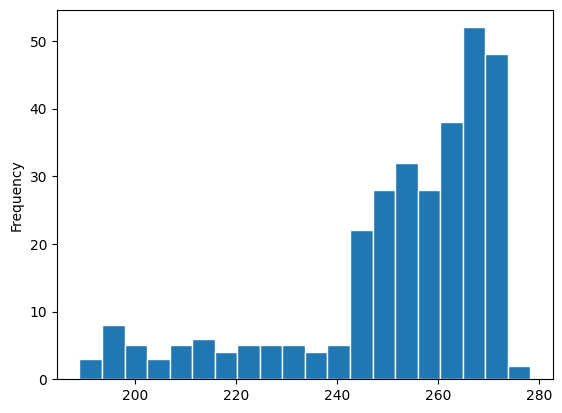

In [456]:
#proof of skewedness of data
test_dataset['CFC-11'].plot(kind='hist',bins=20,edgecolor='white')
plt.show()

Additionally, we now formally add the variable `continuous_months`, which allows us to refer to the data with minimal referencing to pandas' in-built date-time functions. 

In [457]:
# create a new variable named dataset_fixed_months which is calculated using year * 12 + month to get a continuous value
dataset_fixed_months['continuous_months'] = dataset_fixed_months['Month'] + 12 * dataset_fixed_months['Year']

### Fixing Aerosol data

#### Now that we have fixed the month column, we will now plot Aerosol level against year and month using a scatterplot to visualise the missing aerosol values

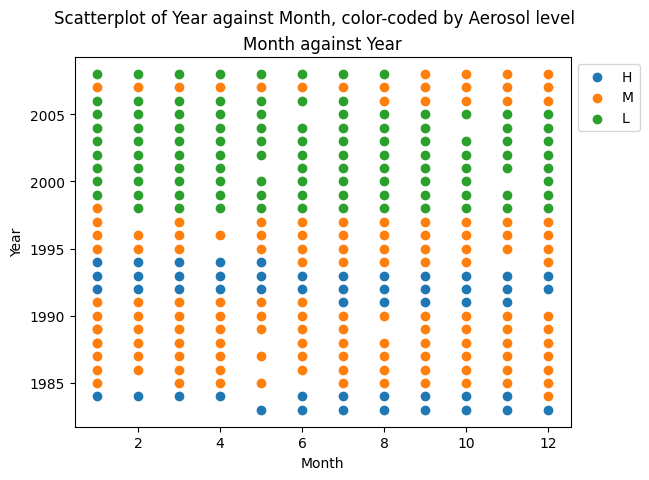

In [458]:
col1 = 'Month'
col2 = 'Year'

#  obtain an array that contains no missing values for aerosol
cats_2a = dataset['Aerosols'].dropna().unique()

dataset_for_plotting = dataset_fixed_months.copy()

for cat in cats_2a:
    filtered_dataset = dataset_for_plotting[dataset_for_plotting['Aerosols'] == cat]
    plt.scatter(filtered_dataset[col1], filtered_dataset[col2], label=cat)
    
plt.xlabel(col1)
plt.ylabel(col2)
plt.title(f"{col1} against {col2}")
plt.legend(cats_2a,bbox_to_anchor=(1, 1))
    
plt.suptitle("Scatterplot of Year against Month, color-coded by Aerosol level")

plt.show()

Gaps in the graph of year against month indicate missing aerosol values. It can be observed that since the aerosol levels for adjacent months of all the missing values are usually the same, we can impute the samples with missing data following the assumption that if the samples from adjacent months have the same aerosol value, the sample itself will also have the same aerosol value. (ie  Aerosol = 'M' for samples (1,1997) and (3,1997), hence we impute (2,1997) to also have Aerosol = 'M' where applicable).

#### The Fix:

In [459]:
# get rows with missing Aerosol values
Aerosol_missing_values = dataset_fixed_months[dataset_fixed_months['Aerosols'].isna()]

analysed_rows = ['Year','Month','Aerosols']


for current_index,row in Aerosol_missing_values.iterrows():
    #get previous index's year and month
    prior_index = current_index - 1
    prev_A_level = dataset_fixed_months.loc[prior_index, 'Aerosols']
    
    next_index = current_index + 1
    next_A_level = dataset_fixed_months.loc[next_index, 'Aerosols']
    
    #fill rows with the same adjacent Aerosol values
    if prev_A_level == next_A_level:
        dataset_fixed_months.loc[current_index,'Aerosols'] = prev_A_level

# finalize dataset by dropping unfillable Aerosol values
dataset_full_clean = dataset_fixed_months.copy()


Visualising data after imputing missing Aerosol values:

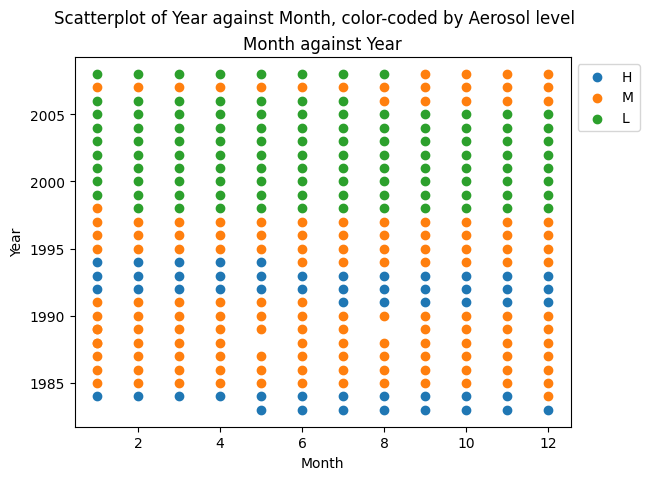

In [460]:
col1 = 'Month'
col2 = 'Year'

for cat in cats_2a:
    filtered_dataset = dataset_full_clean[dataset_full_clean['Aerosols'] == cat]
    plt.scatter(filtered_dataset[col1], filtered_dataset[col2], label=cat)
    
plt.xlabel(col1)
plt.ylabel(col2)
plt.title(f"{col1} against {col2}")
plt.legend(cats_2a,bbox_to_anchor=(1, 1))
    
plt.suptitle("Scatterplot of Year against Month, color-coded by Aerosol level")

plt.show()

Observe that most Aerosol data plots have already been filled up. Note that there are still 2 missing Aerosol plots which comes from the 2 dupicate month values that did not follow the assumption of "samples are taken at regular intervals, and no two samples are taken in the same month and year". Hence, we choose not to address this missing data plots

---

### **b.** For each variable, identify outliers (if any) and describe how you resolve the issue. Clearly state any assumption you made.

**Response.** 

#### Assumptions made:
* there are no outliers in the year and month columns, hence we would not be analyzing these 2 variables

Review all columns with numerical data

In [461]:
num_float64_columns = dataset.select_dtypes(include=['float64'])
print(f"Number of columns with dtype float64 (total: {num_float64_columns.shape[1]}):")
print('\t\n'.join(num_float64_columns))

Number of columns with dtype float64 (total: 7):
Month	
MEI	
CO2	
CH4	
CFC-11	
CFC-12	
Temp


#### Visualise presence of outliers with Boxplot

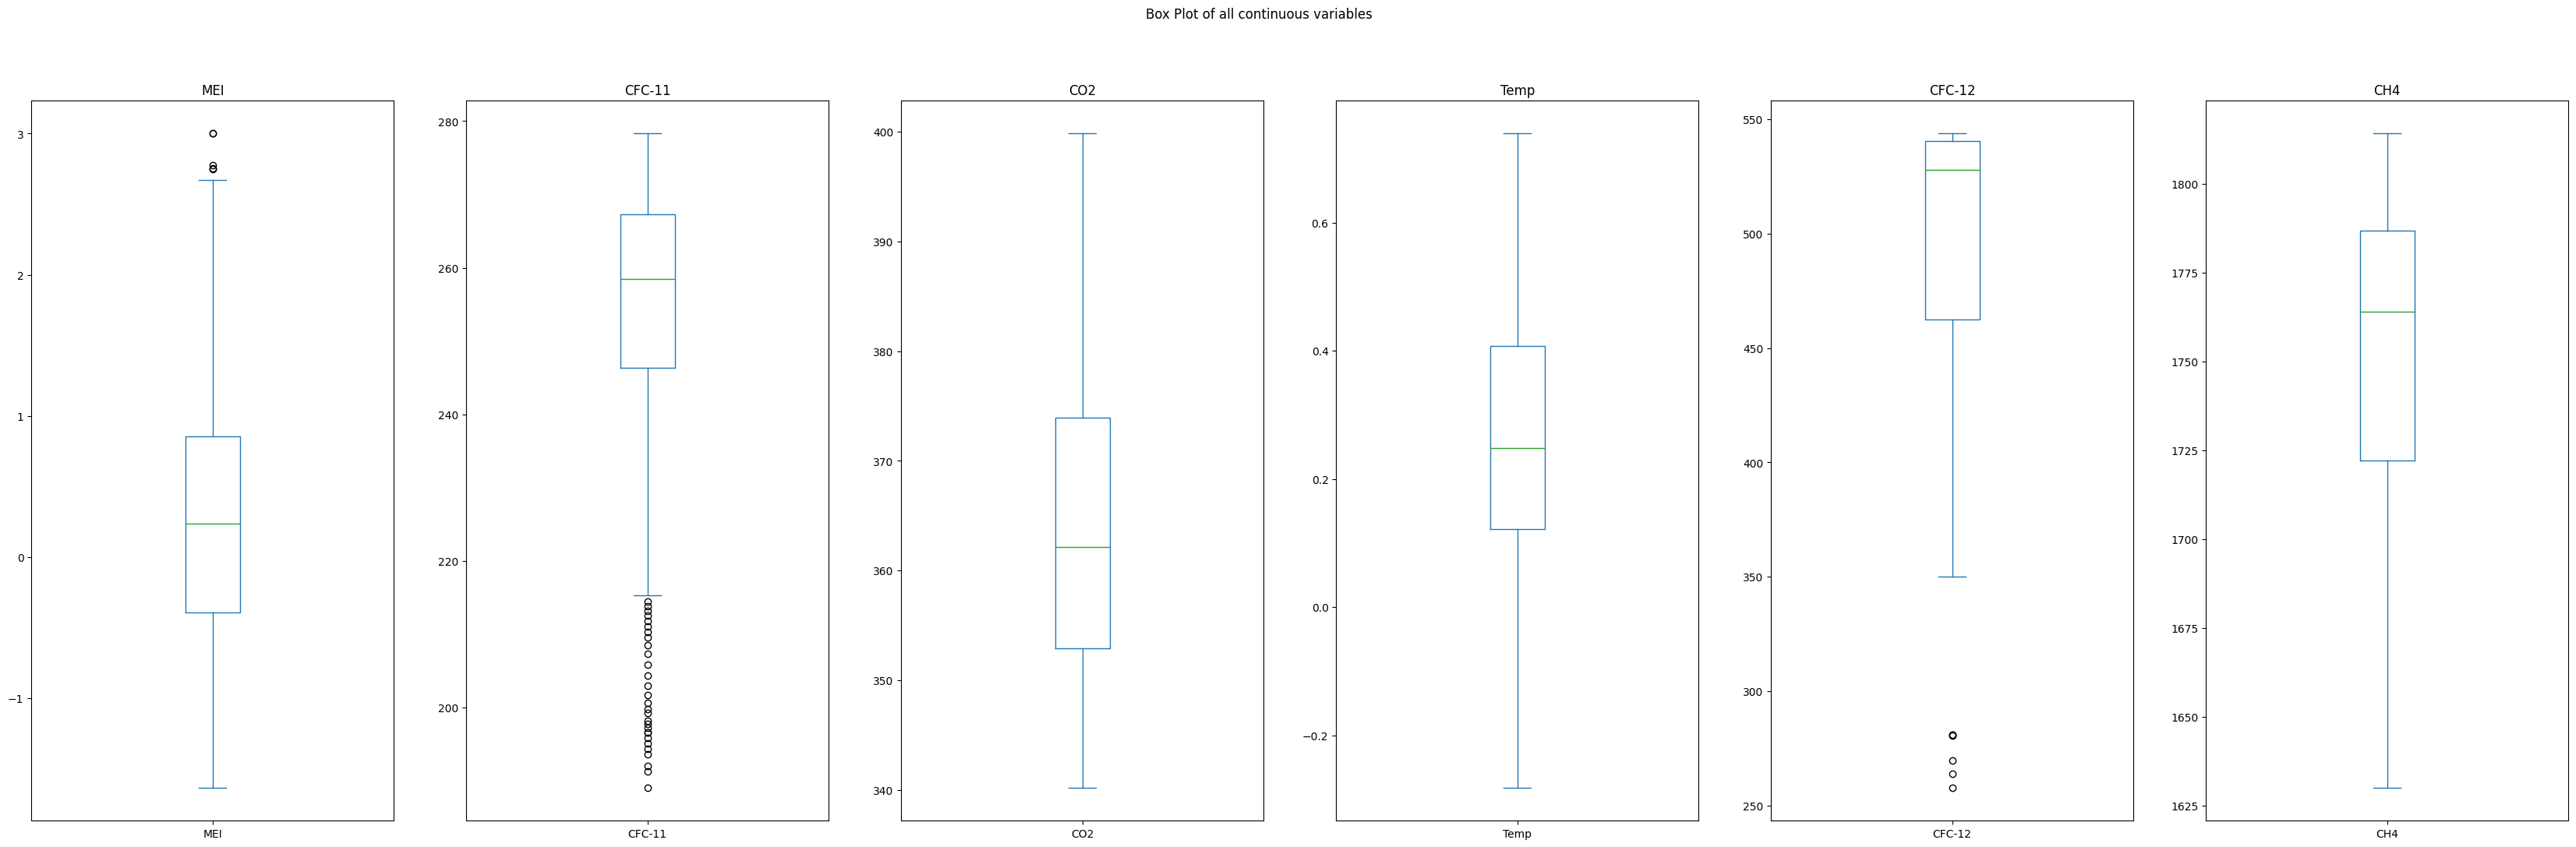

In [462]:
#dataset.dtypes
num_float64_columns = dataset.select_dtypes(include=['float64']).shape[1]
cols = list(dataset.select_dtypes(include=['float64']))
#CHANGE HERE
excluded_cols = {'Month','continuous_months'}

plottable_columns = list(set(cols) - excluded_cols)

#fig, axes = plt.subplots(num_float64_columns,1, sharex=True, sharey=True, layout="constrained")
fig, axes = plt.subplots(1,len(plottable_columns),figsize = (len(plottable_columns) * 7,12))
#plt.figure(figsize=(200, 250))
for i in range(len(plottable_columns)):
    
    column_name = plottable_columns[i]
    if column_name not in excluded_cols:
        dataset_full_clean[column_name].plot(ax=axes[i],kind='box')
        
        axes[i].set_title(column_name)
plt.suptitle("Box Plot of all continuous variables")

plt.show()

We will now obtain the number and percentages of outliers for each dataset. First, we create `get_outliers` function that assigns outlier references to dataframe under another variable

In [463]:
def get_outliers(Dataframe, column_name):
    Q1 = Dataframe[column_name].quantile(0.25)
    Q3 = Dataframe[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return Dataframe[(Dataframe[column_name] < lower_bound) | (Dataframe[column_name] > upper_bound)]

CFC_11_outliers = get_outliers(dataset_full_clean, 'CFC-11')
print("Number of outliers for column 'CFC-11':",CFC_11_outliers.shape[0])
print("proportion of data that is an outlier:",round(CFC_11_outliers.shape[0]/dataset_full_clean.shape[0]*100,2),'%')

CFC_12_outliers = get_outliers(dataset_full_clean, 'CFC-12')
print("Number of outliers for column 'CFC-12':",CFC_12_outliers.shape[0])
print("proportion of data that is an outlier:",round(CFC_12_outliers.shape[0]/dataset_full_clean.shape[0]*100,2),'%')

MEI_outliers = get_outliers(dataset_full_clean, 'MEI')
print("Number of outliers for column 'MEI':",MEI_outliers.shape[0])
print("proportion of data that is an outlier:",round(MEI_outliers.shape[0]/dataset_full_clean.shape[0]*100,2),'%')


Number of outliers for column 'CFC-11': 29
proportion of data that is an outlier: 9.42 %
Number of outliers for column 'CFC-12': 6
proportion of data that is an outlier: 1.95 %
Number of outliers for column 'MEI': 5
proportion of data that is an outlier: 1.62 %


Based on visual observation of the box plots of the samples in the dataset over each of the columns with numerical datatypes, there are outliers present in the columns `CFC-11`, `CH4` and `CFC-12`, where these samples have values that exceed 1.5 times the interquartile range. The columns with apparent outliers are elaborated on with the table below:

|Column with Outliers|Justifications|
|---|---|
| `CFC-11` | There are 29 samples that are considered outliers. This equates to 9.42% of datapoints of CFC-11. |
| `CFC-12` |  There are 6 samples that are considered as outliers. This equates to 1.95% of datapoints of CFC-12. |
| `MEI` | There are 5 samples that are considered outliers. This equates to 1.62% of datapoints of MEI.  |  

### Now that we have a clear statistics about the outlier types and values, we will proceed to analyze these outlier values and decide on our solutions for `CFC-11, CFC-12 and CH4`

#### 1. Visual analysis of `CFC-11` data to check for outliers

CFC-11 Summary statistics
count    308.000000
mean     492.804607
std       65.554230
min      257.574000
25%      462.543000
50%      527.776500
75%      540.348000
max      543.813000
Name: CFC-12, dtype: float64


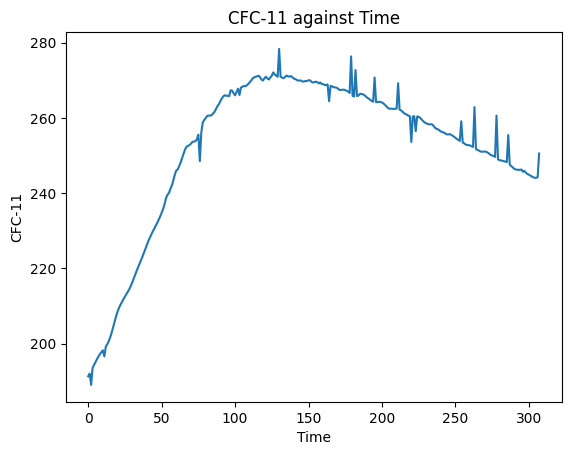

In [464]:
dataset_full_clean['CFC-11'].plot(kind='line',title='CFC-11 against Time',xlabel = 'Time',ylabel="CFC-11")

print('CFC-11 Summary statistics')
print(dataset_full_clean['CFC-12'].describe())

Since all the datapoints form a visible trend without obvious difference from the trend and any differences in values is not too different from the trend, we conclude that CFC-11 does not contain outlier data.

#### 2. Visual analysis that `CFC-12` data to check for outliers

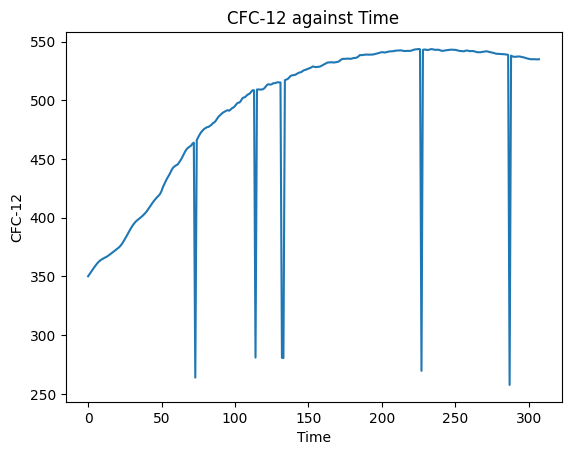

In [465]:
dataset_full_clean['CFC-12'].plot(kind='line',title='CFC-12 against Time',xlabel='Time',ylabel='CFC-12')

plt.show()

Obtaining Dataframe of outliers

In [466]:
CFC_12_outliers = dataset_full_clean[dataset_full_clean['CFC-12']<300]
print(CFC_12_outliers)

     Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
73   1989    6.0 -0.273  355.30  1713.80   L  253.793  263.793   M        M   
114  1992   11.0  0.602  354.27  1755.29   L  270.886  280.886   M        H   
132  1994    5.0  0.521  361.68  1755.04   L  270.691  280.691   M        H   
133  1994    6.0  0.734  360.80  1746.61   L  270.516  280.516   M        M   
227  2002    4.0  0.339  375.00  1782.47   L  259.574  269.574   H        L   
287  2007    4.0 -0.049  386.40  1802.11   L  247.574  257.574   L        M   

      Temp  continuous_months  
73   0.094            23874.0  
114 -0.097            23915.0  
132  0.218            23933.0  
133  0.191            23934.0  
227  0.443            24028.0  
287  0.466            24088.0  


As shown in the graph, since these 6 outliers deviate greatly from their adjacent values, they should be removed. 

#### Plotting CFC-12 aggainst time after removal of outlier


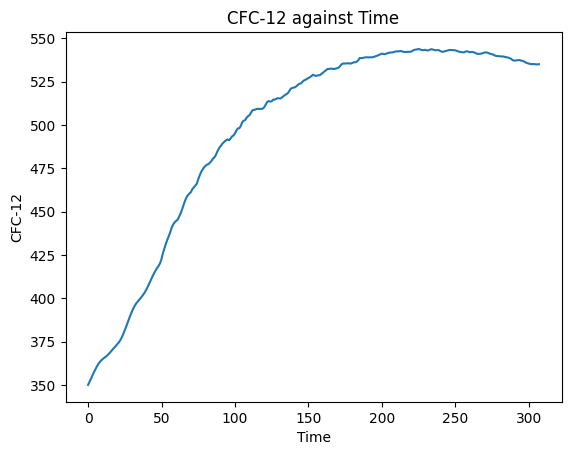

In [467]:
CFC_12_outliers_removed = dataset_full_clean[dataset_full_clean['CFC-12']>=300]
CFC_12_outliers_removed['CFC-12'].plot(kind='line',title='CFC-12 against Time',xlabel='Time',ylabel='CFC-12')

plt.show()

dataset_full_clean = CFC_12_outliers_removed.copy()

After removing the outliers, we can now conclude that there are no outliers in the datapoint of CFC-12 against time

#### 3. Visualising `CH4` data based on samples over time

CH4 Outliers:
     Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
170  1997    7.0  2.756  364.34  1751.61   L  267.784  532.827   L        M   
171  1997    8.0  3.001  362.20  1750.23   L  267.441  533.315   M        M   
172  1997    9.0  3.000  360.31  1775.56   L  267.414  534.415   L        M   
177  1998    2.0  2.777  365.98  1766.01   L  266.978  535.561   M        L   
178  1998    3.0  2.748  367.13  1774.54   L  266.593  535.421   M        L   

      Temp  continuous_months  
170  0.372            23971.0  
171  0.406            23972.0  
172  0.457            23973.0  
177  0.739            23978.0  
178  0.520            23979.0  


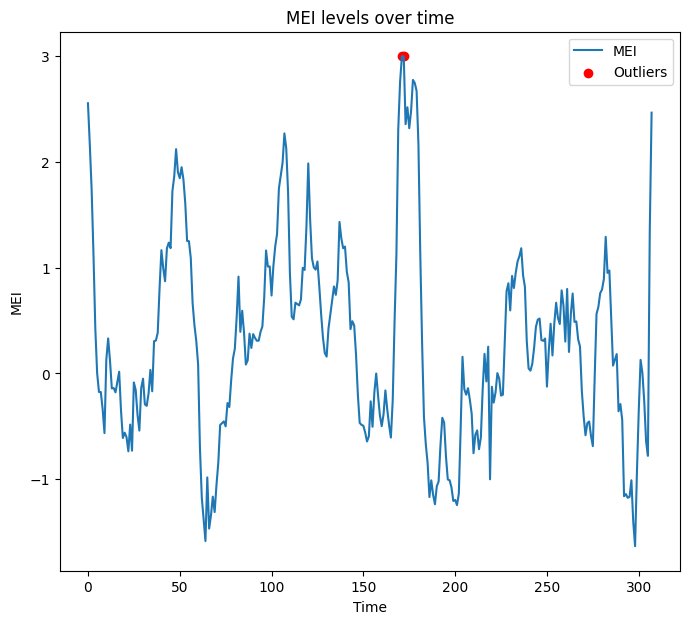

In [468]:
print("CH4 Outliers:")
print(MEI_outliers)

dataset_full_clean['MEI'].plot(kind='line',title='MEI levels over time',xlabel='Time',ylabel='MEI',figsize=(8,7))
MEI_outliers = get_outliers(dataset_full_clean, 'MEI')
plt.scatter(MEI_outliers.index, MEI_outliers['MEI'], color='red')
plt.legend(['MEI','Outliers'],loc='best')

plt.show()

No observable trend was present to indicate that outliers should be removed on the basis of deviation from time sampled, hence outlier samples flagged under `MEI` variable should be retained.

#### **c.** For categorical variables, perform the necessary encoding.

We will interpret the all 3 categorical variables to be ordinal as the values that they can take on, 'L', 'M' and 'H' can be ranked as such in ascending order of chemical or energy intensity, thus we will perform ordinal encoding for their associated columns.

In [469]:
# performing categorical encoding over non-numeric columns
# storing final dataset under variable "dataset_clean_encoded"

dataset_clean_encoded = dataset_full_clean.copy()

all_cols = dataset_full_clean.columns
num_cols = list(dataset.select_dtypes(include=['float64']))
excluded_cols = {'Month','Year','continuous_months'}

categorical_cols = list(set(all_cols)-set(num_cols)-excluded_cols)
categorical_cols.sort()
print('variables with categorical data:')
print(', '.join(categorical_cols))

encoding = {"L":0, "M":1,"H":2}
for cat in categorical_cols:
    dataset_clean_encoded[f'{cat}_ord'] = dataset_clean_encoded[cat].map(encoding)

#show processed data
print(dataset_clean_encoded.head())

variables with categorical data:
Aerosols, N2O, TSI
   Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
0  1983    5.0  2.556  345.96  1638.59   L  191.324  350.113   M        H   
1  1983    6.0  2.167  345.52  1633.71   L  192.057  351.848   M        H   
2  1983    7.0  1.741  344.15  1633.22   L  189.051  353.725   M        H   
3  1983    8.0  1.130  342.25  1631.35   L  193.602  355.633   M        H   
4  1983    9.0  0.428  340.17  1648.40   L  194.392  357.465   M        H   

    Temp  continuous_months  Aerosols_ord  N2O_ord  TSI_ord  
0  0.109            23801.0             2        0        1  
1  0.118            23802.0             2        0        1  
2  0.137            23803.0             2        0        1  
3  0.176            23804.0             2        0        1  
4  0.149            23805.0             2        0        1  


### 3.	Exploratory analysis and visualization [50% of Part I]

### **a.** For each variable, provide relevant summary statistics

**Response**: We now have a clean dataset for further analysis. We will first start with numerical datas. The numerical features we have are MEI, CO2, CH4, CFC-11, CFC-12, Temp. Below is the five-number summary statistics.

### Numerical dataset analysis (MEI, CO2, CH4, CFC-11, CFC-12, Temp)

In [470]:
dataset_clean_encoded[["MEI", "CO2", "CH4", "CFC-11", "CFC-12", "Temp"]].describe()

,MEI,CO2,CH4,CFC-11,CFC-12,Temp
count,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,0.285689,363.436887,1749.637848,251.928728,497.188030,0.257579
std,0.953268,13.070261,46.323190,20.499250,58.238429,0.178700
min,-1.635000,340.170000,1629.890000,189.051000,350.113000,-0.282000
25%,-0.404250,352.645000,1722.027500,246.272500,471.408250,0.122750
50%,0.225000,362.190000,1764.490000,258.344000,528.519000,0.249000
75%,0.869500,373.902500,1787.115000,267.137000,540.660750,0.406750
max,3.001000,399.850000,1814.180000,278.311000,543.813000,0.739000


### Categorical Dataset Analysist (TSI, Aerosol, N2O)

#### To analyse the categorical dataset, we record the number of counts of each level of every chemical and find its percentage value to understand the split in the chemical levels

In [471]:
def count_and_percentages(datasetColumn, heading=None):
    counts = datasetColumn.value_counts()
    percentages = counts / len(dataset_clean_encoded) * 100
    
    # Reset the index to make the levels a column instead of an index
    results_dataset = pd.DataFrame({
        'Chemical level': counts.index,
        'Counts': counts.values,
        'Percentages': percentages.values
    })
    
    # Reset the index and drop it to remove the 0,1,2 values
    results_dataset = results_dataset.reset_index(drop=True)
    
    if heading is not None:
        print(heading)
    print(results_dataset)
    print()


count_and_percentages(dataset_clean_encoded["N2O"], "Count and percentages of N2O levels:")
count_and_percentages(dataset_clean_encoded["TSI"], "Count and percentages of TSI levels:")
count_and_percentages(dataset_clean_encoded["Aerosols"], "Count and percentages of Aerosols levels:")

Count and percentages of N2O levels:
  Chemical level  Counts  Percentages
0              L     294    97.350993
1              H       8     2.649007

Count and percentages of TSI levels:
  Chemical level  Counts  Percentages
0              M     160    52.980132
1              L      90    29.801325
2              H      52    17.218543

Count and percentages of Aerosols levels:
  Chemical level  Counts  Percentages
0              M     141    46.688742
1              L     109    36.092715
2              H      52    17.218543



### **b.** For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

#### **Response: Visualise using Boxplots for numerical variables and Histograms for categorical variables** 

#### **Numerical Dataset Visualisation (MEI, CO2, CH4, CFC-11, CFC-12, Temp)**

We will first create a function to make univariate analysis easier. This function  plots a histogram labelled by frequency, a boxplot of the chemical and a line graph together in 1 figure.

In [472]:
# function for quick-plotting graphs
def plot_relevant_visualisations(column_name,df,modifier = '',kind='line',log=False,box = True):
    
    #log affects the number of plots, and associated variables.
    num_plots = 3 if not log else 4
    SCALE_FACTOR = 5
    fig,axes = plt.subplots(1,num_plots,figsize=((SCALE_FACTOR+1)*num_plots,SCALE_FACTOR))
    
    if not log:
        ax_hist,ax_line, ax_box= axes
    else:
        ax_hist,ax_line,ax_box,ax_log = axes
    
    freq, bins, patches = ax_hist.hist(df[column_name],bins=20,edgecolor='white')
    
    bin_centers = np.diff(bins)*0.5 + bins[:-1]

    n = 0
    for fr, x, patch in zip(freq, bin_centers, patches):
        height = int(freq[n])
        ax_hist.annotate("{}".format(height),
                    xy = (x, height),             # top left corner of the histogram bar
                    xytext = (0,0.2),             # offsetting label position above its bar
                    textcoords = "offset points", # Offset (in points) from the *xy* value
                    ha = 'center', va = 'bottom'
                    )
        n = n+1
    
    ax_hist.set_title(f"Distribution of {column_name} \n (with labelled frequencies)", fontsize=10)
    ax_hist.set_xlabel(column_name, fontsize=10)
    ax_hist.set_ylabel("Frequency", fontsize=10)
    
    if kind == 'line':
        ax_line.plot(df['continuous_months'],df[column_name],color='orange')
    else:
        ax_line.scatter(df['continuous_months'],df[column_name],color='orange')
    
    ax_line.set_title(f"{column_name} levels over time", fontsize=12)
    ax_line.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: str(int(x//12))))
    ax_line.set_xlabel('Year', fontsize=10)
    ax_line.set_ylabel(column_name, fontsize=10)
    
    df[column_name].plot(ax=ax_box,kind='box')
    ax_box.set_xlabel(column_name, fontsize=10)
    ax_box.set_ylabel('values', fontsize=10)
    ax_box.set_title(f'box plot of {column_name} ', fontsize=10)
    
    if log:
        logdf = df[column_name].copy().apply(np.log)
        new_skew = logdf.skew()
        
        lfreq, lbins, lpatches = ax_log.hist(logdf,bins=20,edgecolor='white',color='green')
        
        lbin_centers = np.diff(lbins)*0.5 + lbins[:-1]

        n = 0
        for fr, lx, patch in zip(lfreq, lbin_centers, lpatches):
            lheight = int(lfreq[n])
            ax_log.annotate("{}".format(lheight),
                        xy = (lx, lheight),             # top left corner of the histogram bar
                        xytext = (0,0.2),             # offsetting label position above its bar
                        textcoords = "offset points", # Offset (in points) from the *xy* value
                        ha = 'center', va = 'bottom'
                        )
            n = n+1
        
        ax_log.set_title(f"Distribution after log_transformation \n of {column_name} (new skew: {new_skew:.2f})", fontsize=10)
        ax_log.set_xlabel(column_name, fontsize=10)
        ax_log.set_ylabel("Frequency", fontsize=10)
    
    plt.show()

#### MEI

##### Statistical Overview:
|Mean | Standard Deviation | Min. Value | Max. Value | 1st Quartile / 25th Percentile | 2nd Quartile / 50th Percentile / Median | 3rd Quartile / 75th Percentile  |
|---|---|---|---|---|---|---|
|0.285689|0.953268|-1.635|3.001|-0.40425|0.225|0.8695|

#### Statistical Observations (MEI):
- __Central Tendency:__
    - The mean MEI value is 0.285689, meaning that for the timeframe provided by the samples obtained (1983 to 2008), the MEI value tends to be around that level. The median MEI value is 0.225000 which is smaller than the mean, indicating that the data is possibly right skewed. This is verified by the skewness of the distribution being 0.542668, hence the values have a weak rightward skew (given it has a magnitude more than 1).

- __Variability and Dispersion:__
    - The MEI value has a standard deviation of 0.953268, meaning for any given sample, we can expect its MEI value to fall within the range (-0.667579, 1.2389579). Relatively to the other variables, this deviation is small, thus these values in the samples obtained are very consistent.

- __Quartiles:__
    - The MEI values have values of -0.404250 and 0.869500 at their first and third quartiles respectively, and we can infer that 25% and 75% of the MEI values in the samples collected were below these values respectively. The median is closer to the first quartile, thu indicating that the spread of data leans towards the higher values within the IQR. 
    - The IQR itself has a size of 1.273750, and the spread of data between the first and third quartiles is moderately sized.

- __Range:__
    - The MEI values have a range 4.636000, taking on values from (-1.635000, 3.001000). This is considered small relative to the other variables given that it is 3.325983 times its standard deviation, indicating that the samples have MEI values overall are not very spread out overall.

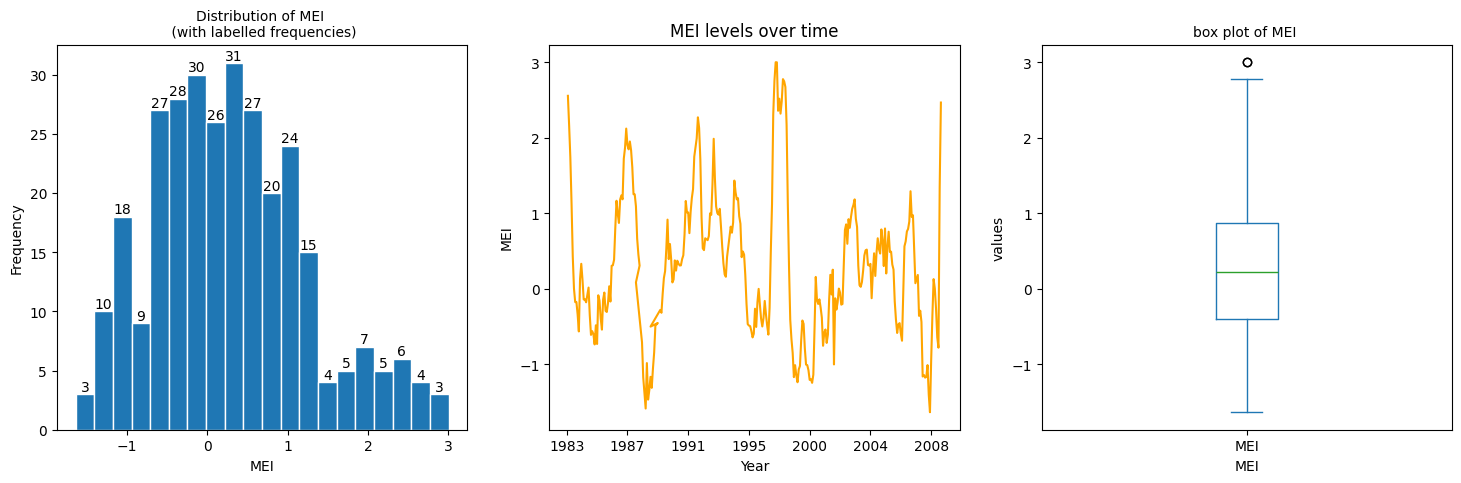

In [473]:
plot_relevant_visualisations('MEI',dataset_clean_encoded)

#### Graphical Observations and Semantic relationships (MEI):
- __Arbitrary distribution features:__
    - The modal atmospheric CFC-12 level ranges between -0.222 to 0.444, suggesting that this is the most common range of MEI values found in the data.
    
    - The distribution seems to also be a bimodal one, since we can also observe another modal peak for values in the (1.889,2.555) range. This indicates that there could be 2 distinct subgroups of MEI values and different groups of weather phenomena, and each will might have their own effect on other variables in the climate data. Thus, it warrants further bivariate analysis with other variables, both categorical and continuous.
    
    - Assuming the data follows a normal distribution, the distribution also appears to be right-skewed as a short tail can be seen on the right side of the histogram, indicating that the number of samples with specific ranges of CFC-11 levels decreases exponentially as the CFC-11 level being observed increases past the mean.
    
    - The nature of skewness also concurrs with the skewness value obtained, with a relatively low magntiude at 0.542668.


- __Trend over time and known relationships:__
    - The MEI values over time have fluctuated wildly. However, there are still noteworthy correspondences to real-world events provided by this graph:
        - The strongest 2 El-Nino effects were observed in [1982-1983](https://rmets.onlinelibrary.wiley.com/doi/10.1002/joc.2336) and 1997-1998 and correspond to the peaks observed in the respective years at ranges of 2.5 to 3.0. It is also apparent that a peak has formed near the end of the provided samples (Dec 2008), indicating that the El-Nino effect was once again in effect in that period.
        - Strong El-Nina Effects were observed in 1988 - 1989, 1999 - 2000 and 2006 - 2008.
        - The spikes for each phenomena type also agrees with the duration, lasting about 9 to 12 months as seen in real life.

    - as a general inference, we can determine based on the graph whether the earth is experiencing an El-Nino or El-Nina effect and for how long, based on whether the current MEI values for the year and past regions where the same value was observed.
    

#### CO2

##### Statistical Overview:
|Mean | Standard Deviation | Min. Value | Max. Value | 1st Quartile / 25th Percentile | 2nd Quartile / 50th Percentile / Median | 3rd Quartile / 75th Percentile  |
|---|---|---|---|---|---|---|
|363.436887|13.070261|340.17|399.85|352.645|362.19|373.9025|

#### Statistical Observations (CO2):
- __Central Tendency:__
    - The mean atmospheric carbon dioxide level is 363.436887 units , meaning that for the timeframe provided by the samples obtained (1983 to 2008), the atmospheric carbon dioxide level tends to be around that level. The median atmospheric carbon dioxide level is 362.19 units, which is smaller than the mean, indicating that the data is possibly left skewed. This is verified by the skewness of the distribution being 0.217955, hence the values have a weak leftward skew (given it has a magnitude less than 1).

- __Variability and Dispersion:__
    - The atmospheric carbon dioxide level has a standard deviation of 13.070261, meaning for any given sample, we can expect its carbon dioxide level to fall within the range (350.366627, 376.507148). Relatively to the other variables, this deviation is small (as seen by its value of variation of 0.035963 indicating that the values are extremely tight about the mean compared to the other continuous variables), thus these values in the samples obtained are very consistent.

- __Quartiles:__
    - The atmospheric carbon dioxide levels have values of 352.645000 units and 373.902500 units at their first and third quartiles respectively, and we can infer that 25% and 75% of the atmospheric carbon dioxide levels in the samples collected were below these values respectively. The median is closer to the first quartile, indicating that the spread of data leans towards the higher values within the IQR.  

    - The IQR itself has a size of 21.257500, and is approximately 1.626402 times the size of the standard deviation, meaning the spread of data between the first and third quartiles is moderately larger relative to the overall spread.  

- __Range:__
    - The atmospheric carbon dioxide levels have a range 59.680000, taking on values from (340.170000, 399.850000). This is considered a moderate size relative to the other variables given that it is 4.566091 times its standard deviation, indicating that the samples have atmospheric carbon dioxide levels that overall are spread out evenly.

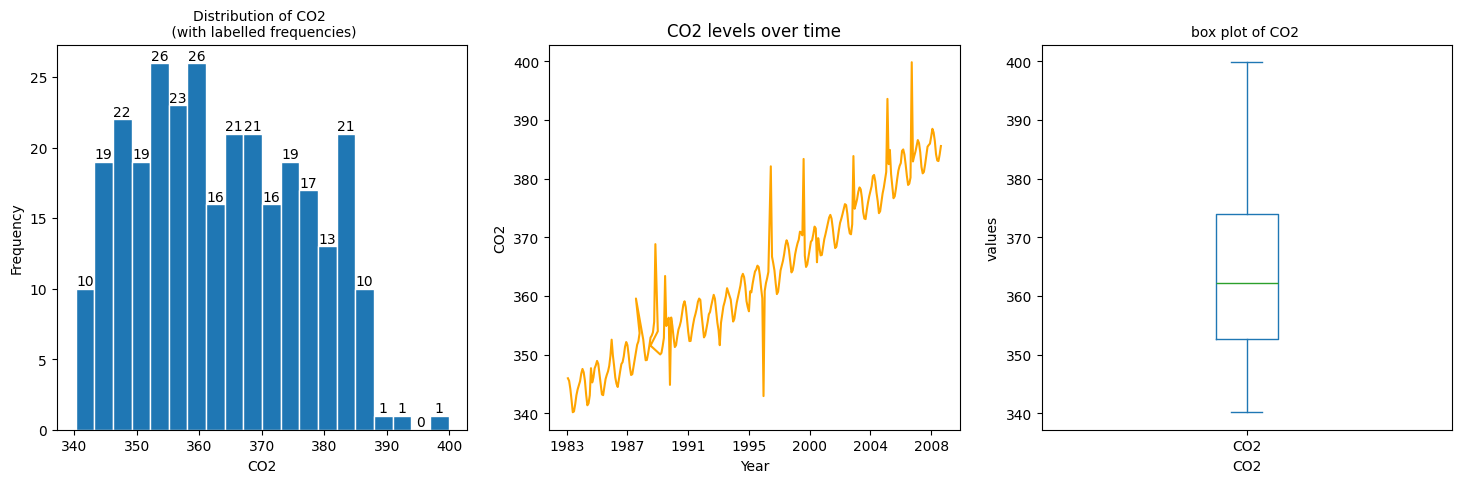

In [474]:
plot_relevant_visualisations('CO2',dataset_clean_encoded)

#### Graphical Observations and Semantic relationships (CO2):
- __Arbitrary distribution features:__
    - The modal atmospheric CO2 level ranges between 352.5 to 361.5 units, suggesting that this is the most common range of CO2 levels found in the data.
    
    - The graph distribution is rather different compared to the expectations set by the standard deviation provided, as there seem to be many modes, and the distribution does not seem to be follow a normal / gaussian one. It appears as if are 2 distributions overlaying each other, thus explaining the graph shape and the lack of a distinctive modal range of values.
    
    - Assuming the data follows a normal distribution, the distribution also appears to be right-skewed as a short tail can be seen on the right side of the histogram, indicating that the number of samples with specific ranges of CO2 levels decreases exponentially as the CO2 level being observed increases past the mean.
    
    - The nature of skewness also concurrs with the skewness value obtained, with a low magntiude at 0.217955 (seen from the distinct drop in frequency of values past 387.5 ppm.).

- __Trend over time and known relationships:__
    - There has been a consistent increase in CO2 level over time due to increasing industrial activity levels over time as human civilisation develops, and fossil fuels are being burnt for generating power and energy.
    - There are also smaller fluctuations within the year due to the various interactions that nature has with carbon dioxide, such  as the seasonal cycles of photosynthesis which will consume atmospheric CO2, and the macro-interactions with the industrial activity that natural carbon sinks have (such as the ocean).

    - However, there are also occasional spikes and dips that deviate from the typical fluctiations seen. This is typically explained with the sudden creation of more effective carbon sinks. Referencing the largest dip and peak after from 1996 - 1997, this huge fluctuation was due to [the eruption of Mount Pinatubo in 1991, which enhanced the ocean's ability to absorb carbon](https://news.agu.org/press-release/ocean-uptake-of-co2-could-drop-as-we-cut-carbon-emissions/).

#### CH4

##### Statistical Overview:
|Mean | Standard Deviation | Min. Value | Max. Value | 1st Quartile / 25th Percentile | 2nd Quartile / 50th Percentile / Median | 3rd Quartile / 75th Percentile  |
|---|---|---|---|---|---|---|
|1749.637848|46.323190|1629.890|1722.02750|1764.490|1787.11500|1814.180|

#### Statistical Observations (CH4):
- __Central Tendency:__
    - The mean atmospheric levels of methane is 1749.639 ppm, meaning that for the timeframe provided by the samples obtained (1983 to 2008), the methane levels tend to be around that level. The median methane level is 1787.115 units which is greater than the mean, indicating that the data is possibly left skewed. This is verified by the skewness of the distribution being -0.821, hence the values have a moderate lefward skew (given it has a magnitude close to 1).
- __Variability and Dispersion:__
    - The atmospheric levels of methane has a standard deviation of 46.323190 units, meaning for any given sample, we can expect its methane level to fall within the range (1795.961, 1703.315) units. Relatively to the other variables, this deviation is small, thus these values in the samples obtained are quite consistent over the years.
- __Quartiles:__
    - The methane levels have values of 1722.02750 and 1787.11500 units at their first and third quartiles respectively, and we can infer that 25% and 75% of the atmospheric methane levels of the samples collected were below these values respectively. The median is closer to the third quartile, indicating that the spread of data leans towards the lower values within the IQR. 

    - The IQR itself has a size of 65.08750 units, and the spread of data is somewhat tight within the interquartile range.

- __Range:__
    - The methane levels have a range 184.290 units, taking on values from (1629.890, 1814.180) units. This is considered small relative to the other variables given that it is 3.98 times the standard deviation, indicating that the samples have atmospheric methane levels that overall are moderately spread out.

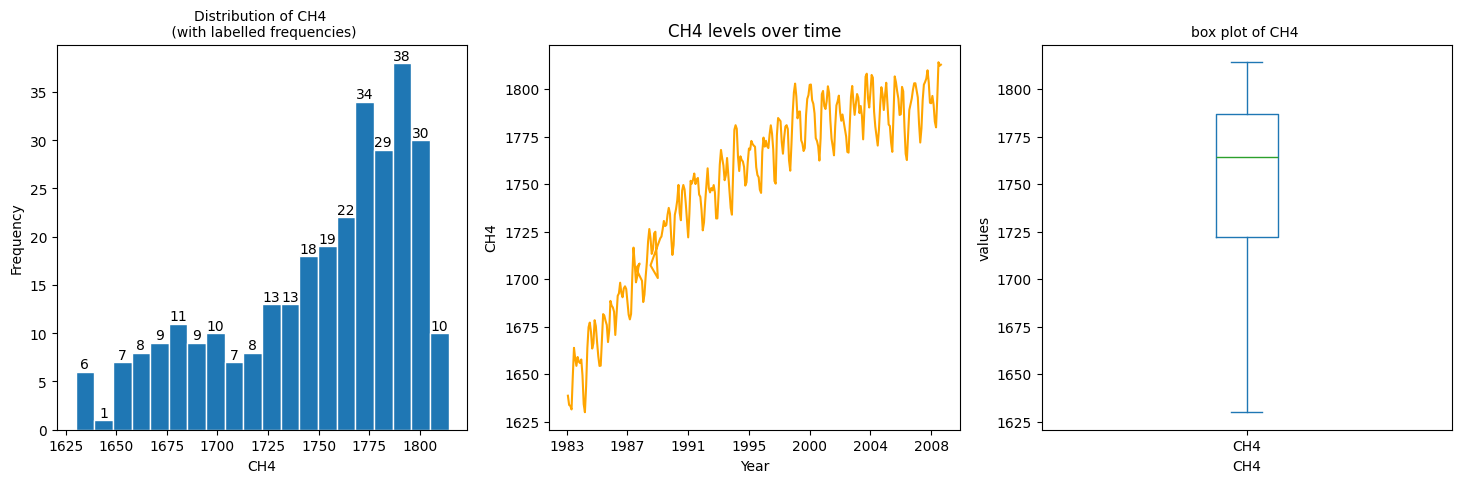

In [475]:
plot_relevant_visualisations('CH4',dataset_clean_encoded)

#### Graphical Observations and Semantic relationships (CH4):
- __Arbitrary distribution features:__
    - The modal atmospheric methane level ranges between 1775-1800 ppm, suggesting that this is the most common range of methane levels found in the data.
    - The distribution seems to also be a multimodal one, since we can also observe another modal peak at methane levels at a range slighly higher than 1675 ppm. This indicates that there could be 2 distinct subgroups of methane compositions, and each will have their own effect on other variables in the climate data. Thus, it warrants further bivariate analysis with other variables, both categorical and continuous.
    - Assuming the data follows a normal distribution, the distribution also appears to be left-skewed as a short tail can be seen on the left side of the histogram, indicating that the number of samples with specific ranges of methane levels increases rapidly as the methane level being observed increases towards the mean.
    - The nature of skewness also concurrs with the skewness value obtained, being relatively low at -0.820754.

- __Trend over time and known relationships:__
    - The methane levels abritrarily increases rapidly from 1983 to 1996, and begins to plateau until the year 2006 before a slight increase can be seen from 2006 to 2008. This concurrs with global sources such as [climate.gov](https://www.climate.gov/news-features/understanding-climate/after-2000-era-plateau-global-methane-levels-hitting-new-highs), where the pre-1999 methane level increase is due to the increase in industrial and agricultural activities, such as fossil fuel extraction, distribution and usage, as well as an agricultural expansion in livestock and crops. The plataeu from 199 to 2006 is then obesrved and hypothesized to be due to to a reduction in industrial activity due to the collapse of the soviet union in 1991, as seen from [AI analysis of historical satellite images](https://www.washington.edu/news/2024/03/12/ai-analysis-of-historical-satellite-images-show-ussr-collapse-in-1990s-increased-methane-emissions-despite-lower-oil-and-gas-production/). The increase then resumes from the same factors for pre-1999 factors for methane level increase from 2006 onwards.
    - The level of fluctuations over time also fluctuates about the the trend line seen, due to seasonal variations to leading factors like methane emmission sources (such as wetland emissions and wildfires), atmospheric sink composition (specifically relating to methane's interactions with OH-radicals and pollutants) and various other weather phenomena (such as the global cycle and the El Niño–Southern Oscillation (ENSO)). Thus, it also warrants observing if there is a correlation between methane levels and the `MEI` variable.

#### CFC-11

##### Statistical Overview:
|Mean | Standard Deviation | Min. Value | Max. Value | 1st Quartile / 25th Percentile | 2nd Quartile / 50th Percentile / Median | 3rd Quartile / 75th Percentile  |
|---|---|---|---|---|---|---|
|251.928728|20.499250|189.051|278.311|246.27250|258.344|267.13700|

#### Statistical Observations (CFC-11):
- __Central Tendency:__
    - The mean atmospheric levels of CFC-11 is 251.928 ppm, meaning that for the timeframe provided by the samples obtained (1983 to 2008), the CFC-11 levels tend to be around that level. The median CFC-11 level is 258.344 units which is greater than the mean, indicating that the data is possibly left skewed. This is verified by the skewness of the distribution being -1.445751, hence the values have a strong lefward skew (given it has a magnitude more than 1).
- __Variability and Dispersion:__
    - The atmospheric levels of CFC-11 has a standard deviation of 20.499250 units, meaning for any given sample, we can expect its CFC-11 level to have a high chance of falling within the range (231.429478, 272.427978) units. Relatively to the other variables, this deviation is small, thus these values in the samples obtained are quite consistent over the years.
- __Quartiles:__
    - The CFC-11 levels have values of 246.272500 and 267.137000 units at their first and third quartiles respectively, and we can infer that 25% and 75% of the atmospheric CFC-11 levels of the samples collected were below these values respectively. The median is closer to the third quartile, and is about 1.639250 units away from the middle of the interquartile range (IQR).

    - The IQR itself has a size of 20.864500 units, and the spread of data between the first and third quartiles is considerably tight.

- __Range:__
    - The CFC-11 levels have a range 89.260000 units, taking on values from (189.051000, 278.311000) units. This is considered small relative to the other variables given that it is 4.354306 times the standard deviation, indicating that the samples have CFC-11 levels that are not very spread out compared to the other variables.

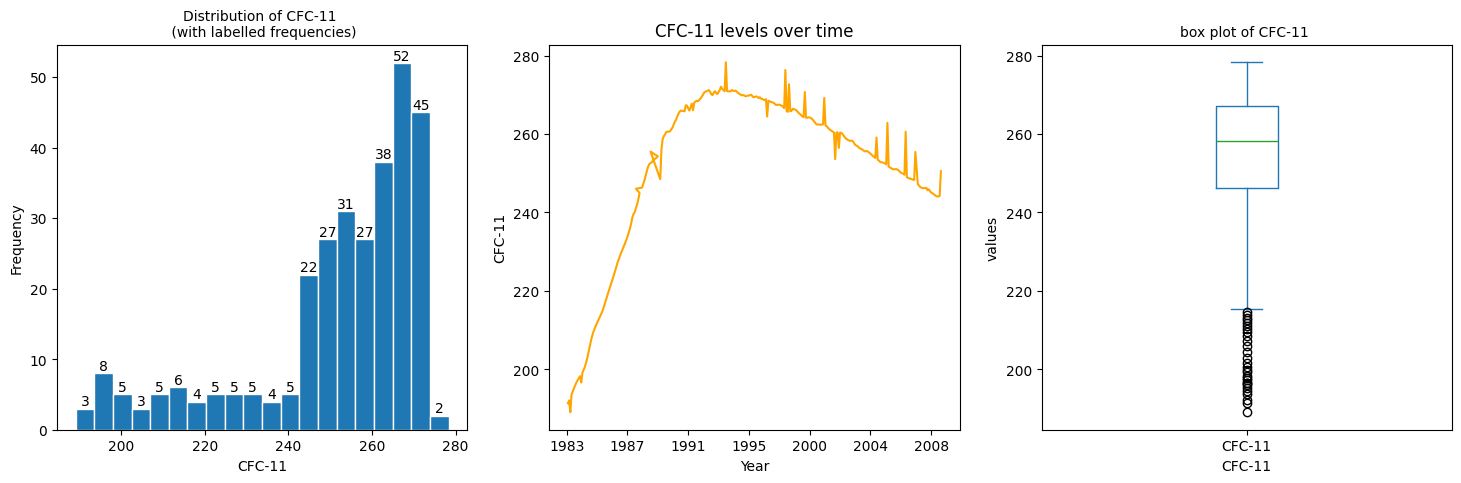

In [476]:
plot_relevant_visualisations('CFC-11',dataset_clean_encoded)

#### Graphical Observations and Semantic relationships (CFC-11):
- __Arbitrary distribution features:__
    - The modal atmospheric CFC-11 level ranges between 265-275 ppm, suggesting that this is the most common range of CFC-11 levels found in the data.
    - Assuming the data follows a normal distribution, the distribution also appears to be left-skewed as a moderately long tail can be seen on the left side of the histogram, indicating that the number of samples with specific ranges of CFC-11 levels increases very sharply as the CFC-11 level being observed increases towards the mean.
    - The nature of skewness also concurrs with the skewness value obtained, with a relatively high magntiude at -1.445751, After a log transformation of the data to handle the scale of the data, this distribution of data still exhibits a strong left-tail of -1.60.

- __Trend over time and known relationships:__
    - The CFC-11 levels arbitrarily increases rapidly from 1983 to 1991, peaks, then begins to decrease gradually with occasional moderate fluctuations to this decrease after 1991. This rapid increase is due to the widespread use of CFCs in refrigeration, foam blowing, and aerosols from [1970 to 1987](https://ozone.unep.org/system/files/documents/SAP-2021-report-on-the-unexpected-emissions-of-CFC-11-1268_en.pdf). The peak at 1993-1994 and subsequent beginning of the downward decline in CFC-11 levels starting 1996 is associated with various regulations imposed in various regions that produced large amounts of CFC emissions (such as the US's ban under the Clean Air Act in 1994) before its global ban under the Montreal Protocol and proper official cease in 1996, which took a while to show due to the existing CFC pockets from prior production that needed to be converted. However, there are some exceptions to the rule under Article 5 where if a country requires its production because it is a developing country, production will still be allowed below a certain limit.
    
    - There are also few fluctuations in its trend before 1991, while there are larger occasional spikes after that year, but the levels among the samples seem to be rather stable over time. The is general stability can be attributed to the equilibrium sustained by CFC-banks created from the initial continued production which helped to 'regulate' levels by maintaining a general atmospheric chemical equilibrium. The occasional spikes may be due to various factors, such as its unregulated production from [factories in eastern china](https://news.mit.edu/2021/cfc-11-ozone-recovery-0210), [interactions with the stratosphere-troposphere region](https://www.nature.com/articles/s41586-021-03260-5) and [possible undisclosed sources of CFC-11 that decomposed and gradually released emissions over time](https://ozone.unep.org/story-behind-unexpected-emissions-cfc-11).

    - CFCs also might have a high correlation to the TSI level since the chemical equations it undegoes requires high intensities of UV radiation to occur, thus it might have a strong correlation other variables when observed in conjunction with the `TSI` category.
    

#### CFC-12

##### Statistical Overview:
|Mean | Standard Deviation | Min. Value | Max. Value | 1st Quartile / 25th Percentile | 2nd Quartile / 50th Percentile / Median | 3rd Quartile / 75th Percentile  |
|---|---|---|---|---|---|---|
|497.18803|58.238429|350.113|543.813|471.40825|528.519|540.66075|

#### Statistical Observations (CFC-12):
- __Central Tendency:__
    - The mean atmospheric levels of CFC-12 is 497.188030 ppm, meaning that for the timeframe provided by the samples obtained (1983 to 2008), the CFC-12 levels tend to be around that level. The median CFC-12 level is 528.519000 units which is greater than the mean, indicating that the data is possibly left skewed. This is verified by the skewness of the distribution being -1.210946, hence the values have a strong lefward skew (given it has a magnitude more than 1).
- __Variability and Dispersion:__
    - The atmospheric levels of CFC-12 has a standard deviation of 58.238429 units, meaning for any given sample, we can expect its CFC-12 level to have a high chance of falling within the range (438.949601, 555.426459) units. Relatively to the other variables, this deviation is small, thus these values in the samples obtained are somewhat consistent over the years.
- __Quartiles:__
    - The CFC-12 levels have values of 471.408250 and 540.660750 units at their first and third quartiles respectively, and we can infer that 25% and 75% of the atmospheric CFC-12 levels of the samples collected were below these values respectively. The median is also closer to the third quartile.

    - The IQR itself has a size of 69.252500 units, and spread of data between the first and third quartiles is moderately sized.

- __Range:__
    - The CFC-12 levels have a range 193.700000 units, taking on values from (350.113000, 543.813000) units. This is considered small relative to the other variables given that it is 3.325983 times the standard deviation, indicating that the samples have CFC-12 levels that are not very spread out.

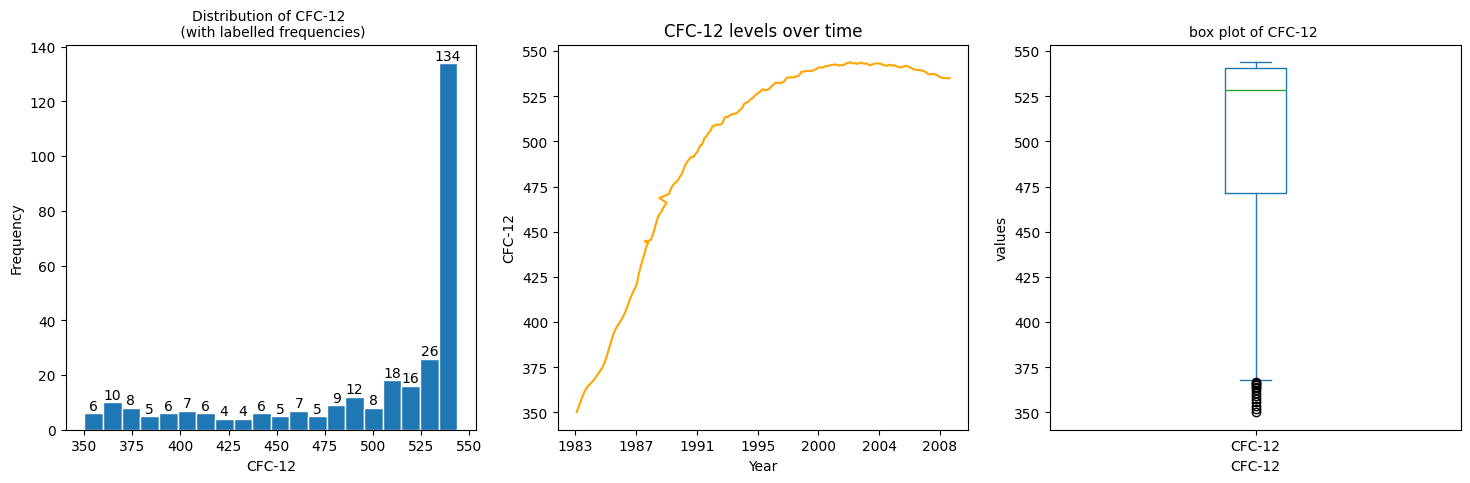

In [477]:
plot_relevant_visualisations('CFC-12',dataset_clean_encoded)

#### Graphical Observations and Semantic relationships (CFC-12):
- __Arbitrary distribution features:__
    - The modal atmospheric CFC-12 level ranges between 533.333-541.667 ppm, suggesting that this is the most common range of CFC-11 levels found in the data.
    - Assuming the data follows a normal distribution, the distribution also appears to be highly left-skewed as a long tail can be seen on the left side of the histogram, indicating that the number of samples with specific ranges of CFC-11 levels increases exponentially as the CFC-11 level being observed increases towards the mean.
    - The nature of skewness also concurrs with the skewness value obtained, with a relatively high magntiude at -1.210946.

- __Trend over time and known relationships:__
    - The CFC-12 levels arbitrarily increases rapidly from 1983 to 1993, declines to form a relatively stable peak from 1993 to 2000, then begins to decrease gradually with occasional moderate fluctuations to this decrease after 2000. This has a similar group of factors affecting the CFC-11 levels, in addition to the following points:
        - Developing countries (Categorized under Article) followed a delayed schdule to cease CFC-12 production by 2010, thus there were still signfiicant additions from the 1993 - 2000 period and a less than desirable decrease in CFC-12 levels. There are also approximately [20% more CFC-12 banks than CFC-11 banks](https://www.green-cooling-initiative.org/fileadmin/Publications/2020_ODS_CFC11_CFC12-banks.pdf) that exist and gradually contribute to the CFC-12 levels.
        - CFC-12 has an [atmospheric lifespan of 100 years](https://www.sciencedirect.com/topics/engineering/atmospheric-lifetime#:~:text=Lifetime%20of%20Greenhouse%20Chemicals&text=Nitrous%20oxide%20has%20an%20atmospheric,atmospheric%20lifetime%20of%2050%2C000%20years.), almost twice of the 55 year lifespan of CFC-11, thus its levels will generally take longer to deplete.
        - CFC-12 sources are also more difficult to regulate with issues in east asia still contributing to the current CFC-12 level to date.
    
    CFCs also might have a high correlation to the TSI level since the chemical equations it undegoes requires high intensities of UV radiation to occur, thus it might have a strong correlation other variables when observed in conjunction with the `TSI` category.
    

#### Temp

##### Statistical Overview:
|Mean | Standard Deviation | Min. Value | Max. Value | 1st Quartile / 25th Percentile | 2nd Quartile / 50th Percentile / Median | 3rd Quartile / 75th Percentile  |
|---|---|---|---|---|---|---|
|0.257579|0.1787|-0.282|0.739|0.12275|0.249|0.40675|

#### Statistical Observations (Temp):
- __Central Tendency:__
    - The mean atmospheric temperature difference from the global average is 0.257579 $^\circ C$ , meaning that for the timeframe provided by the samples obtained (1983 to 2008), the atmospheric temperature difference from the global average tends to be around that difference from the global average. The median atmospheric temperature difference from the global average is 0.249 $^\circ C$, which is smaller than the mean, indicating that the data is possibly left skewed. This is verified by the skewness of the distribution being -0.021033, hence the values have a very weak leftward skew (given it has a magnitude much less than 1).

- __Variability and Dispersion:__
    - The atmospheric temperature difference from the global average has a standard deviation of 0.178700 $^\circ C$, meaning for any given sample, we can typically expect the difference from the global average to fall within the range of (0.078880, 0.436279) $^\circ C$. Relatively to the other variables, this deviation is small (as seen by its coefficient of variation of 0.693765 indicating that the values are quite spread out about the mean compared to the other continuous variables), thus these values in the samples obtained are very consistent.

- __Quartiles:__
    - The atmospheric temperature difference from the global averages have values of 0.122750 $^\circ C$ and 0.406750 $^\circ C$ at their first and third quartiles respectively, and we can infer that 25% and 75% of the atmospheric temperature difference from the global averages in the samples collected were below these values respectively. The median is closer to the first quartile, and is about 0.015750 $^\circ C$ away from the middle of the interquartile range (IQR), indicating that the spread of data leans towards the higher values within the IQR.  
    - The IQR itself has a size of 0.284000, and the spread of data between the first and third quartiles is moderately tighter than the other variables.  
    
- __Range:__
    - The atmospheric temperature difference from the global averages have a range 1.021000, taking on values from (-0.282000, 0.739000) $^\circ C$. This is considered a moderate size relative to the other variables given that it is 5.713497 times its standard deviation, indicating that the samples have atmospheric temperature differences from the global average that are very spread out overall.


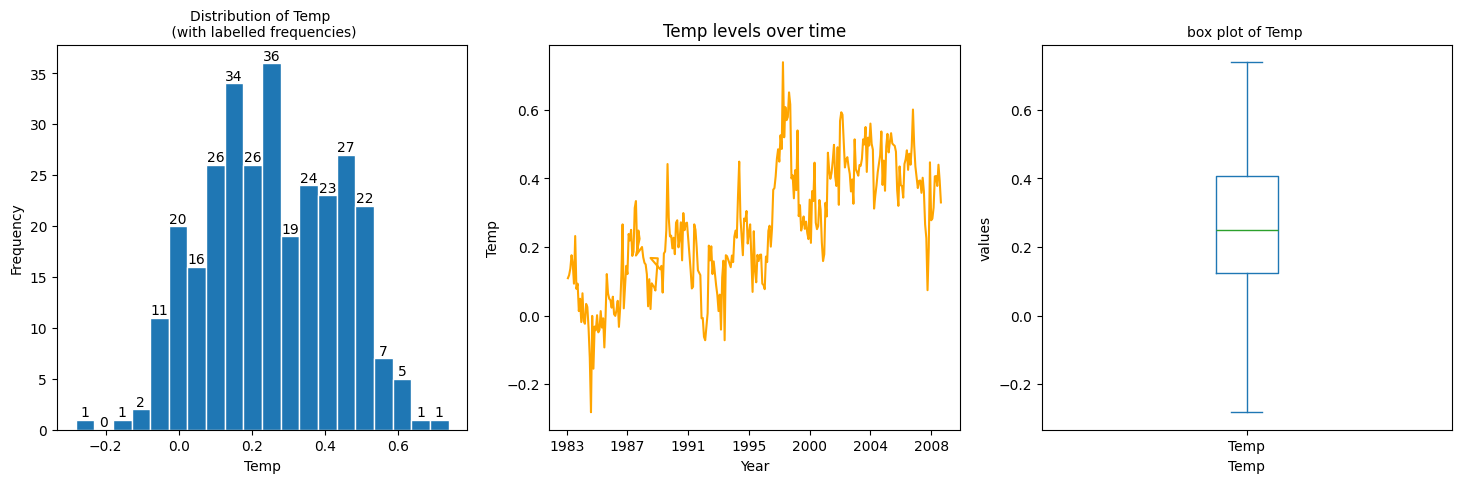

In [478]:
plot_relevant_visualisations('Temp',dataset_clean_encoded)

#### Graphical Observations and Semantic relationships (Temp):
- __Arbitrary distribution features:__
    - The modal atmospheric temperature difference from the global average ranges between 0.129 to 0.271 $^\circ C$, suggesting that this is the most common range of values for temperature differences found in the data.
    
    - While the graph can be asserted to be a symmetric normal distribution, there are two modes observed to indicate that this might be a bimodal normal distribution with modes at the 0.45 - 0.525 $^\circ C$ range.
    
    - Assuming the data follows a normal distribution, the distribution also appears to be almost symmetric, but having a slight left skew as seen by the slightly longer left tail, indicating that the number of samples with specific ranges of CO2 levels increases exponentially as the Temperature differences being observed increases prior to the mean, but plateaus at a certain turning point.
    
    - The nature of skewness also concurrs with the skewness value obtained, with a low magntiude at -0.021033.

- __Trend over time and known relationships:__
    - Temperature fluctuations have been seen to be rather volatile with a general increase in temperature. This can be attributed to most of the aforementioned factors working in tandem, alongside more factors that might not be recorded in our data. Hence, this would be a suitable dependent variable for a regression task.

We will use another function specifically for categorical data, `plot_categorical`:

In [479]:
# function for quick-plotting graphs
def plot_categorical(column_name,df,modifier = '',kind='line',log=False,box = True):
    
    #log affects the number of plots, and associated variables.
    num_plots = 2 if not log else 3
    SCALE_FACTOR = 5
    fig,axes = plt.subplots(1,num_plots,figsize=((SCALE_FACTOR+1)*num_plots,SCALE_FACTOR))
    
    if not log:
        ax_hist,ax_line= axes
    else:
        ax_hist,ax_line,ax_log = axes
    

    df.groupby(column_name)[column_name].value_counts().plot.bar(ax=ax_hist)
    
    ax_hist.set_title(f"Distribution of {column_name} \n (with labelled frequencies)", fontsize=10)
    ax_hist.set_xlabel(column_name, fontsize=10)
    ax_hist.set_ylabel("Frequency", fontsize=10)
    
    if kind == 'line':
        ax_line.plot(df['continuous_months'],df[column_name+'_ord'],color='orange')
    else:
        ax_line.scatter(df['continuous_months'],df[column_name+'_ord'],color='orange')
    
    ax_line.set_title(f"{column_name} levels over time", fontsize=12)
    ax_line.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: str(int(x//12))))
    ax_line.set_xlabel('Year', fontsize=10)
    ax_line.set_ylabel(column_name, fontsize=10)
    
    
    if log:
        logdf = df[column_name].copy().apply(np.log)
        new_skew = logdf.skew()
        
        lfreq, lbins, lpatches = ax_log.hist(logdf,bins=20,edgecolor='white',color='green')
        
        lbin_centers = np.diff(lbins)*0.5 + lbins[:-1]

        n = 0
        for fr, lx, patch in zip(lfreq, lbin_centers, lpatches):
            lheight = int(lfreq[n])
            ax_log.annotate("{}".format(lheight),
                        xy = (lx, lheight),             # top left corner of the histogram bar
                        xytext = (0,0.2),             # offsetting label position above its bar
                        textcoords = "offset points", # Offset (in points) from the *xy* value
                        ha = 'center', va = 'bottom'
                        )
            n = n+1
        
        ax_log.set_title(f"Distribution after log_transformation \n of {column_name} (new skew: {new_skew:.2f})", fontsize=10)
        ax_log.set_xlabel(column_name, fontsize=10)
        ax_log.set_ylabel("Frequency", fontsize=10)
    
    plt.show()

### **Categorical Dataset Visualisation (TSI, Aerosol, N2O)**

#### **N2O**

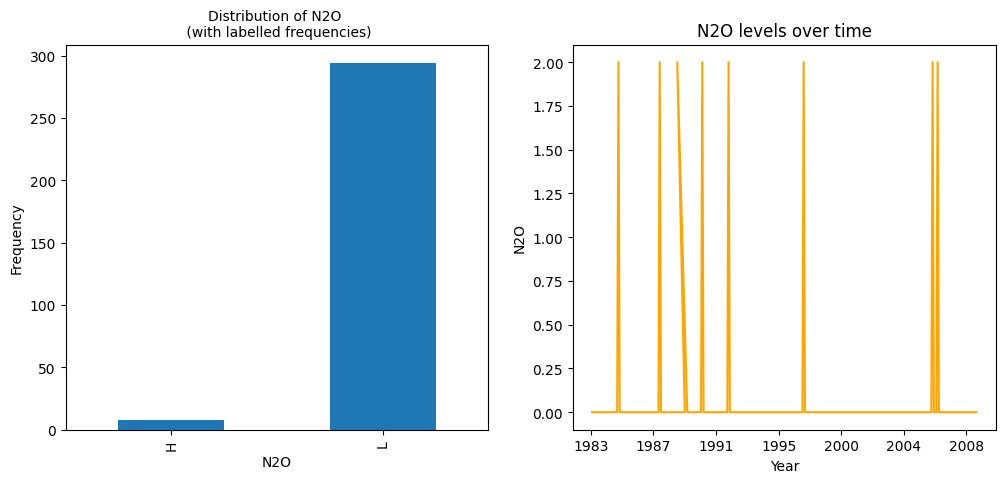

In [480]:
plot_categorical('N2O',dataset_clean_encoded)

### **Observations**:

The histogram shows the distribution of N2O categorized by its level: Low (L), and High (H).

##### Low N2O Levels:
The vast majority of N2O measurements fall into the 'Low' category (294 out of 302, or 97.35%). This extremely skewed distribution indicating that N2O levels are predominantly low in the dataset. The high proportion of low N2O levels might suggest that this is the normal or baseline state in the atmosphere, and higher levels are typically indicators of potential anomalies or phenomena.

##### High N2O Levels:
Only a small fraction of samples (8 samples, or 2.65%) show high levels of N2O. This suggests that high N2O concentrations are rare occurrences in the measured environment. They probably represent specific events or conditions that temporarily increased N2O levels, such as volcanic reuptions.


#### **TSI**

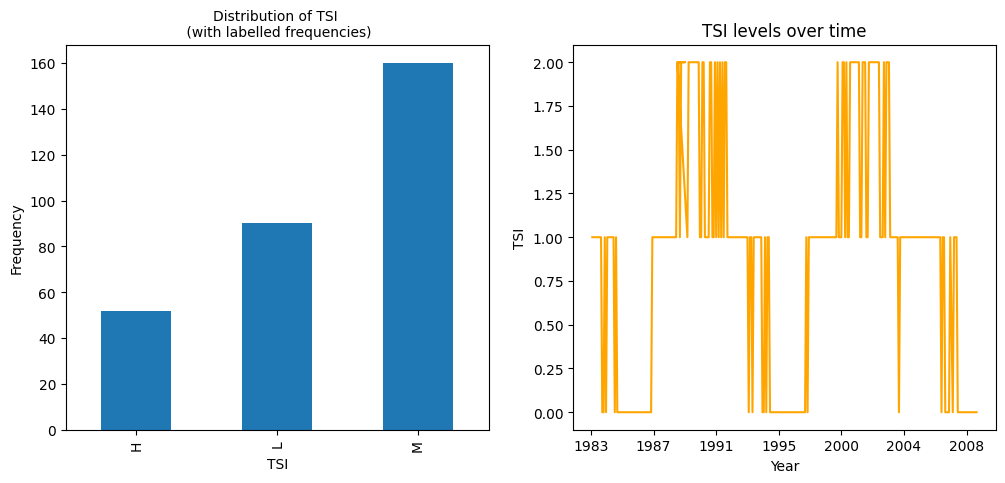

In [481]:
plot_categorical('TSI',dataset_clean_encoded)

### **Observations**:

The histogram shows the distribution of TSI (Total Solar Irradiance) categorized by its levels: Low (L), Medium (M), and High (H).

##### Medium TSI Levels:
The largest proportion of TSI measurements falls into the 'Medium' category (160 out of 302, or 52.98%). This indicates that medium TSI levels are the most common in the dataset. The predominance of medium values suggests that TSI typically operates within a moderate range, which might represent normal or expected conditions for solar irradiance in the environment being studied.

##### Low TSI Levels:
The second most common category is 'Low' TSI levels (90 out of 302, or 29.80%). There is a significant number of measurements showing lower than medium solar irradiance, which could correspond to periods of reduced solar activity, seasonal variations, or other factors that diminish solar radiation reaching the measurement point. They also exists short fluctuations in time periods such as from 1993 to 1994, indicating that there may be phenomena worthy of exploring.

##### High TSI Levels:
The 'High' TSI category contains the smallest proportion of measurements (52 out of 302, or 17.22%). This indicates that there are fewer instances of high solar irradiance in this dataset. These high readings might represent peak solar activity periods, seasonal maxima, or specific conditions that enhance solar radiation.  
  
There are also relatively longer periods of fluctuating levels of TSI from high to medium, also indicating tat there may be phenomena worth exploring in those time periods.

Overall, the histogram reveals a distribution that peaks at medium levels and tapers off toward both low and high extremes, with a greater tendency toward low rather than high values. This pattern might reflect the natural variability of solar irradiance or could be related to the specific thresholds used to define the low, medium, and high categories. The sustained fluctuating periods also warrant further exploration.

#### **Aerosol**

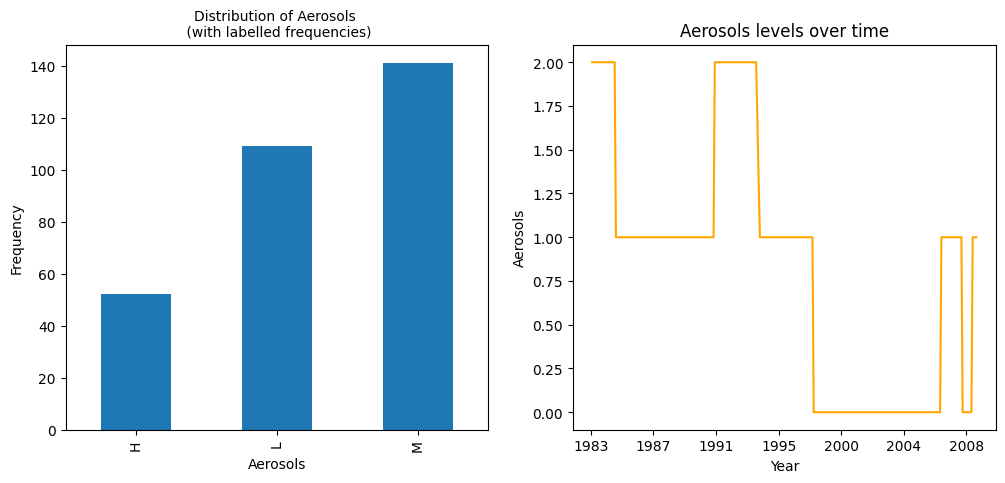

In [482]:
plot_categorical('Aerosols',dataset_clean_encoded)

### **Observations**:

The histogram shows the distribution of Aerosols categorized by their levels: Low (L), Medium (M), and High (H).

##### Medium Aerosol Levels:
The largest proportion of Aerosol measurements falls into the 'Medium' category (141 out of 302, or 46.69%). This indicates that medium aerosol levels are the most common in the dataset. The predominance of medium values suggests that aerosol concentrations typically operate within a moderate range in the environment being studied, possibly representing normal background conditions.

##### Low Aerosol Levels:
The second most common category is 'Low' aerosol levels (109 out of 302, or 36.09%). There is a significant number of measurements showing lower aerosol concentrations, which could correspond to periods of cleaner air, perhaps after precipitation events that wash aerosols from the atmosphere, or during conditions that limit aerosol production or transport. There has also been a sustained period from 1997 to 2006 of low aerosols, that could warrant furhter analysis.

##### High Aerosol Levels:
The 'High' aerosol category contains the smallest proportion of measurements (52 out of 302, or 17.22%). This indicates that there are fewer instances of high aerosol concentrations in this dataset. These high readings might represent pollution events, dust storms, volcanic activity, or other specific conditions that temporarily increase aerosol loading in the atmosphere. There has also been a sustained period from 1991 to 1993 of high aerosol levels, that could warrant furhter analysis.

Overall, the histogram reveals a distribution that is weighted toward medium levels, with substantial representation in the low category and fewer instances in the high category. This pattern might reflect the natural variability of aerosols in the environment or could be related to the specific thresholds used to define the low, medium, and high categories. The prolonged periods also could be analysed as potential hypotheses for a classification problem.

### **c.** Perform bi-variate analysis on the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables. Use appropriate statistical methods and/or visualizations.

**Response.** 

Bi-variate analysis focussing on categorical variables

In [483]:
pd.crosstab(dataset_clean_encoded.TSI, dataset_clean_encoded.Aerosols)

Aerosols,H,L,M
TSI,,,
H,6,27,19
L,6,9,75
M,40,73,47


Plotting heatmap for assessing correlation values for continuous data:

In [484]:
month_save = dataset.copy()
dataset_fixed_months = month_save.copy()
dataset_fixed_months['continuous_months'] = dataset_fixed_months['Month'] + 12 * dataset_fixed_months['Year']
dataset_for_plotting = dataset_fixed_months.copy()
cols = list(dataset_for_plotting.select_dtypes(include=['float64','int64']))
categorical_cols = ['Aerosols_ord','N2O_ord','TSI_ord']

continuous_variables = list(set(cols) - set(categorical_cols))

print('Columns with continuous data:')
print(', '.join(continuous_variables))

Columns with continuous data:
MEI, CFC-11, CO2, Temp, CFC-12, CH4, Month, continuous_months, Year


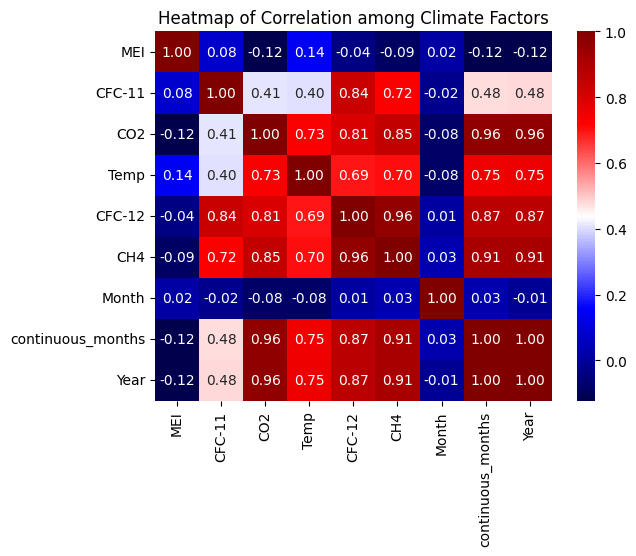

In [485]:
import seaborn as sns
datatset_correlations = dataset_clean_encoded[continuous_variables].corr()

sns.heatmap(datatset_correlations, annot=True, fmt='.2f', cmap='seismic')
plt.title('Heatmap of Correlation among Climate Factors')
plt.show()

### Observations:

Based on the above heatmap, we noticed that majority of the correlation values have absolute values of less than 0.8. Hence, we determined that it is sufficient enough to set the threshold level for meaningful relationships to be 0.8. We chose a rather conservative value of 0.8 as it indicates a moderate level of correlation between variables. As this value is close to 1, it suggests a strong association between the variables. 

Based on our considerations, we decided to proceed with the bi-vaiate analysis of 1) CO2 and CFC-12, 2) CO2 & CH4, 3) CO2 & continuous_months, 4) CFC-12 & continuous_months, 5)  CH4 & continuous_months, 6) CFC-12 & CFC-11, 7)  CFC-12 and CH4

The correlation values for all pairs ( 1, 2, 3, 4, 5, 6 and 7 ) are positive, so there is likely to be positive relationships.

### Moving forward, a Scatter plot would be used to analyse the relationship between these 7 pairs


First, we would create a function that can be used to plot scatterplot diagrams between 2 variables, **`plot_with_coefficient`**:

In [486]:
def plot_with_coefficient(column1:str, column2:str, dataset_clean_encoded:pd.DataFrame, modifier = '',folder_mod = 'ungrouped/'):
    '''
    column1 is the x axis
    column2 is the y axis
    modifier to make a note of anything different
    '''
    
    cols = list(dataset_clean_encoded.select_dtypes(include=['float64']))
    #CHANGE HERE
    excluded_cols = {'Month'}
    plottable_columns = list(set(cols) - excluded_cols)

    datatset_correlations_local = dataset_clean_encoded[plottable_columns].corr()
    # 
    corr_num = round(datatset_correlations_local[column1][column2], 3)
    plt.figure()  # Create a new figure
    ax = plt.axes()
    ax.scatter(dataset_clean_encoded[column1], dataset_clean_encoded[column2])
    # Make sure we're using function calls
    ax.set_xlabel(column1)
    ax.set_ylabel(column2)
    
    ax.set_title(f"{column2} against {column1} (correlation coefficient {corr_num})")
    plt.show()

### Pair 1: CO2 and CFC-12

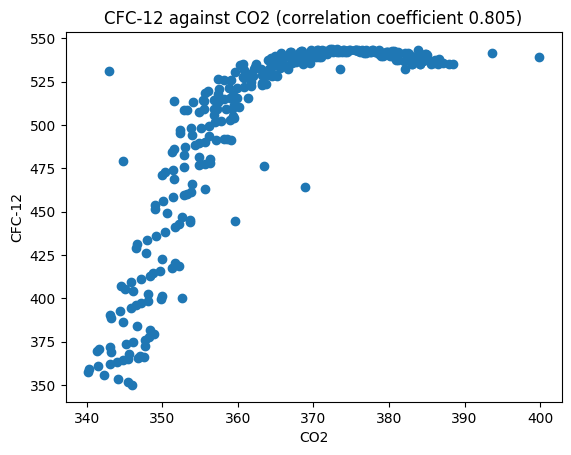

In [487]:
plot_with_coefficient('CO2','CFC-12',dataset_clean_encoded)

There is a clear positive correlation between CO2 and CFC-12 concentrations.

As CO2 levels increase from around 340 to 400 ppm, CFC-12 levels rise from approximately 350 to 540 ppb.

The relationship appears to be non-linear in general. The graph appears to be lnear until around CO2 level of 360ppm and CFC-12 level of around 525ppb. The graph then starts to slope down after that point, with the slope becoming less steep at higher CO2 concentrations.

The graph forms a general upward trajectory, indicating that both greenhouse gases tend to increase together.



### Pair 2: CO2 & CH4

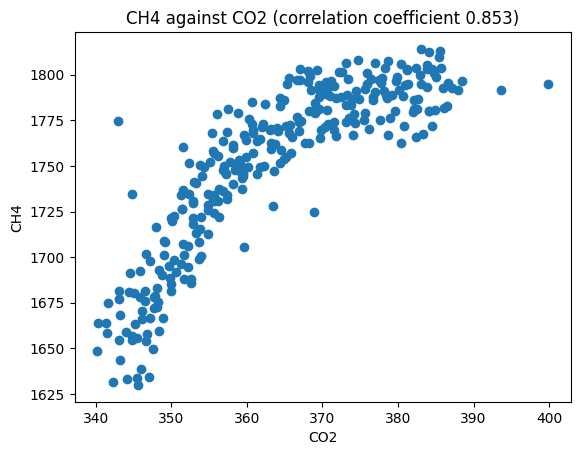

In [488]:
plot_with_coefficient('CO2','CH4',dataset_clean_encoded)

There is a clear positive correlation between CO2 and CH4 concentrations with a strong correlation coefficient of 0.853.

As CO2 levels increase from around 340 to 400 ppm, CH4 levels increase to approximately 1625 to 1800 ppm.

The relationship appears to be slightly non-linear in general. The graph appears to be lnear until around CO2 level of 360ppm and CH4 level of around 1750ppm. The graph then starts to slope down slightly after that point, with the slope becoming less steep at higher CO2 concentrations. There is also an increased scatter at higher CO2 concentrations.

The data points form a generally upward trajectory, indicating that both greenhouse gases have been increasing together.

### Pair 3: CO2 & continuous_months

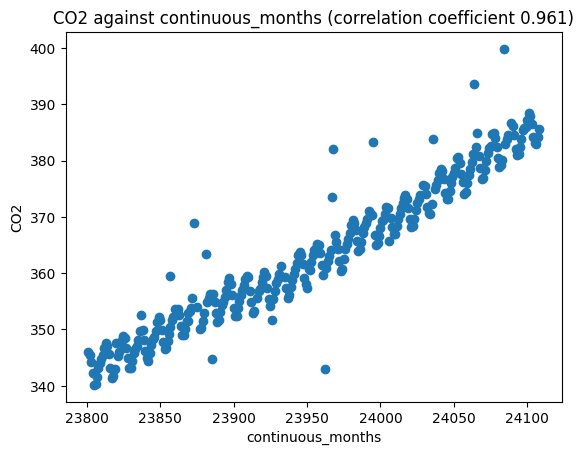

In [489]:
plot_with_coefficient('continuous_months','CO2',dataset_clean_encoded)

There is a clear positive correlation between CO2 and continuous months with a very strong correlation coefficient of 0.961.

As time progresses (continuous months from approximately 23800 to 24100), CO2 levels increase steadily from around 340 to 400 ppm.

The relationship appears to be generally linear, showing a consistent positive trend over time with a very clear linear pattern, indicating a steady increase in atmospheric CO2 concentration over the measured time period.  

There is also cyclical patterns akins to wave-like formations, likely representing seasonal variations in CO2 levels.

### Pair 4: CFC-12 & continuous_months

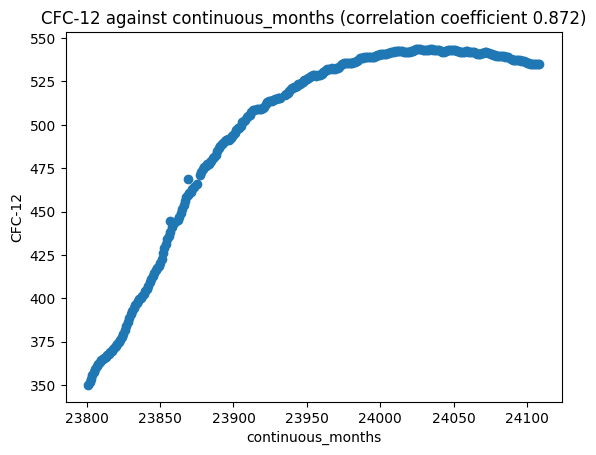

In [490]:
plot_with_coefficient('continuous_months','CFC-12',dataset_clean_encoded)

There is a strong positive correlation between CFC-12 and continuous months with a correlation coefficient of 0.872.

As time progresses (continuous months from approximately 23800 to 24100), CFC-12 levels initially rise rapidly from around 350 to 540 parts per billion.

The relationship is distinctly non-linear. There are 3 visible phases displayed: relatively consistent initial increase, plateau, and slight decrease.

The data points form a very tight curve with very small scatter, indicating a consistent pattern.

The graph shows a clear leveling off after around continuous_months of 23900 and even a slight dip in CFC-12 levels after around month 24000.

### Pair 5: CH4 & continuous_months

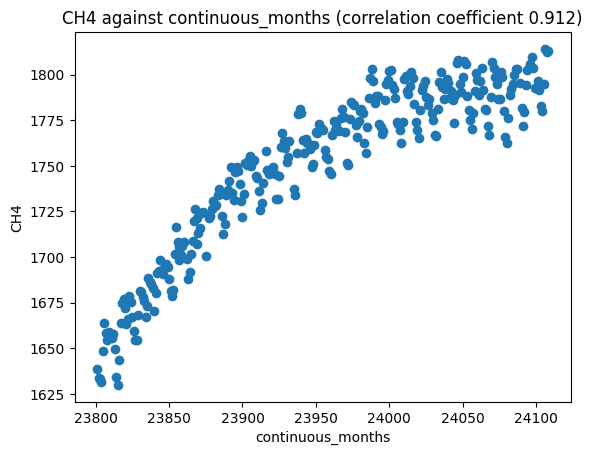

In [491]:
plot_with_coefficient('continuous_months','CH4',dataset_clean_encoded)

There is a strong positive correlation between CH4 and continuous months with a correlation coefficient of 0.912

As time progresses (continuous months from approximately 23800 to 24100), CH4 levels rise from around 1625 to 1800 parts per million.

The relationship appears non-linear. There is a steeper increase initially and then a more gradual increase with increase in the variation of the values(more scatter).

The data points form a clear pattern with slightly more scatter especially in the later months.

As for rate of increase in values, there is a continued increase in CH4 levels throughout the time period, with the rate of increase slowing down after around month 24000 (Year 2000).

### Pair 6: CFC-12 & CFC-11

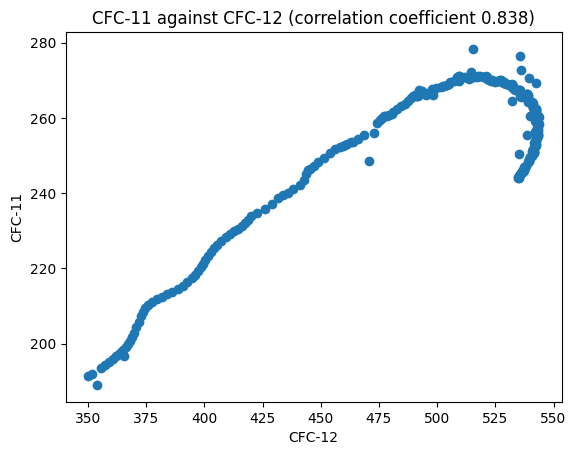

In [492]:
plot_with_coefficient('CFC-12','CFC-11',dataset_clean_encoded)

There is a strong positive correlation between CFC-11 and CFC-12 with a correlation coefficient of 0.838.

As CFC-12 levels increase from approximately 350 to 525 parts per billion, CFC-11 concentrations rise from about 190 to 270 parts per billion.

The relationship displays a non-linear pattern with several different phases of growth.

In terms of consistency of data, the data points form a very tight curve with very small scatter, indicating a consistent relationship between these two chlorofluorocarbons.

There is a loop formed at higher concentration levels where CFC-12 > 525ppb.

The relationship suggests these two ozone-depleting substances have followed similar but not identical atmospheric concentration patterns. The most plausible explanation for this graph is their different atmospheric lifetimes (52 years for CFC-11 versus 102-114 years for CFC-12), which causes them to decompose at different rates.This explains the shape both chemicals' concentrations first rose together but then followed different trajectories, with CFC-11 decreasing at extremely high levels of CFC-12.

### Pair 7: CFC-12 and CH4

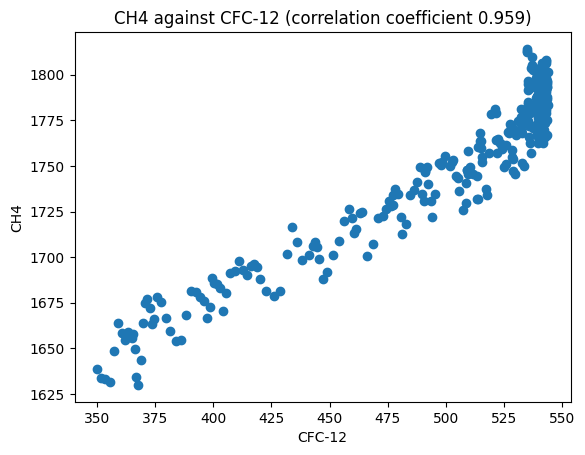

In [493]:
plot_with_coefficient('CFC-12','CH4',dataset_clean_encoded)

There is a very strong positive correlation between CH4 and CFC-12 with a correlation coefficient of 0.959

As CFC-12 levels increase from approximately 350 to 545 parts per trillion, CH4 concentrations rise from about 1625 to 1820 parts per billion

The relationship shows a non-linear pattern with increasing gradient at higher concentration values of CFC-12

The data points appear more scattered initially, with the scattering dropping sharply especially at CFC-12 > 525ppb.

There appears to be a vertical clustering of data points around CFC-12 values of 525-545ppm, suggesting that CFC-12 levels have stabilised at around 550ppb even as CH4 levels continue to increase.

In [494]:
dataset_clean_encoded.to_csv('./dataset_clean_encoded_p2.csv',index=False)

## Part II: Modeling [12% of final grade]

### 1. Problem formulation [15% of Part II]

**a.** Formulate one regression problem and one classification based on the dataset, in **no more than 50 words**.

**Response.** 

<span style="color:LightSkyBlue">

##### **Regression Problem:**
Predict the temperature differences with the available atmospheric and seasonal data using `Temp_diff_cs`, derived from the cumulative sum of the moving average of the feature `Temp`.
##### **Classification Problem:**
Classify the atmospheric aerosol level ("High", "Medium" or "Low") given the available atmospheric data.

</span>

----

**b.** State which problem (regression or classification) you would be investigating and why, in **no more than 20 words**.

**Response.** 

<span style="color:LightSkyBlue">
The regression problem is more significant since atmospheric temperature is vital in many biochemical interactions in various ecosystems.
</span>

**c.** Clearly specify the dependent variable you are predicting, and its significance, in **no more than 20 words**.

**Response.** 

<span style="color:LightSkyBlue">  

`Temp_diff_cs`, because temperature fluctuations are vital for predicting extreme weather phenomena, agricultural planning, power grid operations and related scientific research.
</span>

### 2. Model training [30% of Part II]

**a.** Perform feature selection. For each variable, decide if you want to include it as a feature and provide a justification. You may leverage on your analysis in Part I: EDA and/or perform additional analysis.

**Response.** 

<span style="color:LightSkyBlue">

## **Feature Selection for categorical variables**

<span style="color:LightSkyBlue">

First, we will import the data and verify the number of rows and columns we will be using for part 2 of the project:

In [47]:
#install sklearn on the spot
!pip install scikit-learn

In [48]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

DATA_FILEPATH_P2 = './dataset_clean_encoded_p2.csv'

data = pd.read_csv(DATA_FILEPATH_P2)
print("Shape of data after loading from csv, should have had 6 outlier rows removed from part 1:")
print(data.shape)

Shape of data after loading from csv, should have had 6 outlier rows removed from part 1:
(302, 15)


<span style="color:LightSkyBlue">

Next, we will create a table of the frequencies for each categorical value against their respective categorical variables:

In [49]:
cat_cols = ['TSI','N2O','Aerosols']
cat_rows = ['Low','Medium','High']
cat_enums = ['L','M','H']
cat_rows_sort = ['2_High','0_Low','1_Medium']

TSI_freq = data['TSI'].value_counts().sort_values()
N2O_freq = data['N2O'].value_counts()
SOL_freq = data['Aerosols'].value_counts()

cat_freq = pd.concat([TSI_freq,N2O_freq,SOL_freq],axis=1).copy()
cat_freq.columns = cat_cols

# sorting the index without using methods
cat_freq.index = cat_rows_sort
cat_freq.sort_index(inplace=True)
cat_freq.index = cat_rows
print("Frequency of categorical values in each category:")
print()
print(cat_freq)

Frequency of categorical values in each category:

        TSI    N2O  Aerosols
Low      90  294.0       109
Medium  160    NaN       141
High     52    8.0        52


<span style="color:LightSkyBlue">

Next, we will visualise and annotate the distribution of the provided categorical variables to get a graphical understanding of the data:
</span>

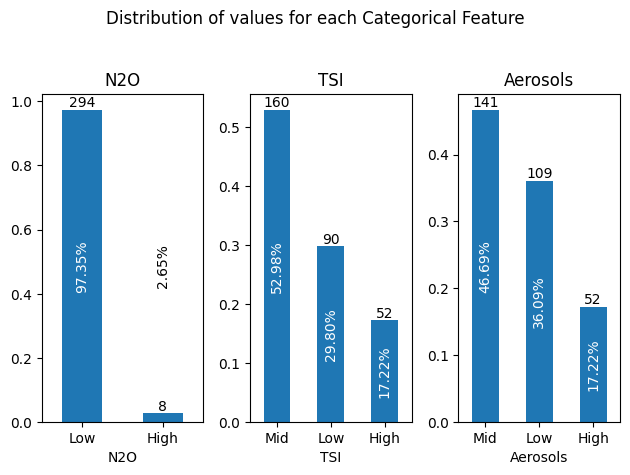

In [50]:
renaming_dict = {"H": "High", "M": "Mid", "L": "Low"}

category_order = {"Low": 0, "Mid": 1, "High": 2}

categorical_features = data.dtypes[data.dtypes == "object"].index
n = len(categorical_features)

fig, ax = plt.subplots(1, n)

# plot for each catgorical variable
for i in range(n):
    feature = categorical_features[i]
    ax = plt.subplot(1, n, i + 1)
    ax.set_title(feature)
    data[feature].value_counts(normalize=True).plot(kind="bar", rot=90)
    # Get the actual counts (not normalized)
    counts = data[feature].value_counts()
    # For each bar, add an annotation with the count
    for i, v in enumerate(counts):
        # print(i,v)
        ax.text(
            i, counts.values[i] / sum(counts.values), f"{v}", ha="center", va="bottom"
        )
        # Calculate percentage
        percentage = counts.values[i] / sum(counts.values) * 100
        if percentage > 5:  # Only show if > 5%
            ax.text(
                i,
                counts.values[i] / sum(counts.values) * 0.5,
                f"{percentage:.2f}%",
                ha="center",
                va="center",
                rotation=90,
                c="white",
            )
        else:
            mid = counts.mode()[1]
            ax.text(
                i,
                mid / sum(counts.values) * 0.5,
                f"{percentage:.2f}%",
                ha="center",
                va="center",
                rotation=90,
            )

    current_labels = [label.get_text() for label in ax.get_xticklabels()]
    new_labels = [renaming_dict[label] for label in current_labels]
    ax.set_xticklabels(new_labels, rotation=0)

fig.suptitle("Distribution of values for each Categorical Feature")
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

In [51]:
# Assessing mode per category
def calculate_mode_percentage(df):
    results = []
    for column in df.select_dtypes(include=["object", "category"]).columns:
        value_counts = df[column].value_counts(normalize=True)
        mode_value = value_counts.idxmax()
        percentage = value_counts.max() * 100
        results.append(
            {"Variable": column, "Mode": mode_value, "Percentage": round(percentage, 2)}
        )
    return pd.DataFrame(results)

modes_df = calculate_mode_percentage(data)

print("mode statistics:")
print(modes_df)

mode statistics:
   Variable Mode  Percentage
0       N2O    L       97.35
1       TSI    M       52.98
2  Aerosols    M       46.69


<span style="color:LightSkyBlue">

We observed that the data for the variable `N20` has a lack in variation (since 97.35% of the values all have the value 'L'). This means that it has low predictive power and will not contribute much to the model. As for the remaining two variables, despite having a relatively high dominant value contributing to 52.98% of the data, we have determined that it is still acceptable and thus will include it as a feature of our model.

----

<span style="color:LightSkyBlue">

Additionally, we also recognise that there is some element of seasonality to the data, since certain features like `CH4` oscillate about a non-linear trend line:

In [52]:
def plot_variable_with_year_dividers(variable, df, title=None):
    """
    Plots a line graph of the input variable and adds dotted line dividers for each year.
    
    Parameters:
    -----------
    variable : str
        The name of the column to plot
    df : pandas.DataFrame
        The dataframe containing the data
    title : str, optional
        Custom title for the plot
    """
    # plt.figure(figsize=(12, 6))

    # Plot the variable
    plt.plot(df.index, df[variable], label = 'variable')
    df2 = df.copy()
    MA = df2[variable].rolling(window=12).mean()
    plt.plot(df2.index,MA,label = variable+'_MA')
    # Get unique years in the data
    years = df['Year'].unique()

    # Add dotted line dividers for each year
    for year in years[1:]:  # Skip the first year to avoid a line at the beginning
        # Find the first index of each year
        idx = df[df["Year"] == year].index[0]
        plt.axvline(x=idx, color="gray", linestyle="--", alpha=0.7)
        # Add year label
        plt.text(
            idx,
            plt.ylim()[1]- (plt.ylim()[1] - plt.ylim()[0]) * 0.5,  # Position the text above the line
            str(year),
            horizontalalignment="center",
            verticalalignment="center",
            rotation=-90,
            alpha=0.5,
            color='dimgrey'
        )

    # Set labels and title
    plt.xlabel('Time')
    plt.ylabel(variable)
    plt.title(title if title else f'{variable} over time with year dividers')
    plt.grid(True, alpha=0.3)

    # Remove x-tick labels as they can get crowded
    plt.xticks([])

    plt.tight_layout()
    plt.show()

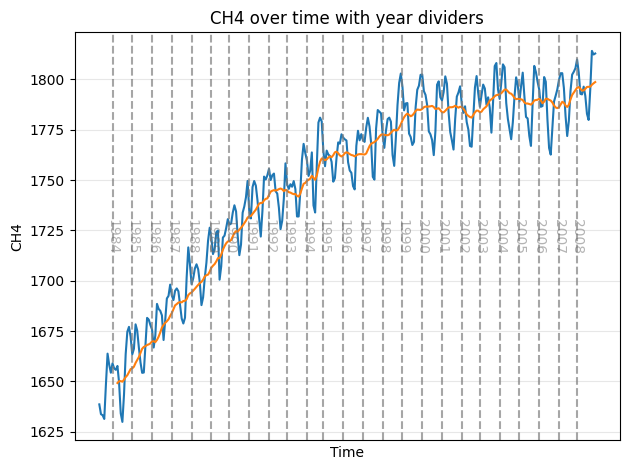

In [53]:
plot_variable_with_year_dividers('CH4',data)

<span style="color:LightSkyBlue">

We can observe that there are fluctuations about a moving average in these variables within each year that are generalizable, and thus it wil be meaningful to encode such data into our regression model.
  
Thus, we will create the following categorical features from the `Month` feature:
- `Season` &mdash; where we have defined four seasons (`spring`, `summer`, `autumn` and `winter`) and have decided to classify 3 months under each season, and to subsequently one-hot encode this data.
- `Month_sin` and `Month_cos` &mdash; since the `Month` feature cycles from 1 to 12, it is limiting to solely use integer encoding for each month. Hence, we will create a feature that is able to show this using the unique properties of the sine and cosine curves.

In [54]:
#dictionary for mapping month to season
season_mappings = [
    ([1, 2, 12], 'winter'),
    ([3, 4, 5], 'spring'),
    ([6, 7, 8], 'summer'),
    ([9, 10, 11], 'autumn')]

seasons_dict = {
    month: season
    for months, season in season_mappings
    for month in months}

# Create a new 'seasons' column in the DataFrame
data['Season'] = data['Month'].astype(int).map(seasons_dict)
one_hot_seasons = pd.get_dummies(data[['Season']])
one_hot_seasons_cols = one_hot_seasons.columns.to_list()
# Display the first few rows to verify
data = data.join(one_hot_seasons)

# add cyclical encoding for months
def encode(data, col, max_val):
    data[col + '_sin'] = np.sin(2 * np.pi * data[col]/max_val)
    data[col + '_cos'] = np.cos(2 * np.pi * data[col]/max_val)
    return data

data = encode(data, 'Month', 12)
print(data.head(1))

   Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
0  1983    5.0  2.556  345.96  1638.59   L  191.324  350.113   M        H   

   ...  Aerosols_ord  N2O_ord  TSI_ord  Season  Season_autumn Season_spring  \
0  ...             2        0        1  spring          False          True   

   Season_summer  Season_winter  Month_sin  Month_cos  
0          False          False        0.5  -0.866025  

[1 rows x 22 columns]


<span style="color:LightSkyBlue">

We will now visualise the distribution of data among these seasonal features:

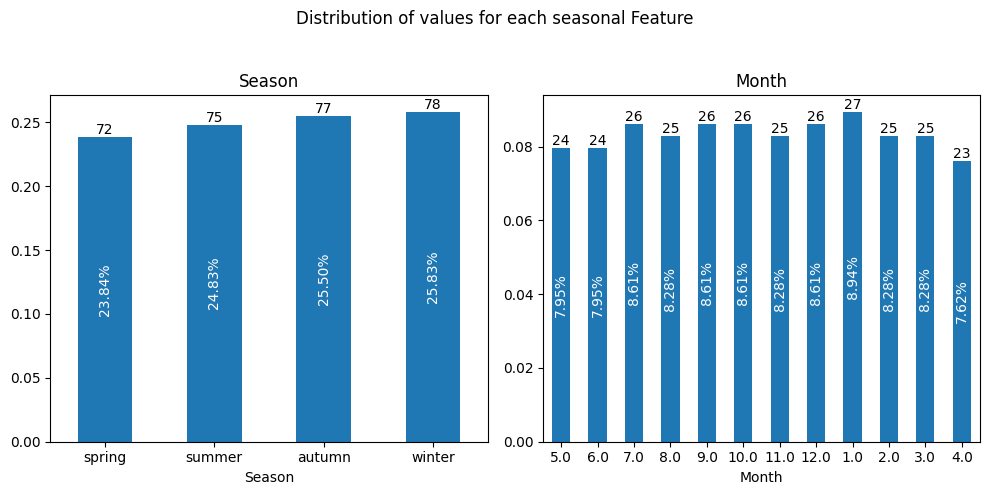

In [55]:
season_features = ['Season','Month']

n = len(season_features)
fig, ax = plt.subplots(1, n)
fig.set_size_inches(10, 5)

# plot for each catgorical variable
for i in range(n):
    feature = season_features[i]
    ax = plt.subplot(1, n, i + 1)
    ax.set_title(feature)
    plot_data = data[feature].value_counts(normalize=True)[data[feature].unique()]
    plot_data.plot(kind="bar", rot=90)
    # Get the actual counts (not normalized)
    counts = data[feature].value_counts()[data[feature].unique()]
    # For each bar, add an annotation with the count
    for i, v in enumerate(counts):
        # print(i,v)
        ax.text(
            i, counts.values[i] / sum(counts.values), f"{v}", ha="center", va="bottom"
        )
        # Calculate percentage
        percentage = counts.values[i] / sum(counts.values) * 100
        if percentage > 5:  # Only show if > 5%
            ax.text(
                i,
                counts.values[i] / sum(counts.values) * 0.5,
                f"{percentage:.2f}%",
                ha="center",
                va="center",
                rotation=90,
                c="white",
            )
        else:
            mid = counts.mode()[1]
            ax.text(
                i,
                mid / sum(counts.values) * 0.5,
                f"{percentage:.2f}%",
                ha="center",
                va="center",
                rotation=90,
            )
    
    plt.xticks(rotation=0)

fig.suptitle("Distribution of values for each seasonal Feature")
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

<span style="color:LightSkyBlue">

Both `seasons` and `Month` have a good distribution of values, each with the modal value contributing 25.83% and 8.94% of the data, thus they have strong predicting power and should be included as a feature of our model.

----

<span style="color:LightSkyBlue">

Now, we will visualising how each of our categorical variables vary with each other. However, as `Months` is a more granular version of the feature `Season`, we will exclude `Months` from this visualisation.

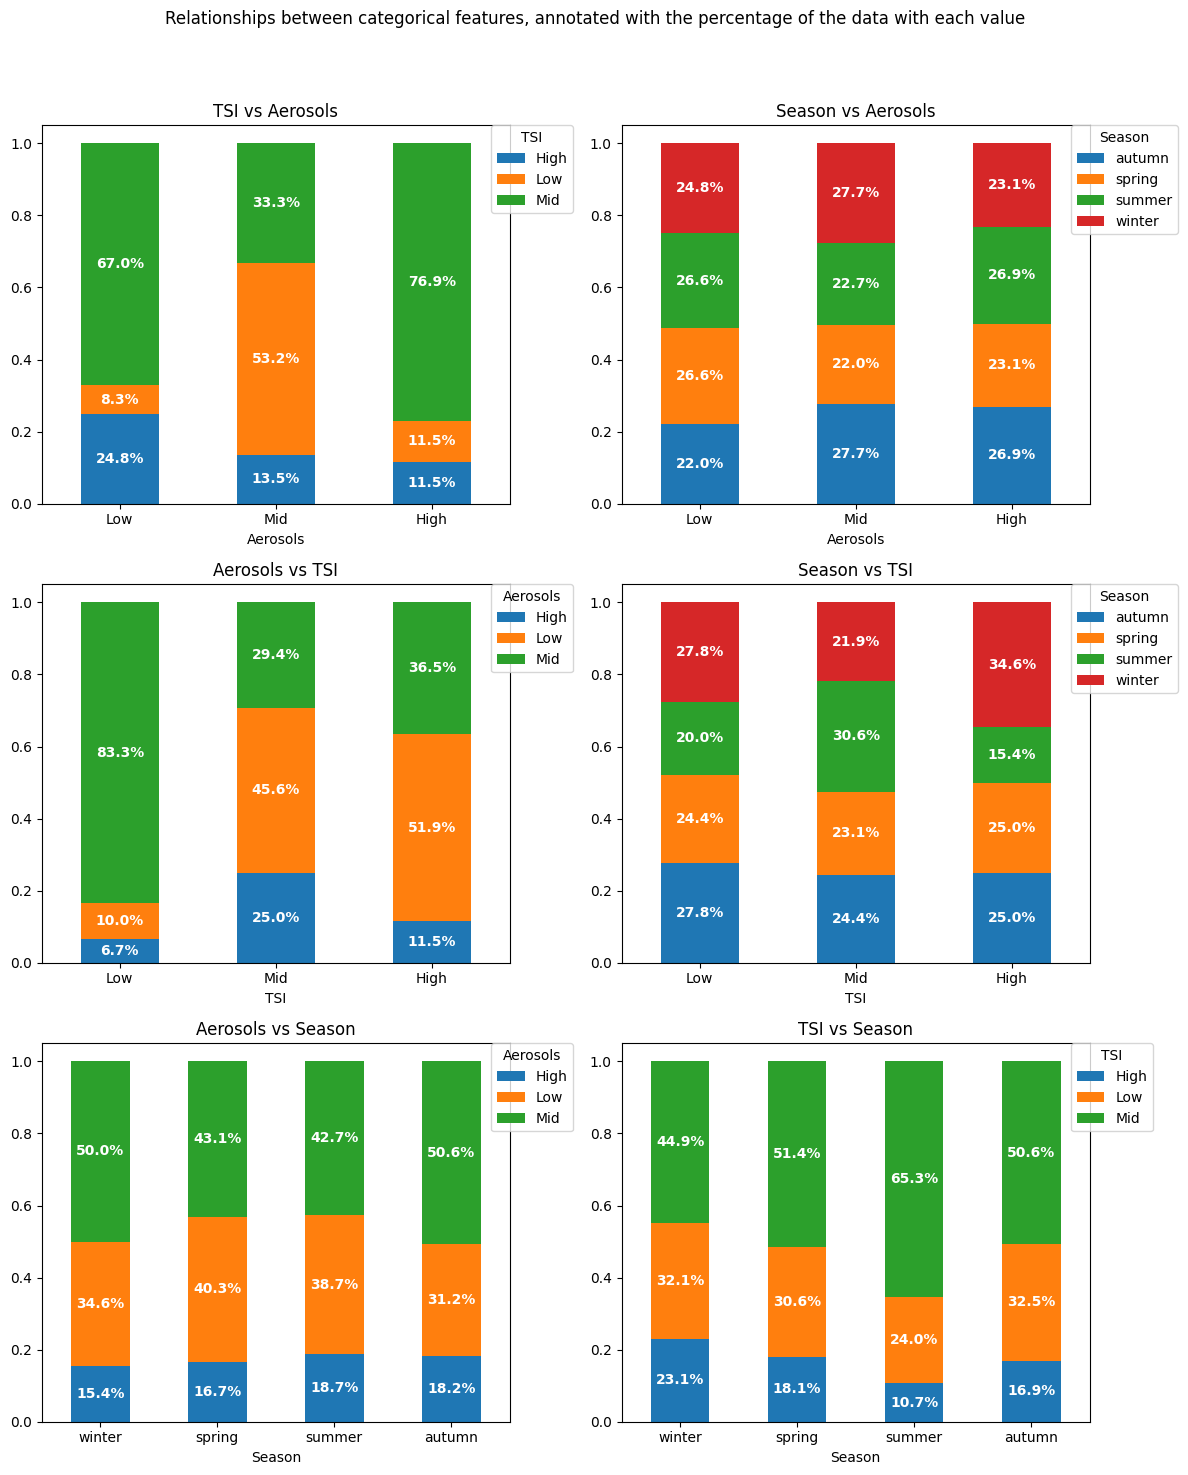

In [56]:
plot_cat_features = ['Aerosols','TSI','Season']

n = len(plot_cat_features)
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

plot_num = 0

for indep in plot_cat_features:
    for dep in plot_cat_features:
        if indep == dep: continue
        plot_num+=1
        ax = plt.subplot(3,2,plot_num)
        
        # Get crosstab data
        cross_data = pd.crosstab(data[indep], data[dep], normalize="index")
        
        # Sort categories for Aerosols and TSI in the order: Low, Mid, High
        if indep in ['Aerosols', 'TSI']:
                cross_data = cross_data.reindex(['L', 'M', 'H'])
        else:
                cross_data = cross_data.reindex(['winter', 'spring','summer', 'autumn'])
            
        
        # Plot the crosstab
        cross_data.plot.bar(stacked=True, ax=ax)
                
        # Get the bar positions
        bar_positions = np.arange(len(cross_data.index))
                
        for i, (idx, row) in enumerate(cross_data.iterrows()):
            bottom = 0
            for col, val in row.items():
                if val > 0.05:  
                    ax.text(i, bottom + val/2, f'{val:.1%}', 
                            ha='center', va='center', color='white', fontweight='bold')
                bottom += val
                
        current_labels = [label.get_text() for label in ax.get_xticklabels()]

        handles, labels = ax.get_legend_handles_labels()

        renamed_labels = [renaming_dict.get(lbl, lbl) for lbl in labels]
        ax.legend(handles, renamed_labels, bbox_to_anchor=(0.96, 1), loc='upper left', borderaxespad=0., title=dep)
        if indep != 'Season':
            new_labels = [renaming_dict[label] for label in current_labels]
            ax.set_xticklabels(new_labels, rotation=0)
        
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.set_title(f'{dep} vs {indep}')  # Add a title to the first plot
        
fig.suptitle('Relationships between categorical features, annotated with the percentage of the data with each value')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

<span style="color:LightSkyBlue">

We can observe the following from a visualisation of the proportion of the each categorical variable relative to the other:

- **Aerosols and TSI**:
    - For high and low levels of aerosols, the TSI seems to usually be medium. This contradicts our expectation as intiutively, there should be an inverse relationship. Higher Aerosol levels mean that the concentration of particles in the atmosphere increases, thus blocking and absorbing more solar radiation and causing TSI readings to decrease. 
        - However, this inverse relationship only seems to be the case for high TSI readings.
        - Most of the medium TSI readings occur when Aerosol levels are extreme (high and low levels), likely due to calibration and certain weather phenomena, while most of the low TSI readings occur at medium Aerosol levels likely due to their [interactions with cloud formation](https://www.giss.nasa.gov/edu/icp/research/ppa/1997/reyes/) helping clouds scatter and deflect light.

        - Relevant research indicates that the most important factor affecting the amount of solar radiation reaching the earth׳s surface under cloudless sky conditions is the presence of aerosol particles (Khalil, Shaffie, 2016). At high level of aerosols, more sunlight is scattered or absorbed which leads to an expectation of a low TSI. However, since there are many common aerosol-induced chemical reactions that deplete the ozone, more UV radiation actually reaches the surface which boosts TSI, counteracting the dimming effect of aerosols. (Kulmala et al., n.d.) Hence, the TSI level might be medium instead of the expected low. Similarly, at low levels of aerosols, a high TSI is expected due to less scattering. However, if there ozone concentrations are intact, they will absorb significant amounts of harmful UV and shortwave radiation, possible limiting TSI levels to medium. (Li et al., 2022).

        - The Low TSI levels at medium Aerosol levels seems to be because medium aerosol levels provide an ideal number of cloud condensation nuclei (CCN). This results in the "Twomey effect" where  clouds become more reflective with more CCN. Hence, less solar radiation reaches the Earth's surface and the TSI level is measured to be low. (Quaas et al., 2020)

    - For instances with low levels of TSI, it seems that a majority of the associated instances seem to have medium aerosol levels, indicating that there might be a correlation between this specific level of solar irradiance that causes the composition of aerosols in the atmosphere to have a medium composition. Relevant research indicates that this might be because the relationship between aerosols and TSI is bidirectional. While high TSI can increase ionization rates and aerosol nucleation, low TSI may limit these processes, preventing extremely low aerosol concentrations. At the same time, pre-existing aerosols can scatter solar radiation, maintaining TSI at a lower level. This feedback loop may stabilize aerosol concentrations at a medium level under low TSI conditions. (Kulmala et al., 2023)

    - For instances with medium levels of TSI, we observe that aerosol levels tend to vary — appearing as either low or high, rather than consistently medium. This suggests that medium solar irradiance might serve as a transition point in the aerosol–TSI feedback loop. The medium TSI reflects a dynamic equilibrium, where external factors (e.g. composition and atmospheric chemistry) determine whether aerosol levels skew high or low. This variability highlights the nonlinear and bidirectional nature of the TSI–aerosol relationship.

- **Aerosols and Season**:
    - The Aerosol levels appear to be well distributed across each season.
    - The proportion of aerosol levels in descending order is Mid, low, high.
    - In the autumn and winter seasons, there seems to be a higher level of aerosols (to mid and high levels). This might be in response to the increased burning of energy sources to generate heat due to the temperature dip in the colder seasons.
        - Aerosol levels can be affected by biomass burning, industrial activity, volcanic eruptions, and dust storms—but these events are not strictly seasonal and vary by region and source. Kaufman et al. (2005)

- **TSI and Season**:
    - The TSI levels appear to be well distributed across all seasons, especially autumn and spring.
        - This might be because TSI variability is primarily driven by the 11-year solar cycle, not seasonal changes. The total solar irradiance varies by only about 0.1% across the solar cycle, a change too small to cause significant seasonal patterns in TSI datasets. (Cermak, 2023). 
    - However, it is odd to see that a large proportion of high TSI levels come from the winter months instead of summer, and a large proportion of the medium TSI levels come from the summer months instead of spring or autumn. 
        - [This indicates that the location that these readings were taken can be localised to the northern hemisphere, where the sun is closer to the earth during winter.](https://www.energy.gov/eere/solar/solar-radiation-basics)

Thus, these 3 variables are worthy for inclusion into our model since they each exhibit unique relationships with each other.

---

<span style="color:LightSkyBlue">

We can also look into how the response variable `Temp` is related to these variables.  To do that we plot a grouped boxplot and see the distribution of `Temp` across different categories for `Aerosols` and `TSI`:

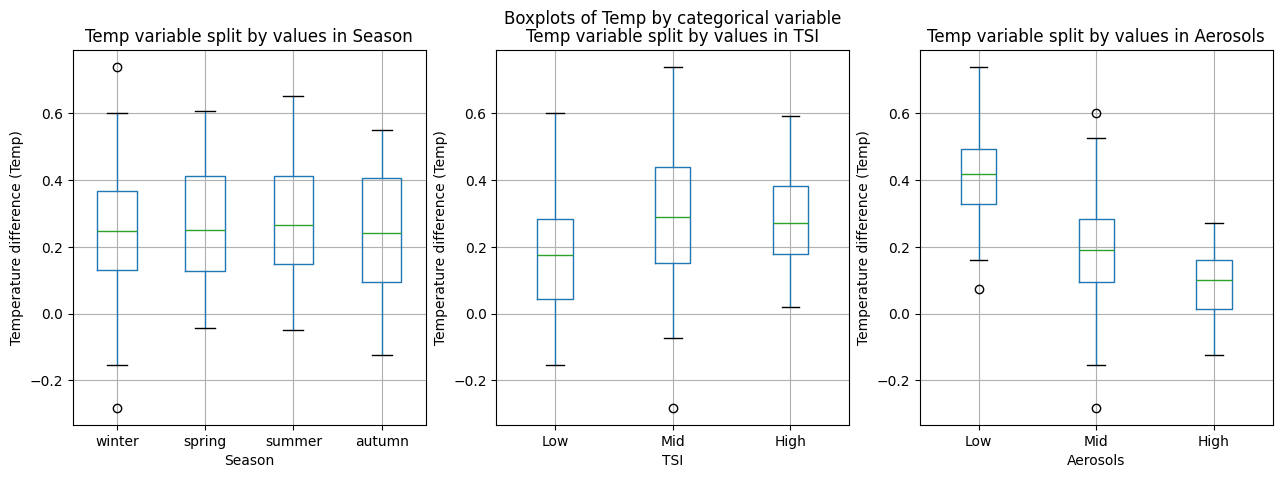

In [57]:
n = len(plot_cat_features)

r, c = 1, 3
fig, ax = plt.subplots(r, c, figsize=(15, 5))

for i in range(n):
    feature = plot_cat_features[::-1][i]
    ax = plt.subplot(r, c, i + 1)
    
    if feature == 'Season':
        # Sort the Season category into the desired order
        data['Season'] = pd.Categorical(data['Season'], categories=['winter', 'spring', 'summer', 'autumn'], ordered=True)
        # For Aerosols and TSI, sort categories in order: Low, Mid, High
    else:
            # Create a categorical variable to ensure sorting
        order = ['L', 'M', 'H']
        data[feature] = pd.Categorical(data[feature], categories=order, ordered=True)

    data[[feature, 'Temp']].boxplot(by=feature, ax=ax, rot=90)    
    # Format labels
    if feature != 'Season':
        current_labels = [label.get_text() for label in ax.get_xticklabels()]
        new_labels = [renaming_dict[label] for label in current_labels]
        ax.set_xticklabels(new_labels, rotation=0)
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    ax.set_ylabel("Temperature difference (Temp)")
    ax.set_xlabel(feature)
    ax.set_title(f"Temp variable split by values in {feature}")

fig.suptitle("Boxplots of Temp by categorical variable")

plt.show()

<span style="color:LightSkyBlue">

We can observe the following from a visualisation of how the values in the `Temp` variable is distributed over specific variables:

- **Aerosols**:
    - Temperatures changes are generally higher for Low Aerosol levels, followed by Medium, then High levels. Intuitively, as Aerosol levels increase, the amount of radiation reaching the layer of atmosphere closest to earth's surface decreases, thus there is an inverse relationship seen.
        - Relevant research indicates that this might be because aerosols have a net cooling effect on the Earth’s surface. Aerosols such as sulfate particles reflect incoming solar radiation back into space, which reduces the amount of energy reaching the Earth's surface, thereby cooling it. The previously stated Twomey effect, where aerosols contribute to cloud formation and increase cloud brightness,  further enhances the Earth's reflectivity, amplifying this cooling effect. Hence, temperatures decrease as the aerosol level increases. (Storelvmo et al., 2018)

    - The range of these temperatures is much larger at medium aerosol levels. Since it is highly dependent on cloud cover as mentioned in the comparison of categorical variables and cloud cover is highly dependent on weather conditions which are volatile, this could be why there is an equally volatile spread of temperatures.
        - Relevant research indicates that this might be because the multiple effects of aerosols buffer the Earth's surface against sharp temperature shifts, resulting in a narrower temperature spread during periods of high aerosol concentration. For instance, the previously stated Twomey effect, combined with the scattering of incoming solar radiation, leads to longer-lived, brighter clouds that reflect more sunlight and trap less heat during the day while also moderating cooling at night. This reduction in both daytime heating and nighttime cooling decreases the diurnal temperature range, contributing to the observed narrowing of temperature variation under high aerosol conditions. (Pithan & Schatt, 2024)
    - The small range of temperature changes at high Aerosol levels indicates that it has a strong relationship with temperature changes at this level.
- **TSI**:
    - Temperatures changes are generally higher for medium TSI levels, followed by High and Low TSI levels. Furthermore, the median temperature change is positive for High and medium TSI levels, while it is negative for low TSI levels. This intuitively corresponds with the theory that higher TSI levels means more sunlight is reaching the atmosphere nearest to earth's surface, thus causing an increase in temperature.
        - Relevant research indicates that this might be because medium TSI levels, represent optimal solar energy input, not extreme enough to trigger feedback like increase cloud formation. Hence, it allows for more energy to reach the surface without strong compensatory cooling effects, resulting in more consistent warming and a higher median temperature. (Gray et al., 2010)
    - The range of temperatures is relatively small for high TSI levels. This indicates that it has a strong, consistent influence on temperature changes at that specific level.
- **Season**:
    - Temperature changes are generally consistent across all seasons except winter, which has a larger spread relative to the other seasons, and even has outliers (defined as changes that differ from the first or third quartiles by 1.5 times the interquartile range). This might be due to the [low humidity of the air, which has a lower heat capacity (since water vapour helps to absorb infrared radiation)](https://www.hko.gov.hk/en/education/weather/meteorology-basics/00004-what-is-radiation-cooling.html#:~:text=Moisture%20in%20the%20air%20keeps,off%20faster%20than%20moist%20air.&text=cooling%20at%20night-,In%20winter%2C%20a%20large%20temperature%20difference%20sometimes%20exists%20between%20the,areas%20and%20the%20New%20Territories.) and thus this amplifies the temperature changes caused by weather phenomena.

---

<span style="color:LightSkyBlue">

Hence, we will only include the features `TSI`, `Aerosols`,`Month` and `Season` in our model, and drop `N2O`.

Additionally, we will use the encoded versions of the variables instead, storing them in the array under the variable `cat_features_selected`.

In [58]:
exclude = ['N2O']

mask = data.dtypes.reindex(data.dtypes.index) == "object" 
mask2 = data.dtypes.reindex(data.dtypes.index) == "category"
cat_features_selected = list(data.dtypes[mask | mask2].index)
print(cat_features_selected)

# lazy filtering, removes N2O and other unwanted categorical variables, modifies references to encoded ones from part 1
cat_features_selected_u = list(i for i in cat_features_selected if i not in exclude) # use this to refer to raw categorical variable values
cat_features_selected_u.append('Month')

all_cols = data.dtypes.index.tolist()

#from cat features, get encoded versions by splitting using '_' and check if list only has 1 element
cat_features_selected = [i for i in all_cols if i.split('_')[0] in cat_features_selected_u and len(i.split('_'))!=1] 

print("Categorical features remaining:")
print(', '.join(cat_features_selected_u))
print("Encoded Categorical features remaining:")
print(', '.join(cat_features_selected))


['N2O', 'TSI', 'Aerosols', 'Season']
Categorical features remaining:
TSI, Aerosols, Season, Month
Encoded Categorical features remaining:
Aerosols_ord, TSI_ord, Season_autumn, Season_spring, Season_summer, Season_winter, Month_sin, Month_cos


<span style="color:LightSkyBlue">

## **Feature Selection for numerical variables**

<span style="color:LightSkyBlue">

For numerical variables, we first investigated the distribution of each variable by plotting bargraphs as shown below.

In [59]:
# confirm the numerical variables we are working with
numerical_features = data.dtypes[data.dtypes!="object"].index
cat_encoded = set(cat_features_selected+['N2O_ord'])
numerical_features = list(set(numerical_features) - set(cat_features_selected_u + ['N2O']) - set(cat_encoded))
print(f"we are handling the following {len(numerical_features)} numerical features:")
print(numerical_features)

we are handling the following 8 numerical features:
['continuous_months', 'MEI', 'CO2', 'Year', 'Temp', 'CH4', 'CFC-11', 'CFC-12']


<span style="color:LightSkyBlue">

We use the function `print_histogram` to visualise the histograms of all the numerical variables in a square grid of subplots.

In [60]:
# function to plot data
def print_histogram(data, num_features):
    x, y = len(num_features), 1

    # calculate best integer to get a square grid
    while x > (y**2):
        y += 1

    # set graph layout parameters
    SCALE_FACTOR = 5  # size of each plot
    plot_h, plot_w = y, y  # how many columns of plots

    # set figure dimensions and subplot layout
    fig, axes = plt.subplots(
        plot_h,
        plot_w,
        figsize=((SCALE_FACTOR + 2) * plot_w, (SCALE_FACTOR + 2) * plot_h),
    )

    n = len(num_features)

    for i in range(n):
        feature = num_features[i]
        ax = plt.subplot(plot_h, plot_w, i + 1)
        freq, bins, patches = ax.hist(data[feature], bins=20, edgecolor="white")
        bin_centers = np.diff(bins) * 0.5 + bins[:-1]

        h = 0
        for fr, x, patch in zip(freq, bin_centers, patches):
            height = int(freq[h])
            ax.annotate(
                "{}".format(height),
                xy=(x, height),
                xytext=(0, 0.2),
                textcoords="offset points",
                ha="center",
                va="bottom",
            )
            h += 1

        ax.set_title(f"Distribution of {feature} \n (with labelled frequencies)", fontsize=10)
        ax.set_xlabel(feature, fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)

    plt.show()


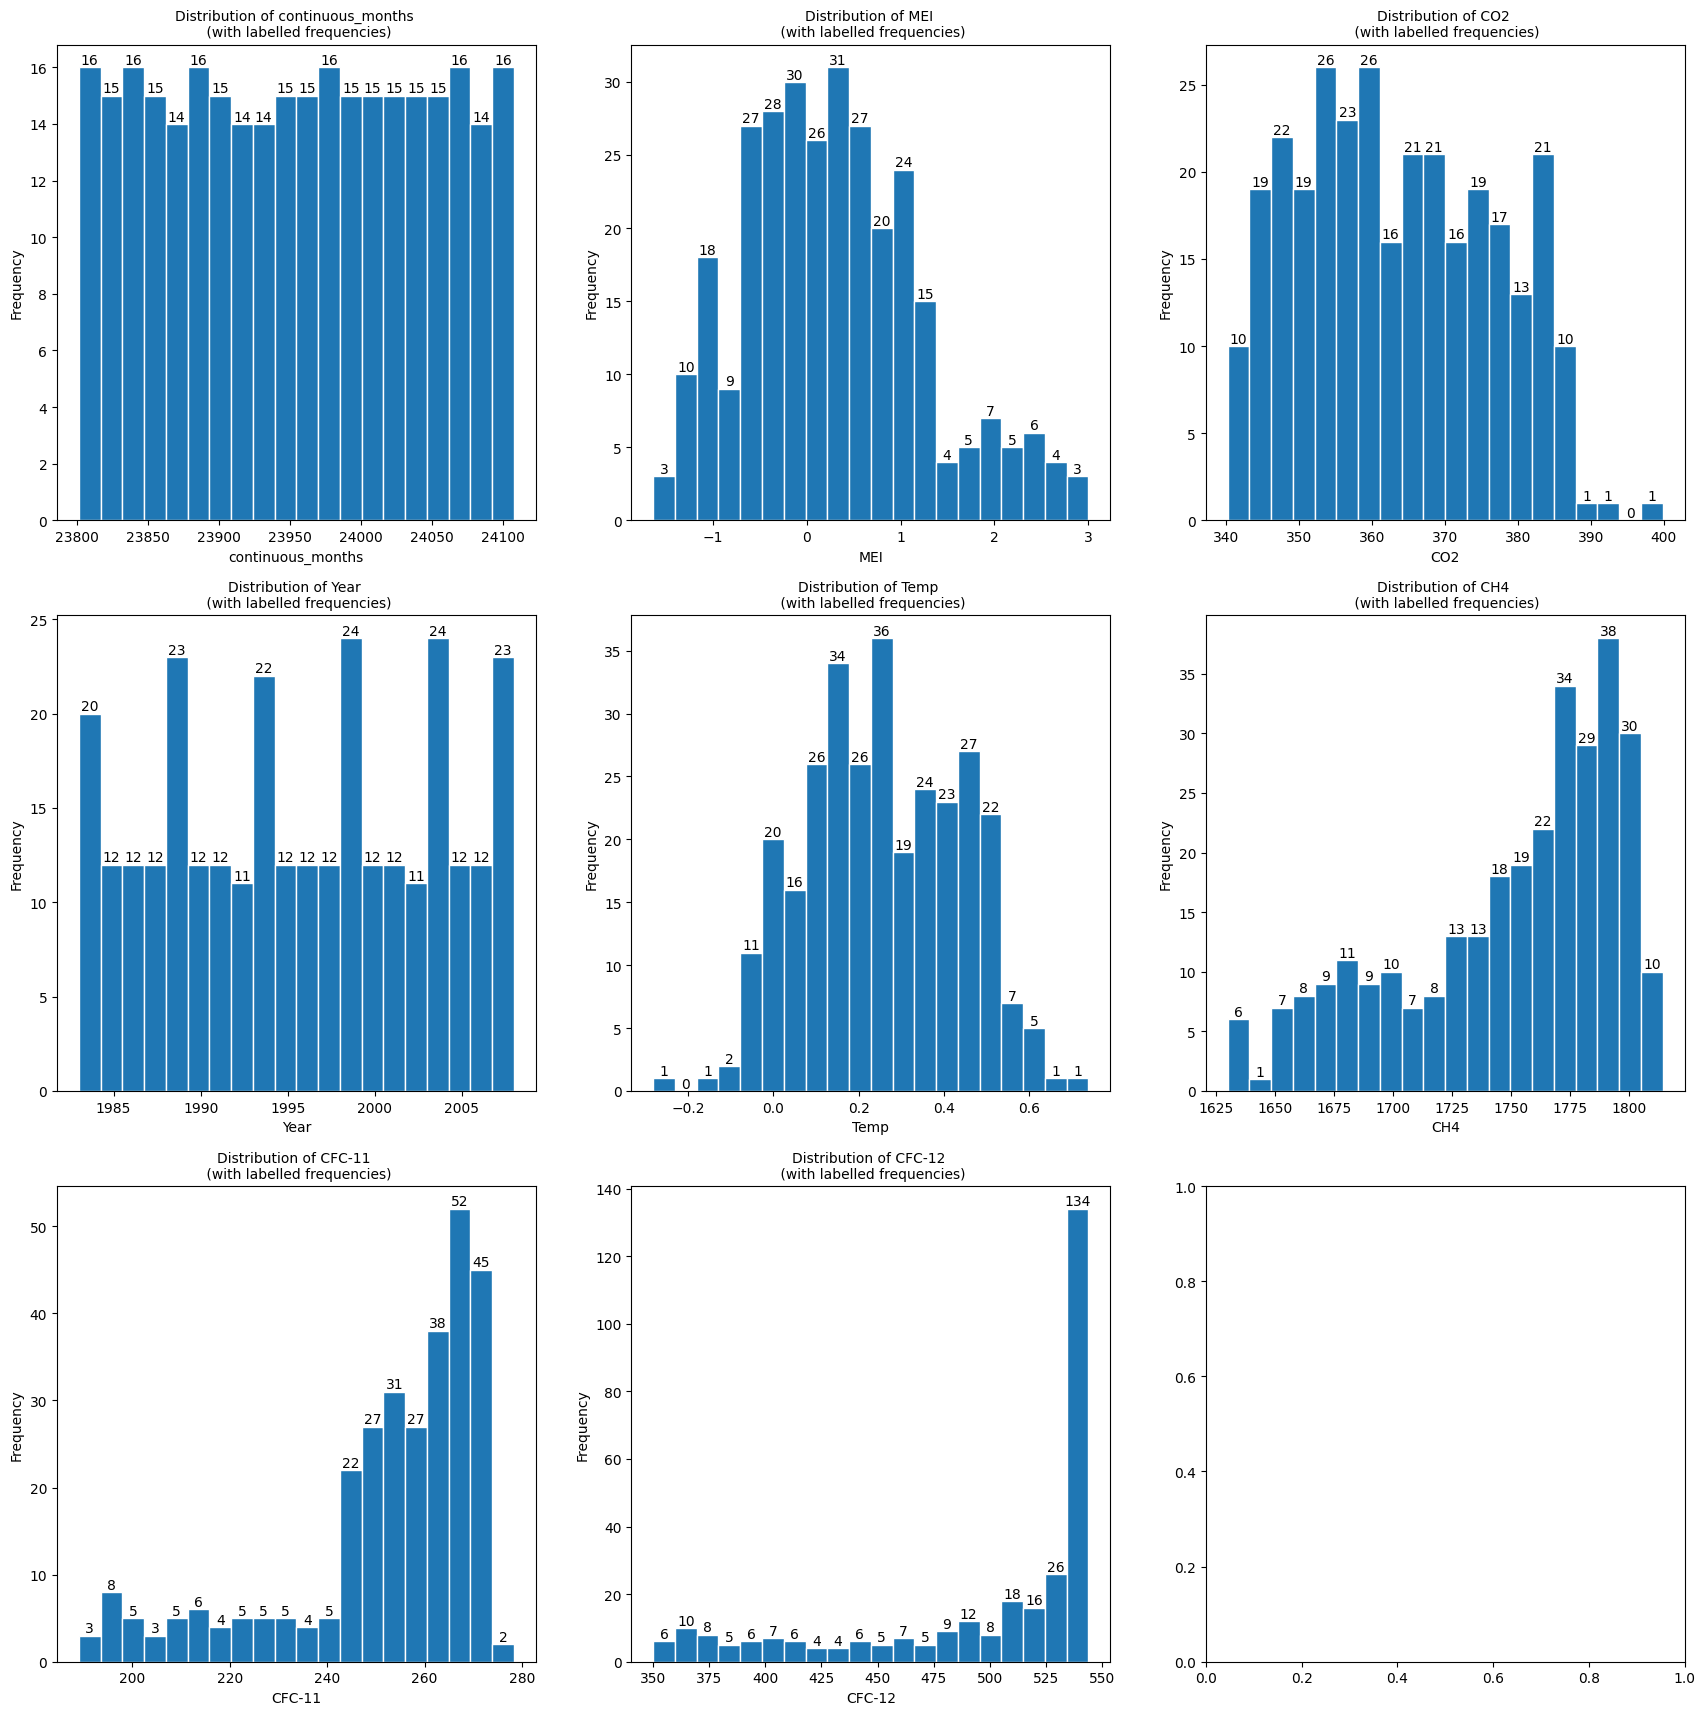

In [61]:
print_histogram(data,numerical_features)

<span style="color:LightSkyBlue">

Outside of the exploration that has been documented in part 1, we noted the following based on a visual observation of the data:
- Given that `CFC-11` and `CFC-12` are somewhat similar since they are both chloroflourocarbons, we could consider creating a new feature that groups them together in some way.
- `MEI` seems to be Bimodal, thus it may not be a good feature on its own for predicting `Temp`.
- With observations derived from part 1, we have determined that there are time-series elements to the data (most evidently seen with `CH4` and `CO2`) and thus we will create some new features from decomposing these trends. Furthermore, we acknolwedge that it may be more significant to predict the current global temperature than the change since the significant effects of all the recorded variables appear to be cummulative on their absolute value as opposed to their change. We will also instead be creating the feature `Temp_cs`, representing a cummulative sum of the temperature changes, and use that as our response variable.
- `CFC-12` and `CFC-11` each are highly skewed values. We will likely need to perform a log transformation to mitigate the effect of its skewness. (to assess how significant doing this is, we will simply compare visually using a quartile-quartile plot of a normal distribution how significant this transformation is.)

<span style="color:LightSkyBlue">

Thus, we will do the following for numerical feature selection:
1. Exclude the `Year` and `Month` variable from our selected features
2. Find a suitable combination of `CFC-12` and `CFC-11` and use that as a feature instead
3. Visualise the $r^2$ values of each pair of variables, and assess which are relevant to retain
4. Perform a log transformation to all skewed variables (`MEI`,`CH4`, and likely the new combined CFC feature.)
5. Create some features by decomposing some temporal aspects of the features to improve our model's performance.

<span style="color:LightSkyBlue">

1.  remove the features `Year` and `Month` from our numerical features

In [62]:
# declare variables that are irrelevant
irrelevant_features = ['Month','Year','continuous_months']
numerical_features = list( set(numerical_features) - set(irrelevant_features))

print(f"Numerical features ({len(numerical_features)}):")
print(numerical_features)

Numerical features (6):
['CO2', 'MEI', 'Temp', 'CH4', 'CFC-11', 'CFC-12']


<span style="color:LightSkyBlue">

2. Create variations of combining `CFC-11` and `CFC-12`, naming the variable `CFC_<op>` based on the operation performed.

In [63]:
# new feature: CFC_add = "CFC-11" + "CFC-12"
data['CFC_add'] = data['CFC-12'] + data['CFC-11']
numerical_features.append('CFC_add')

#new feature: CFC_times = "CFC-11" * "CFC-12"
data['CFC_times'] = data['CFC-11'] * data['CFC-12']
numerical_features.append('CFC_times')

print(f"Numerical features ({len(numerical_features)}):")
print(numerical_features)

Numerical features (8):
['CO2', 'MEI', 'Temp', 'CH4', 'CFC-11', 'CFC-12', 'CFC_add', 'CFC_times']


<span style="color:LightSkyBlue">

we can visualise this new set of features using the `print_historgram` function from above:

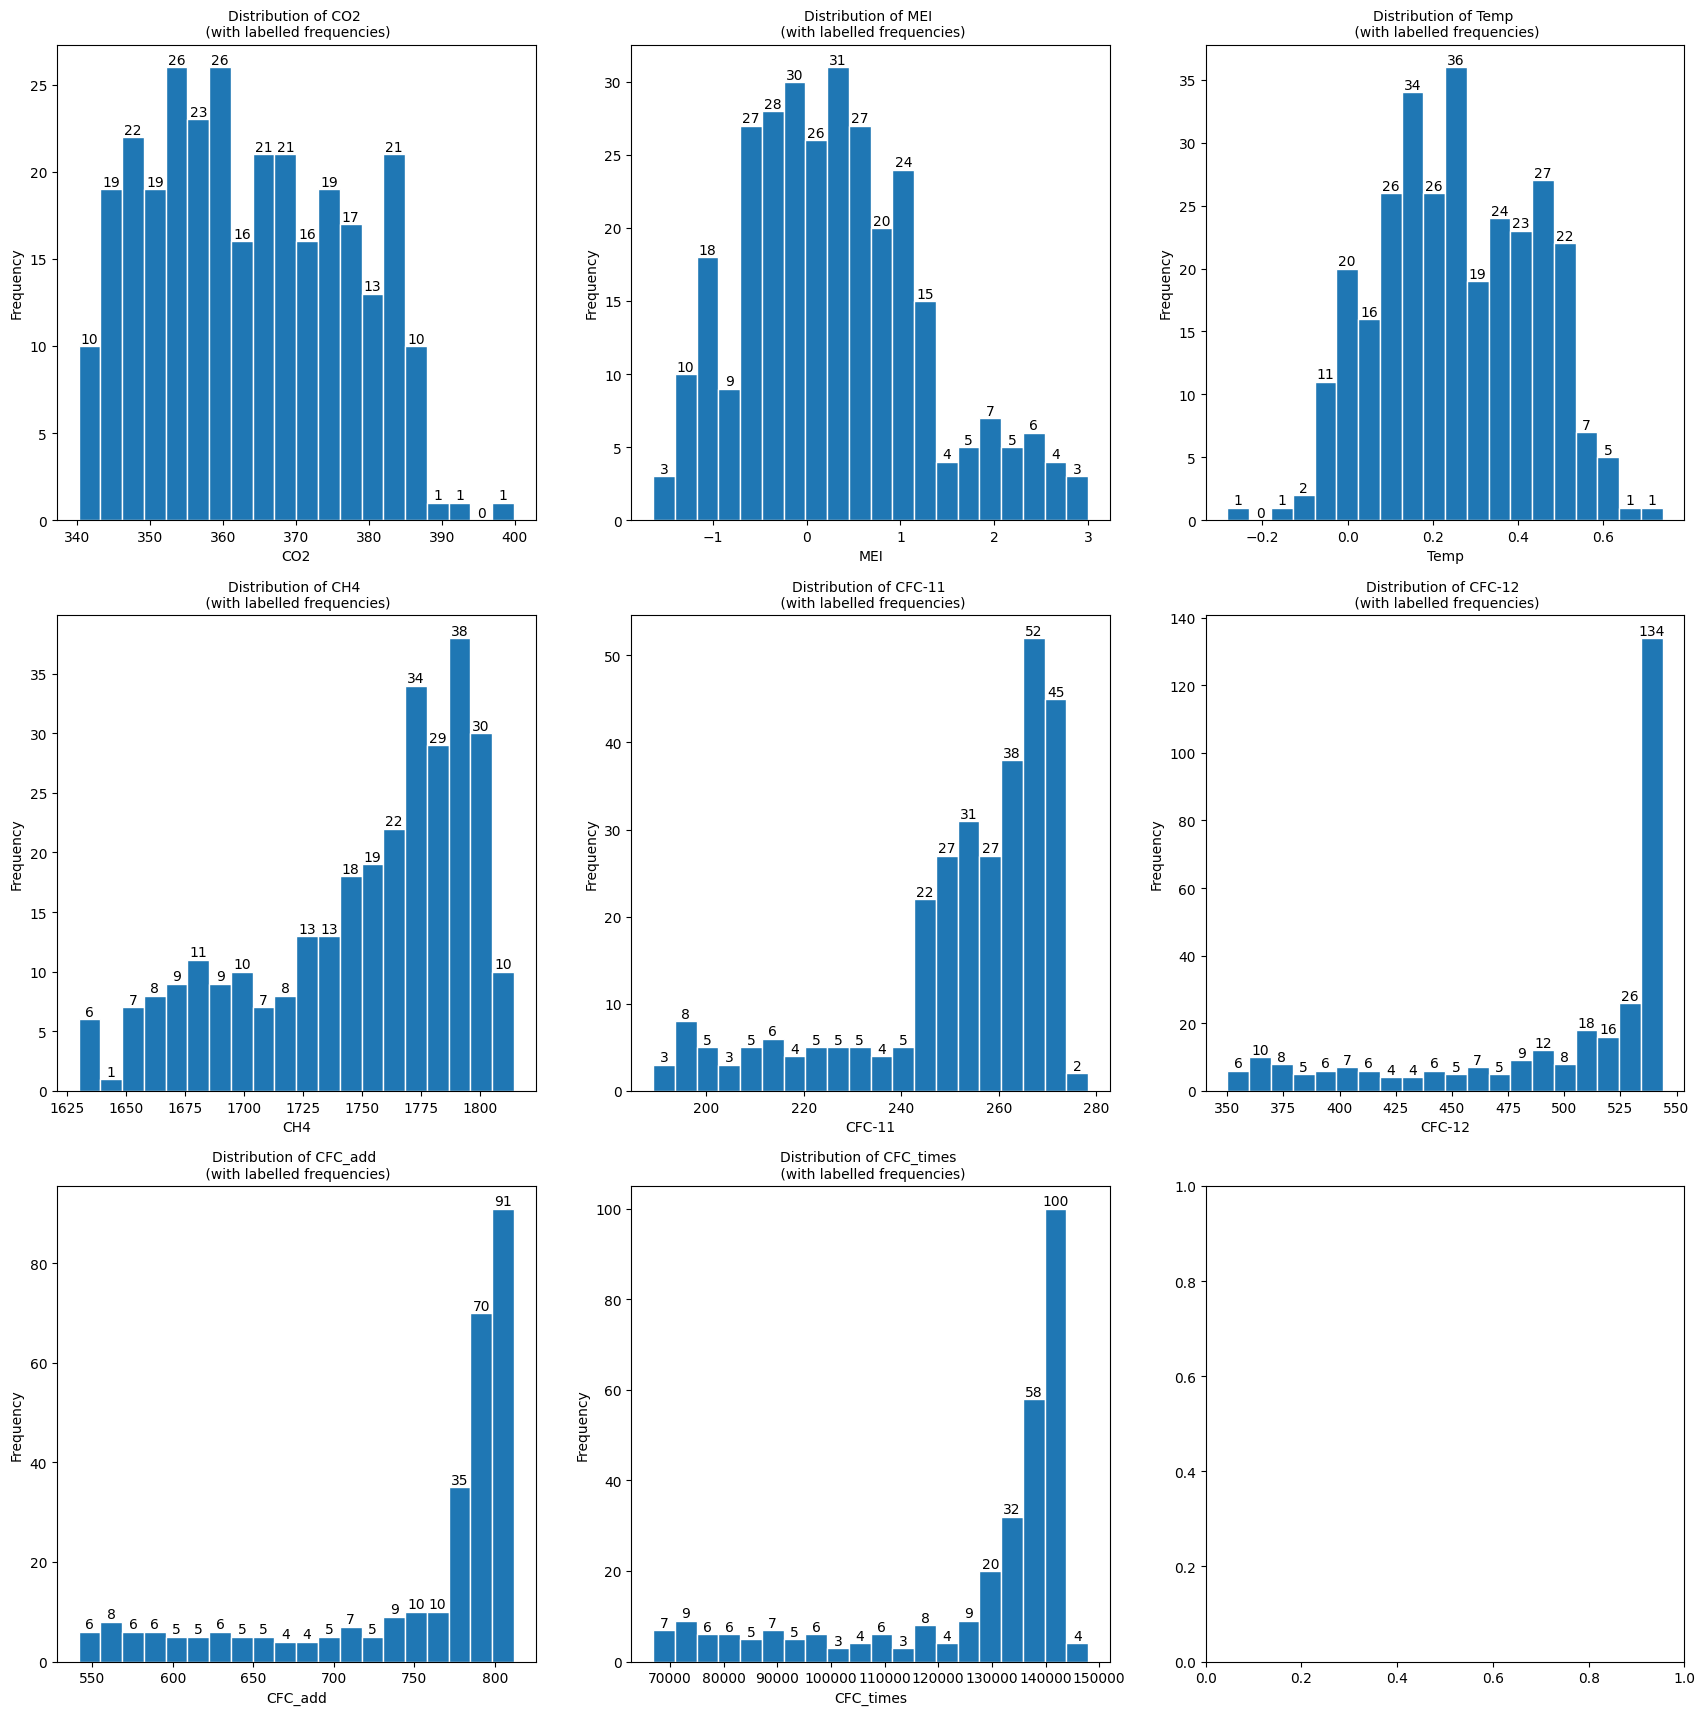

In [64]:
print_histogram(data,numerical_features)

<span style="color:LightSkyBlue">

As many of the features (namely, `MEI`,`CH4`, `CFC-11`, `CFC-12`, `CFC_add` and `CFC_times`) are highly skewed, we can use the following transformations for the following features:  
  
A quantile transformer, which will provide non-linear transformations so that our feature will better resemble a normal distribution. It is also due to the lack of data that we are assuming that certain variables adopt a normal distribution once sufficient data has been collected.

In [65]:
#normalize features using quantile transformer
from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution="normal", random_state=42, n_quantiles=data.shape[0])

features_to_norm = numerical_features.copy()

print(features_to_norm)
for i in features_to_norm:
    new_feature = i.replace('-','_')+"_norm" if '-' in i else i+"_norm"
    data[new_feature] = qt.fit_transform(data[[i]])
    numerical_features.append(new_feature)

numerical_features.sort(key=lambda x:x[-1])
print(f"Numerical features ({len(numerical_features)}):")
for i in range(0,len(numerical_features),6):
    print(f"{', '.join(numerical_features[i:i+6])}")

['CO2', 'MEI', 'Temp', 'CH4', 'CFC-11', 'CFC-12', 'CFC_add', 'CFC_times']
Numerical features (16):
CFC-11, CO2, CFC-12, CH4, MEI, CFC_add
CO2_norm, MEI_norm, Temp_norm, CH4_norm, CFC_11_norm, CFC_12_norm
CFC_add_norm, CFC_times_norm, Temp, CFC_times


<span style="color:LightSkyBlue">

We will also perform a log transformation of `CFC_add` and `CFC_times` since both of their histograms are very left-skewed.

In [66]:
data['CFC_add_lg'] = np.log(data['CFC_add'])
numerical_features.append('CFC_add_lg')

data['CFC_times_lg'] = np.log(data['CFC_times'])
numerical_features.append('CFC_times_lg')

<span style="color:LightSkyBlue">

And we will use the preprocessing function `PolynomialFeatures` to create some features and see if there are any non-linear trends present.

In [67]:
from sklearn.preprocessing import PolynomialFeatures

# Generate polynomial expansions of selected numerical features
features_to_transform = ["CO2", "CH4", "MEI"]
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_array = poly.fit_transform(data[features_to_transform])

# Add them back as new columns
new_cols = poly.get_feature_names_out(features_to_transform)
data[new_cols] = poly_array

print("Created polynomial features:", new_cols)

Created polynomial features: ['CO2' 'CH4' 'MEI' 'CO2^2' 'CO2 CH4' 'CO2 MEI' 'CH4^2' 'CH4 MEI' 'MEI^2']


<span style="color:LightSkyBlue">

We now have the following numerical variables:

In [68]:
numerical_features = list(set(numerical_features) | set(new_cols))
numerical_features.sort()
print(f"Numerical features ({len(numerical_features)}):")
for i in range(0,len(numerical_features),6):
    print(f"{', '.join(numerical_features[i:i+6])}")

Numerical features (24):
CFC-11, CFC-12, CFC_11_norm, CFC_12_norm, CFC_add, CFC_add_lg
CFC_add_norm, CFC_times, CFC_times_lg, CFC_times_norm, CH4, CH4 MEI
CH4^2, CH4_norm, CO2, CO2 CH4, CO2 MEI, CO2^2
CO2_norm, MEI, MEI^2, MEI_norm, Temp, Temp_norm


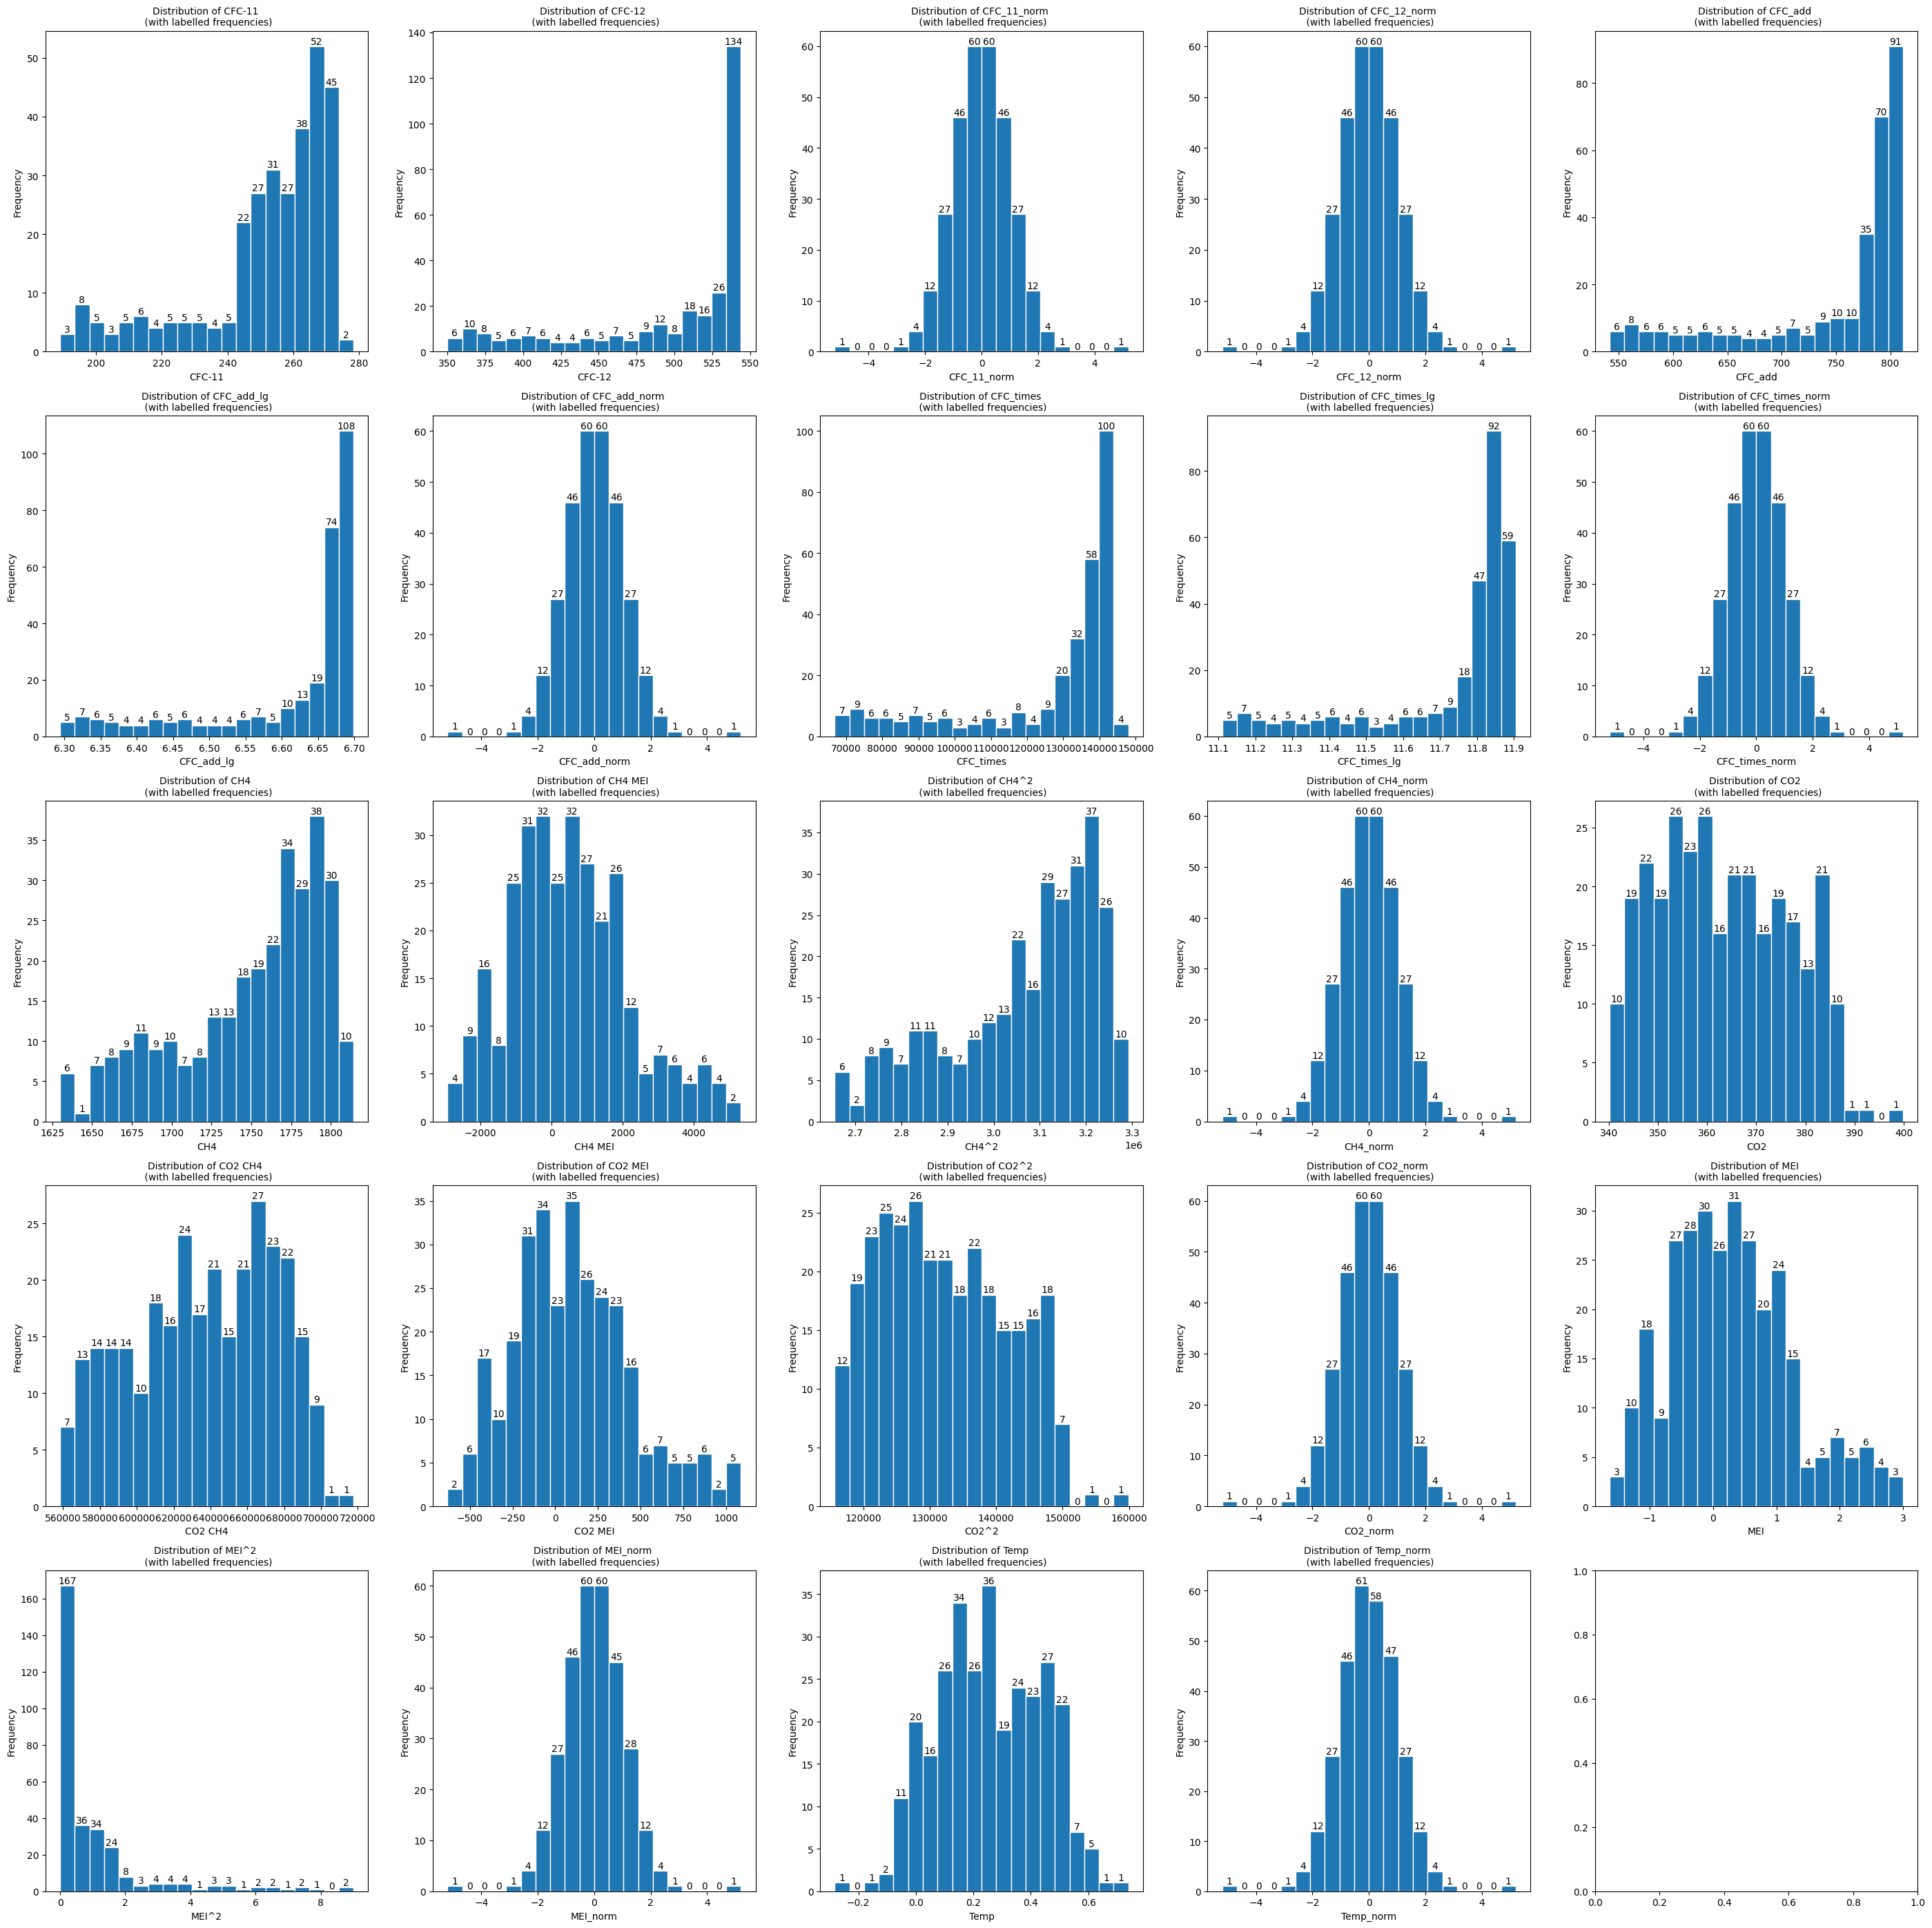

In [69]:
print_histogram(data,numerical_features)

<span style="color:LightSkyBlue">

Additionally, since most the data has a cummulative time-series aspect to it, we will instead transform the variable `Temp`, calculate the differences in its value from the moving average over a window of 1 year / 12 months (naming it `Temp_diff`), and calculate the cummulative sum of it, naming it `Temp_diff_cs`.  
  
This will be the value we will predict, and is meaningful because we can directly input the absolute amount of each chemical we have in the atmosphere to predict our response value, and reverse these calculations to obtain `Temp`.

In [70]:
from sklearn.preprocessing import StandardScaler

data["Temp_cs"] = data["Temp"].cumsum()
data["Temp_MA"] = data["Temp"].rolling(window=12).mean()
data["Temp_diff"] = data["Temp"] - data["Temp_MA"].diff()
data["Temp_diff_cs"] = data["Temp_diff"].cumsum()
numerical_features.extend(["Temp_cs",'Temp_MA',"Temp_diff",'Temp_diff_cs'])

# makes sure data isnt duplicated
data.loc[:, ~data.columns.duplicated()]
data.dropna(inplace=True)
print(data.shape)

(290, 44)


<span style="color:LightSkyBlue">

Next, we can assess a heat map of the correlation values of this new set of features.

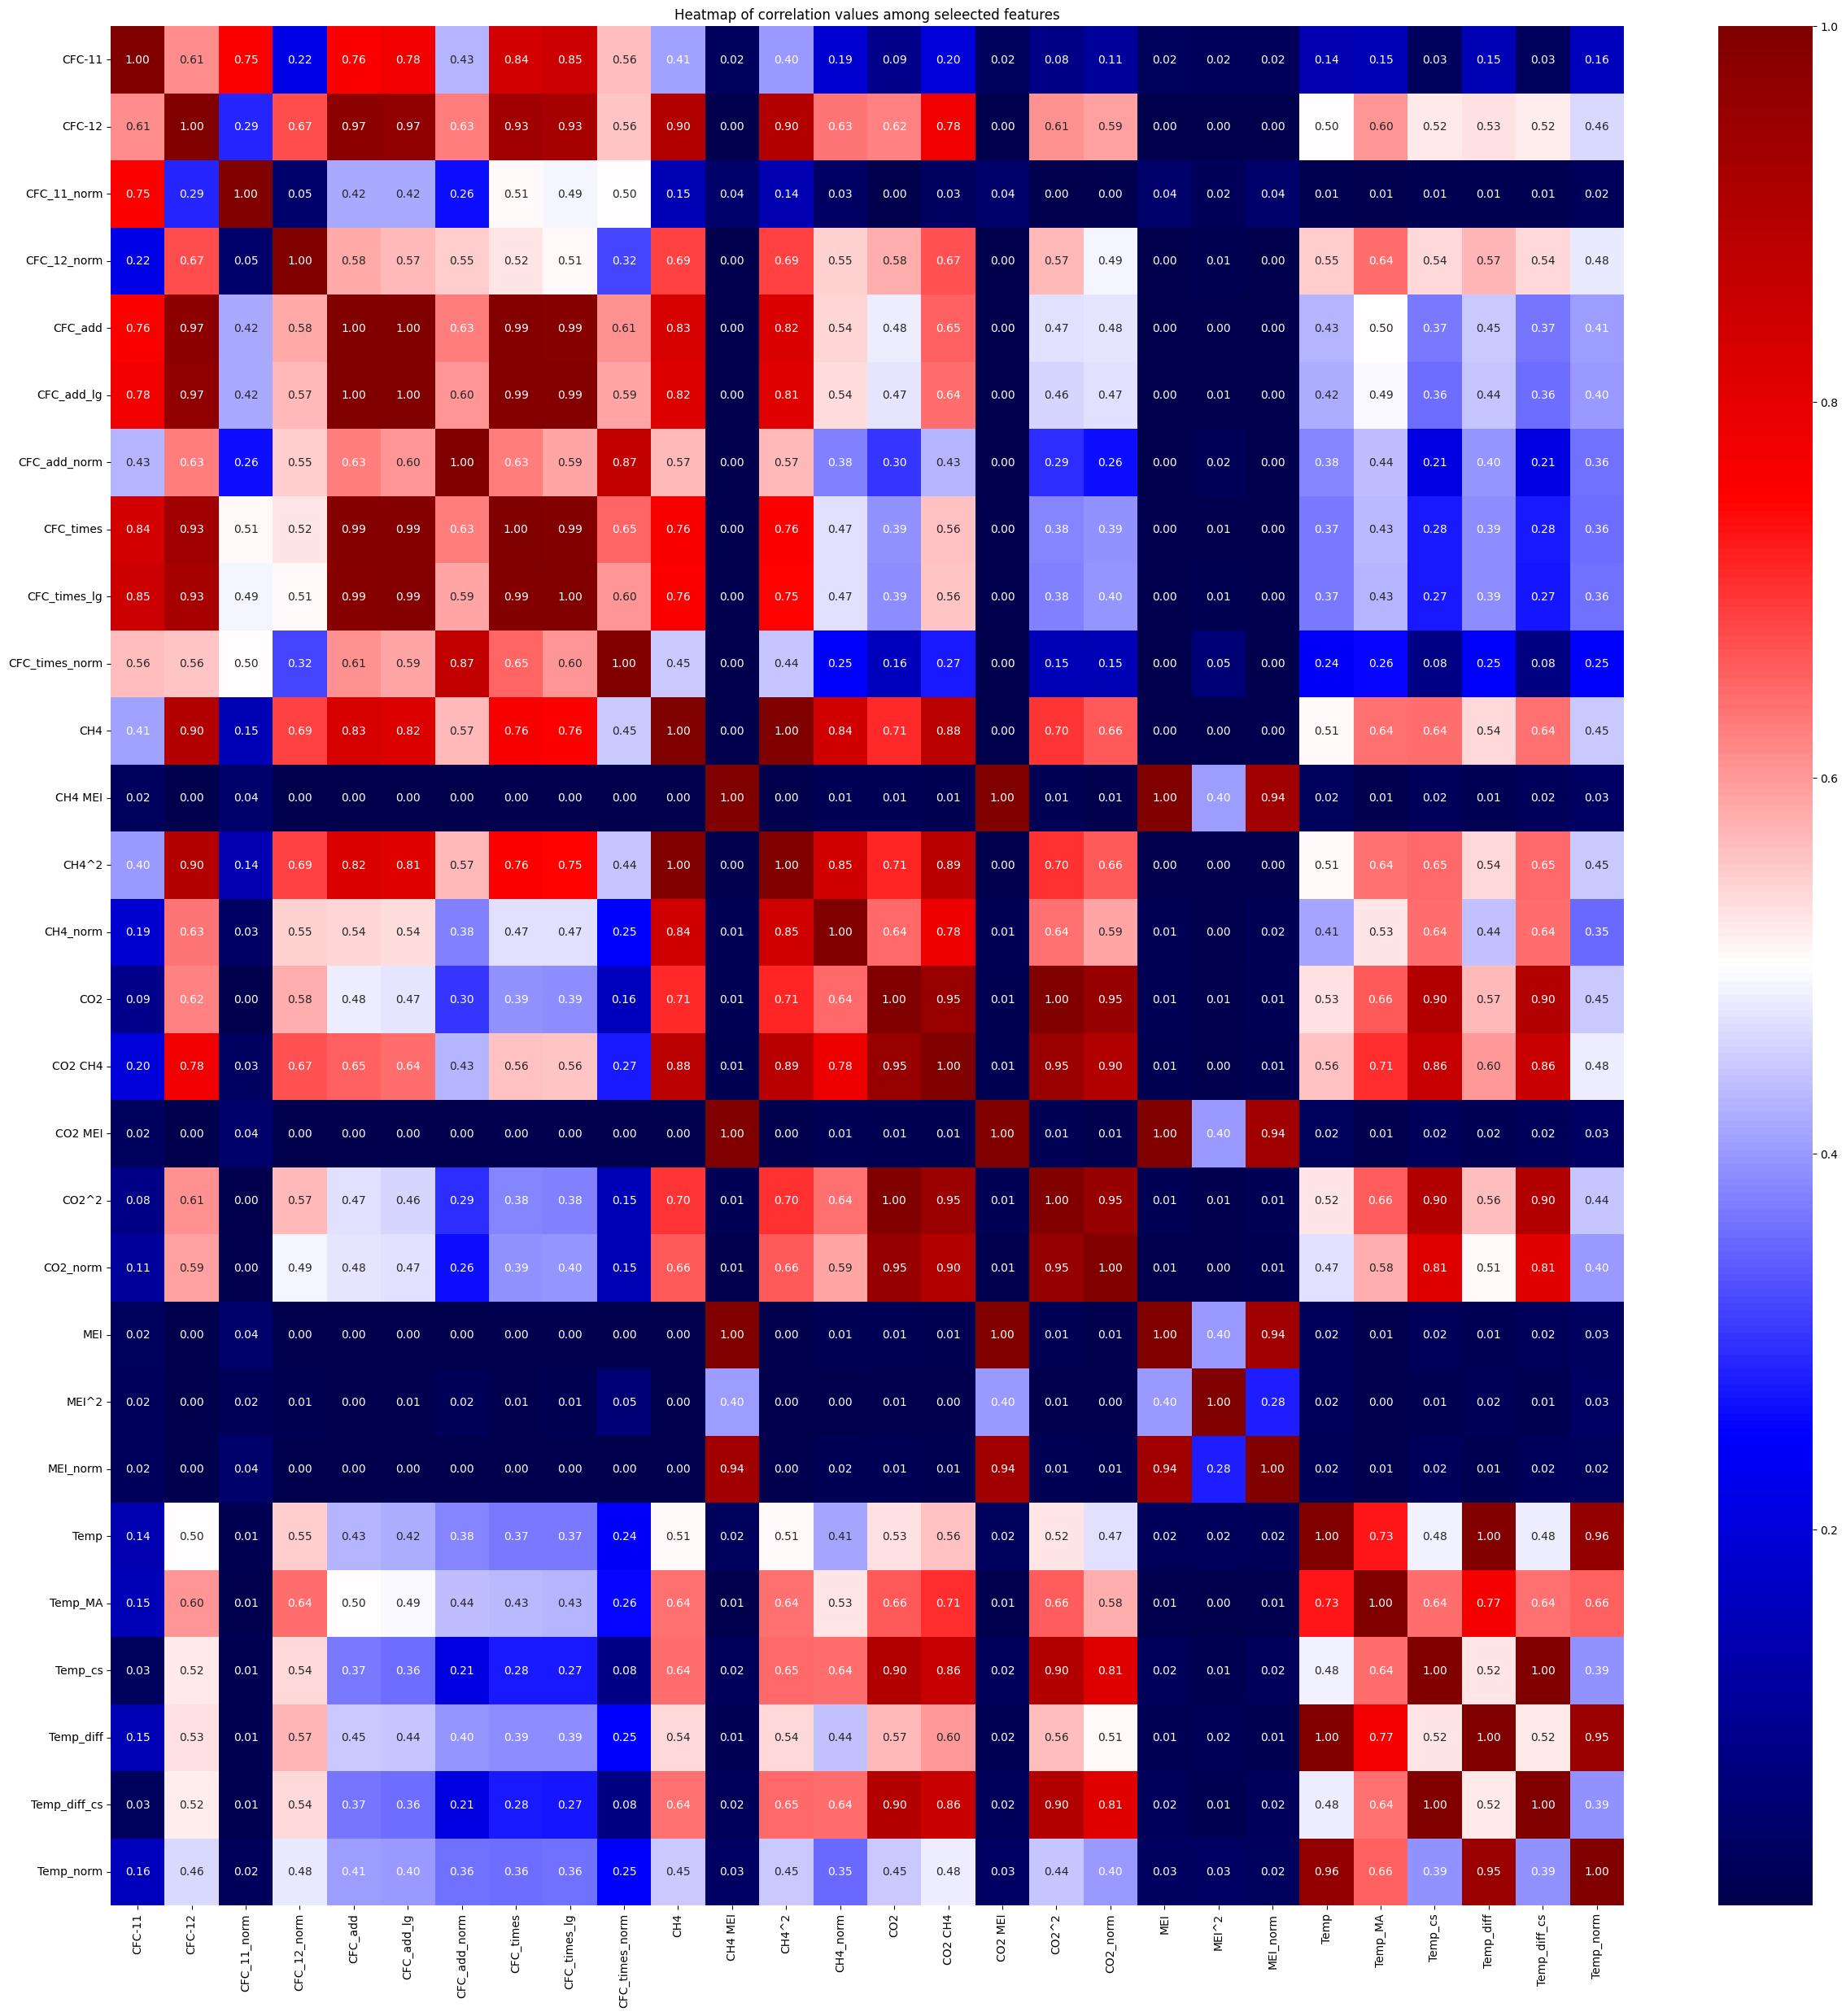

In [71]:
import seaborn as sns
numerical_features.sort()
datatset_correlations = data[numerical_features].corr()
r2 = data[numerical_features].corr()**2
plt.figure(figsize=(30, 30))
sns.heatmap(r2, annot=True, fmt='.2f', cmap='seismic')
plt.title('Heatmap of correlation values among seleected features')
plt.show()

<span style="color:LightSkyBlue">

Before we perform a log transformation of our data, we will prematurely assess whether the dependent variable `Temp` is correlated with our independent variables. We could do it with a correlation table or via correlation heatmap as above.  As prescribed in lab3, we have plot our correlation heatmap using the $r^2$ values instead, where the closer each value is to 0, the more 'blue' a cell will be and the less related each value will be. 

3. Referencing the above heatmap, we will be pruning these highly-uncorrelated features. However, we will lower the threshold than what was prescribed in lab3 as most of the features have $r^2$ values that hover slightly below the 0.5 threshold, thus we will change it to 0.45.

In [72]:
def corr_features(df, target, threshold):
    corr_features = []
    for feature in df.columns:
        if feature==target: continue
        x = df[feature]
        y = df[target]
        r2 = np.corrcoef(x,y)[0][1]
        if abs(r2)>threshold:
            corr_features.append(feature)
    return corr_features

#numerical_features_min = corr_features(data[numerical_features], 'Temp_cs', 0.5)
numerical_features_min = corr_features(data[numerical_features], 'Temp_diff_cs', 0.5)
numerical_features_min.sort()
print(f"updated selected features: {numerical_features_min}")

updated selected features: ['CFC-12', 'CFC_12_norm', 'CFC_add', 'CFC_add_lg', 'CFC_times', 'CFC_times_lg', 'CH4', 'CH4^2', 'CH4_norm', 'CO2', 'CO2 CH4', 'CO2^2', 'CO2_norm', 'Temp', 'Temp_MA', 'Temp_cs', 'Temp_diff', 'Temp_norm']


<span style="color:LightSkyBlue">

We will also remove any features that are too correlated to each other, since it means that we can further reduce the number of dimensions that our data has. This renders the following benefits: 
- Our model performance will likely be higher
- Model training and inference will be faster since less data is involved
- The model has a lower chance of overfitting

However, removing too many features may have the opposite effect of making our model less accurate, thus we will retain at least 3 features, and set our threshold $r^2$ value for removing features to be 0.9.

<span style="color:LightSkyBlue">

First, lets visualise the correlation map of currently selected features:

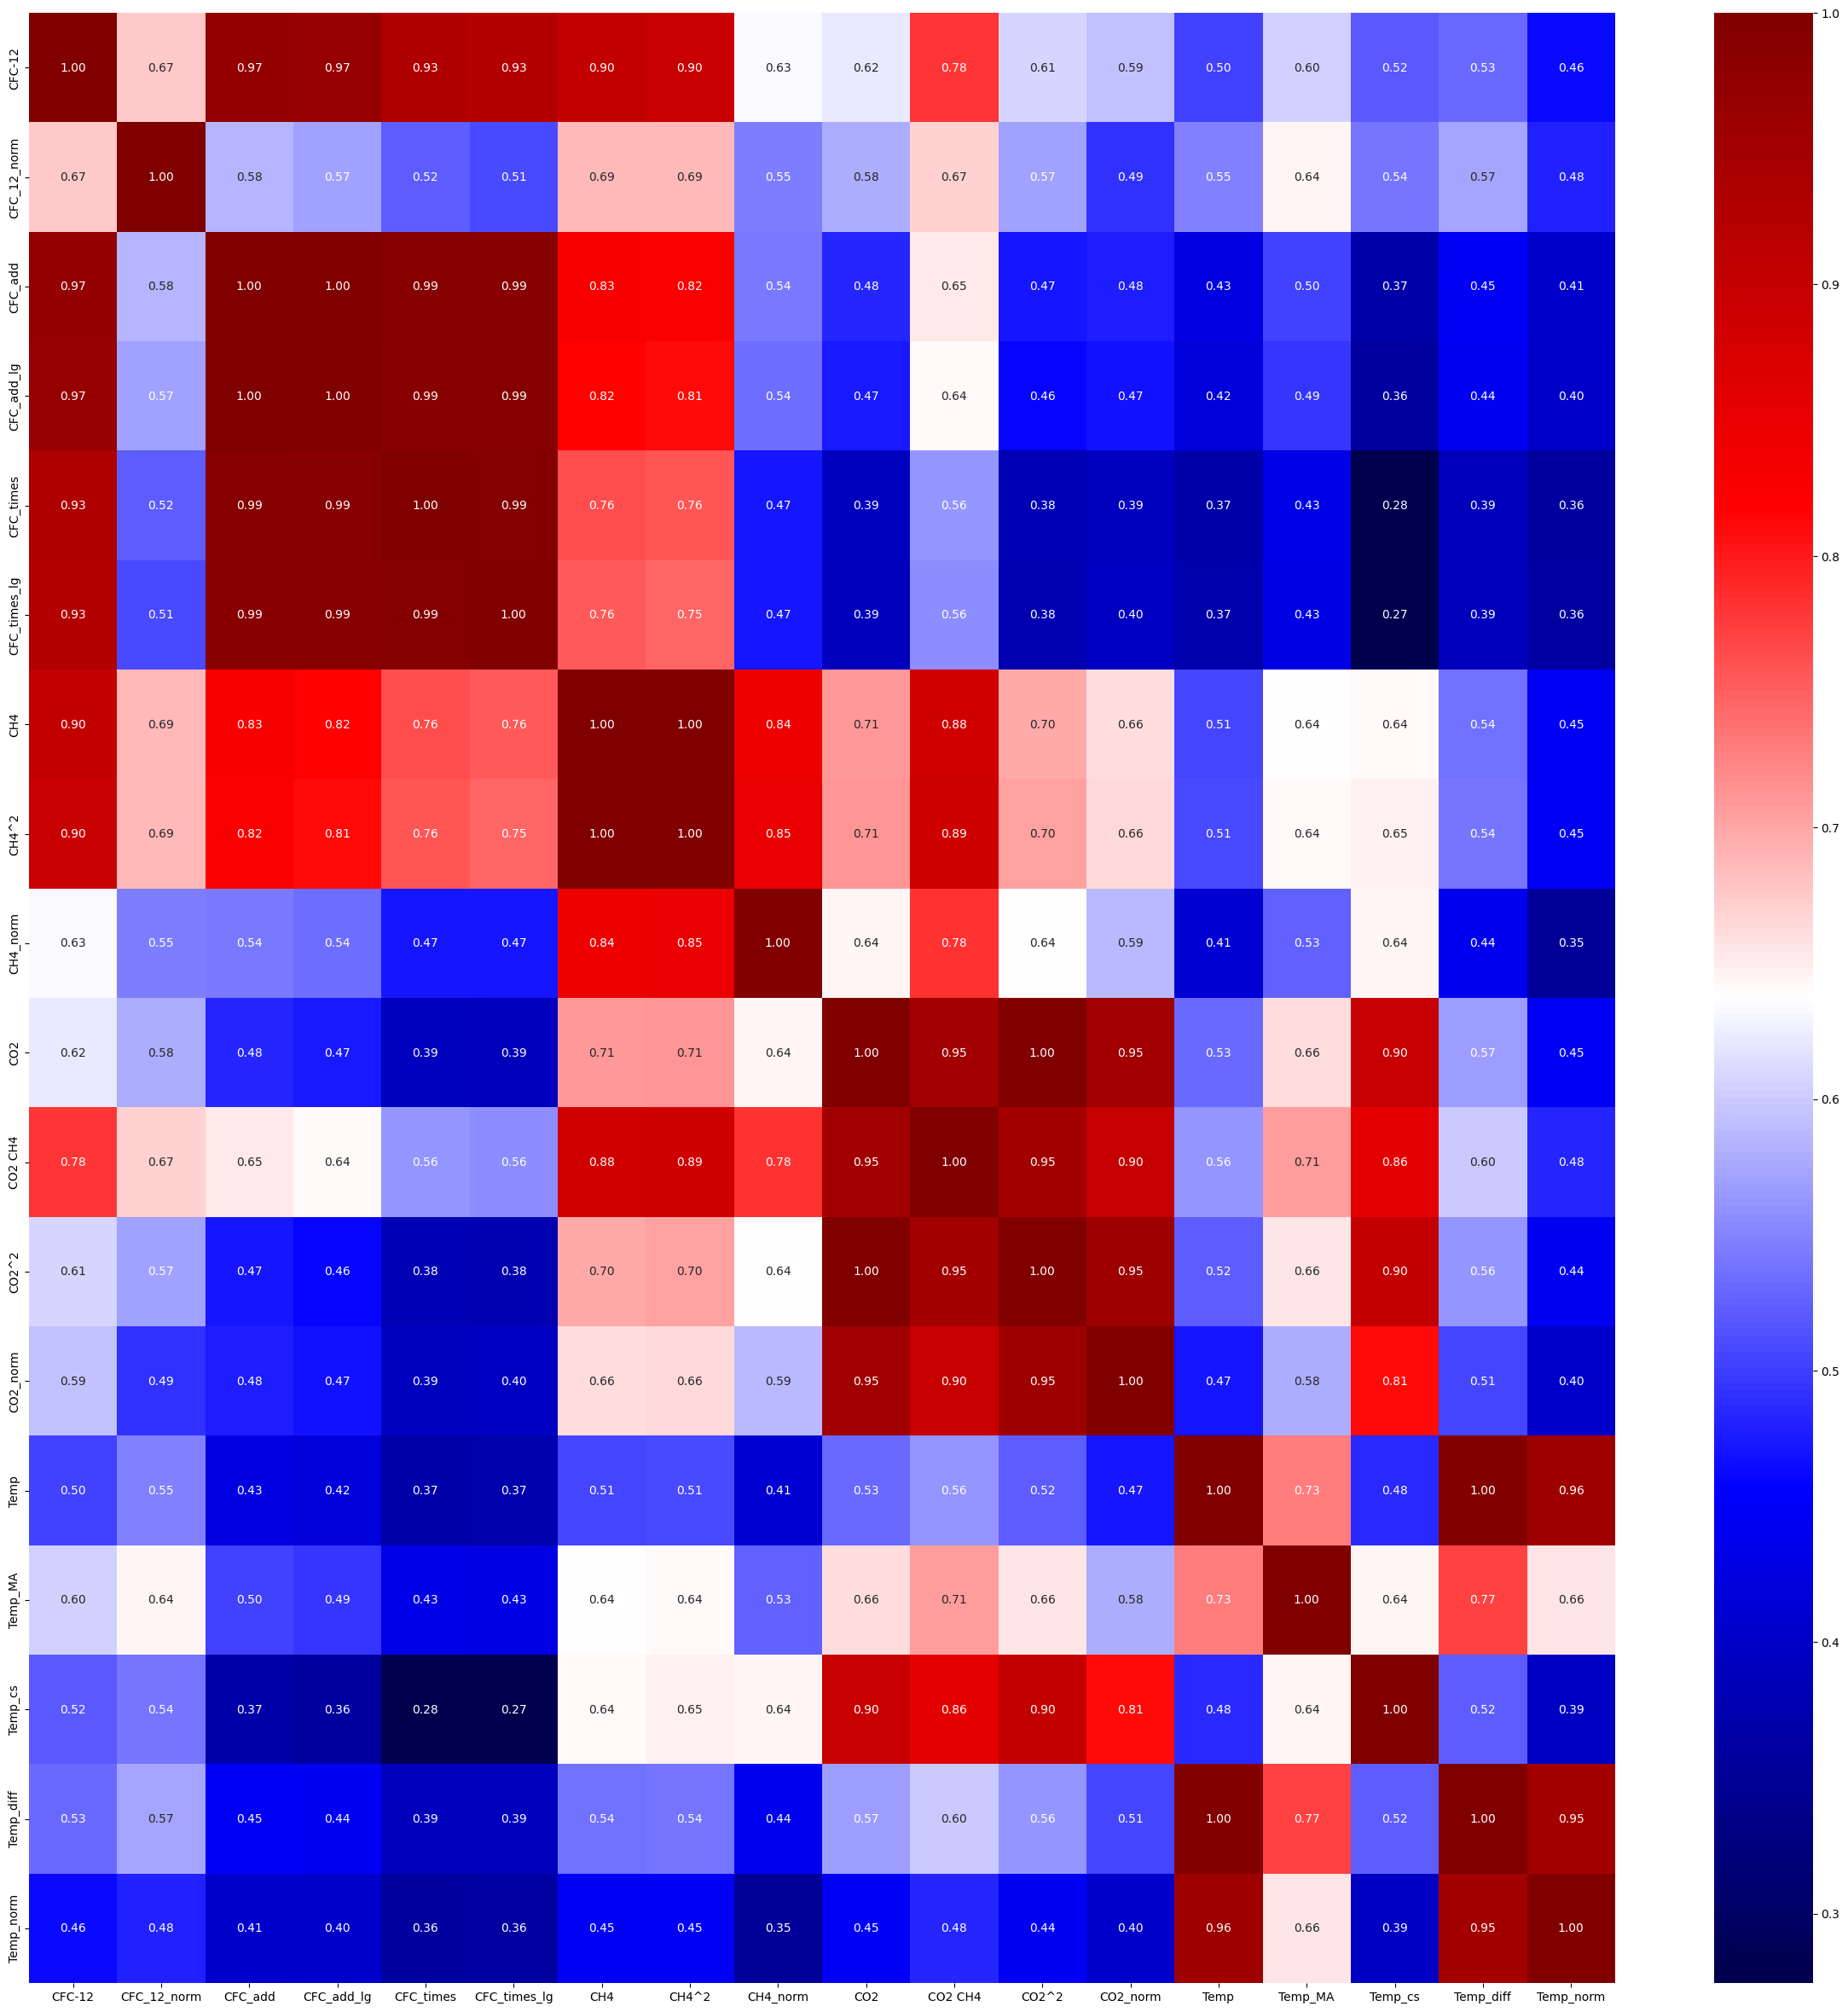

In [73]:
r2_predictors = data[numerical_features_min].corr()**2
plt.figure(figsize=(30, 30))
sns.heatmap(r2_predictors, annot=True, fmt='.2f', cmap='seismic')
plt.show()

<span style="color:LightSkyBlue">

Next, lets remove the highly correlated features. 

In [74]:
# get the feature that has the most number of features
# it is correlated with, beyond certain threshold

def most_corr_feature(df, threshold):
    r2_matrix = abs(df.corr()**2)
    count = r2_matrix[r2_matrix>threshold].count()
    return count.sort_values(ascending=False).index[0]

# return true if all the features are uncorrelated,
# as defined by a threshold

def all_features_uncorr(df, threshold):
    r2_matrix = abs(df.corr()**2)
    n = len(r2_matrix)
    
    # checks for any pair of variables with r^2 value higher than threshold
    return r2_matrix[r2_matrix>threshold].count().sum()==n

# get a set of uncorrelated features
def get_uncorr_features(df, threshold,min_features=0):
    features = df.columns.tolist()
    while all_features_uncorr(df[features], threshold) == False and len(features)> min_features:
        most_corr_fea = most_corr_feature(df[features], threshold)
        features.remove(most_corr_fea)
    return features

In [75]:
numerical_features_selectedV2 =[i for i in numerical_features_min if 'Temp' not in i]

numerical_features_selectedV2 = get_uncorr_features(data[numerical_features_selectedV2], 0.8, min_features=0)
print(f"Selected numerical features : {numerical_features_selectedV2}")

Selected numerical features : ['CFC_12_norm', 'CFC_times_lg', 'CH4', 'CO2']


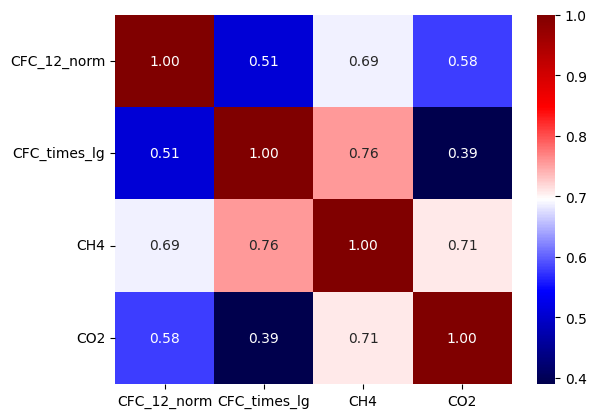

In [76]:
numerical_features_selected = numerical_features_selectedV2.copy()
r2_predictors = data[numerical_features_selected].corr()**2
sns.heatmap(r2_predictors, annot=True, fmt='.2f', cmap='seismic')
plt.show()

<span style="color:LightSkyBlue">

4. Lastly, we will transform the features that do not look like any typical distributions (ie. the normal distribution). We will save variations of these sets of transformed features and see if the transformed data will yield better predictions when we create our model later.

<span style="color:LightSkyBlue">
First, we will visualise the selected features thus far:

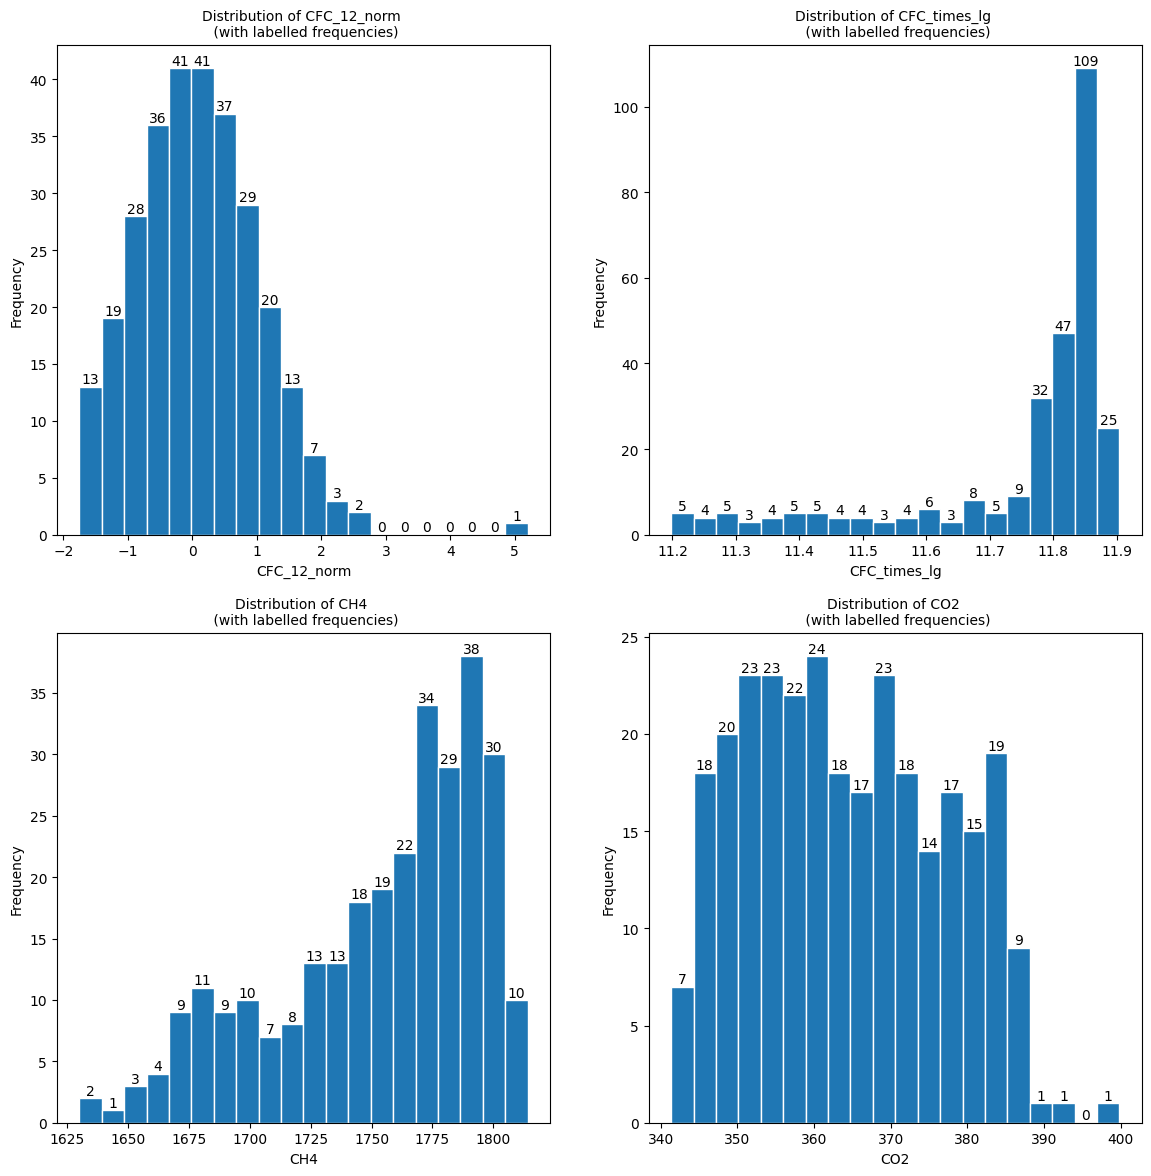

In [77]:
print_histogram(data,numerical_features_selected)

<span style="color:LightSkyBlue">

# TODO: Wei Bin i have no idea how to fit this in, please help

Based on the correlation analysis and heatmap visualization, I have selected the following numerical variables for predicting temperature:

**Primary Features (Strong Correlations):**
1. CO2 (correlation = 0.71)
   - Strongest correlation with temperature among all variables
   - Key greenhouse gas with direct physical relationship to global warming
   - Shows consistent positive trend with temperature

2. CH4 (correlation = 0.69)
   - Strong positive correlation with temperature
   - Known potent greenhouse gas (28 times more potent than CO2)
   - Provides complementary information to CO2

3. CFC-12 (correlation = 0.69)
   - Strong correlation with temperature
   - Class 1 Ozone-depleting substance with high global warming potential
   - Important atmospheric indicator

**Features Excluded:**

1. CFC-11 (correlation = 0.66)
   - Despite moderate correlation with temperature, excluded due to very high multicollinearity with CFC-12 (0.98)
   - Including both CFC-11 and CFC-12 would introduce redundancy in the model
   - CFC-12 preferred due to its higher global warming potential

2. MEI (correlation = 0.14)
   - Very weak correlation with temperature
   - While it measures important climate phenomena (El Niño/La Niña), the low correlation suggests limited direct predictive value for temperature


**Justification:**
- Selection prioritizes variables with correlation coefficients > 0.65 with temperature
- Avoids multicollinearity by not including highly correlated predictor pairs
- Chosen variables have clear physical mechanisms linking them to temperature changes
- Selected features represent different aspects of atmospheric composition affecting global temperature

<span style="color:LightSkyBlue">

# TODO: Wei Bin i have no idea how to fit this in, please help

### Removal of selected features that are correlated to each other

Looking at the correlation heatmap:

CO2 with CH4: correlation = 0.94  
CO2 with CFC-12: correlation = 0.96  
CH4 with CFC-12: correlation = 0.91  

This reveals a significant issue: all three of our selected features are highly correlated with each other (correlation coefficients > 0.90). This indicates strong multicollinearity, which means these variables are indeed redundant with each other.
Given this high multicollinearity, we should revise our feature selection. Here's how we should proceed:
Since CO2 has the highest correlation with temperature (0.71), we should keep it as our primary feature.
We should exclude CH4 and CFC-12 despite their strong correlations with temperature because:
They are highly correlated with CO2 (0.94 and 0.96 respectively)
Including them would introduce redundancy in our model

Their relationships with temperature might be captured indirectly through CO2

----

<span style="color:LightSkyBlue">

Lastly, we will combine the features that we have selected from the pool of categorical and numerical variables.

In [78]:
features_selected = cat_features_selected + numerical_features_selected
print(", ".join(features_selected))

Aerosols_ord, TSI_ord, Season_autumn, Season_spring, Season_summer, Season_winter, Month_sin, Month_cos, CFC_12_norm, CFC_times_lg, CH4, CO2


**b.** Split the dataset into train and test sets. Describe how you split step by step.

**Response.** 

<span style="color:LightSkyBlue">

We will use the prescribed method from lab3, and split the data using the function under the sci-kit learn library `train_test_split` for splitting our data. We will also be performing an 80-20 test-train split as prescribed for many model training techniques.

In [79]:
from sklearn.model_selection import train_test_split

#response_var = "Temp_cs"
#features_selected = ['Aerosols_ord', 'TSI_ord', 'Month_sin', 'Month_cos', 'CFC_12_change', 'CFC_12_diff_st', 'CFC_12_norm', 'CFC_add_norm', 'CFC_times_lg', 'CH4', 'CO2']

response_var = "Temp_diff_cs"
X = data[features_selected]
y = data[[response_var]]

X_train, X_test, y_train_set, y_test_set = train_test_split(
    X, y, test_size=0.8, random_state=42
)
y_train = y_train_set[response_var]
y_test = y_test_set[response_var]

**c.** State the model(s) you will train, and explain your choice(s), in **no more than 50 words per model**. You only need to
train one model, but if you do train more models, limit yourself to no more than three---Grading is based on the validity and soundness of your model, rather than the quantity.

**Response.** 

<span style="color:LightSkyBlue">

**Models Selected:**

1. Ridge regression with Leave-One-Out Cross validation (`RidgeCV`)
    - We have limited data and features in this dataset, hence our data highly likely of having both high bias and variance. Thus, we will use regularization and cross-validation techniques to prevent our model from overfitting. 
    
    - This model introduces an L2 penalty term that minimises the squared-value of coefficients.


2. Lasso regression with Leave-One-Out Cross validation (`LassoCV`)
    - We have limited data and features in this dataset, hence our data highly likely of having both high bias and variance. Thus, we will use regularization and cross-validation techniques to prevent our model from overfitting. 
    
    - This model introduces an L1 penalty term that minimises the magnitude of coefficients.


3. Elastic Net regression with Leave-One-Out Cross validation (`ElasticNetCV`)
    - We have limited data and features in this dataset, hence our data highly likely of having both high bias and variance. Thus, we will use regularization and cross-validation techniques to prevent our model from overfitting. 
    
    - This model introduces a penalty equal to a combination of the L1 and L2 penalties.



**d.** For each model, perform the training, and report the trained parameters and the training scores, if applicable. 

**Response.** 

In [80]:
## model fitting for linear regression
from sklearn.linear_model import RidgeCV

model1 = RidgeCV().fit(X_train, y_train)
model1_r2 = model1.score(X_train, y_train)
coef1 = model1.coef_
bias1 = model1.intercept_

print(f"Model 1: {model1.__class__.__name__}")
print("--------------------------")
print(f"Features used : {X_train.columns.tolist()}")
print(f"Coefficients: {coef1}")
print(f"Intercept : {bias1}")
print('='*40)
print(f"Coeff of Determination : {model1_r2}")
print('='*40)

feature_coef_pairs = zip(X_train.columns.tolist(), coef1)
feature_coef_pairs = sorted(feature_coef_pairs, key=lambda x: abs(x[1]), reverse=True)
print()
print(f"Features by coefficient strength:")
for i in feature_coef_pairs:
    print(f"{i[0]} : {i[1]}")

Model 1: RidgeCV
--------------------------
Features used : ['Aerosols_ord', 'TSI_ord', 'Season_autumn', 'Season_spring', 'Season_summer', 'Season_winter', 'Month_sin', 'Month_cos', 'CFC_12_norm', 'CFC_times_lg', 'CH4', 'CO2']
Coefficients: [  0.26472006   1.5207628    1.54130035  -3.20860326  -1.43120311
   3.09850602  -4.01699201  -3.186924     3.75438903 -50.70188469
   0.23284603   1.33168222]
Intercept : -272.2245292942888
Coeff of Determination : 0.9318178068444904

Features by coefficient strength:
CFC_times_lg : -50.70188468739546
Month_sin : -4.016992010943895
CFC_12_norm : 3.7543890330730925
Season_spring : -3.2086032564806004
Month_cos : -3.1869239965870833
Season_winter : 3.0985060187889433
Season_autumn : 1.5413003494383588
TSI_ord : 1.520762797810555
Season_summer : -1.4312031117466866
CO2 : 1.331682221363053
Aerosols_ord : 0.2647200558776248
CH4 : 0.23284603418323968


In [81]:
## model fitting for ridge
from sklearn.linear_model import LassoCV

model2 = LassoCV().fit(X_train, y_train)
model2_r2 = model2.score(X_train, y_train)
coef2 = model2.coef_
bias2 = model2.intercept_

print(f"Model 2: {model2.__class__.__name__}")
print("-------------------------")
print(f"Features : {X_train.columns.tolist()}")
print(f"Coefficients: {coef2}")
print(f"Intercept : {bias2}")
print('='*40)
print(f"Coeff of Determination : {model2_r2}")
print('='*40)

feature_coef_pairs = zip(X_train.columns.tolist(), coef2)
feature_coef_pairs = sorted(feature_coef_pairs, key=lambda x: abs(x[1]), reverse=True)
print()
print(f"Features by significance:")
for i in feature_coef_pairs:
    if i[1] != 0:
        print(f"{i[0]} : {i[1]}")

Model 2: LassoCV
-------------------------
Features : ['Aerosols_ord', 'TSI_ord', 'Season_autumn', 'Season_spring', 'Season_summer', 'Season_winter', 'Month_sin', 'Month_cos', 'CFC_12_norm', 'CFC_times_lg', 'CH4', 'CO2']
Coefficients: [-0.          0.          0.         -0.         -0.          0.
 -2.79840323  0.          0.         -0.          0.03753617  1.5984363 ]
Intercept : -621.6230615378494
Coeff of Determination : 0.8884585971963741

Features by significance:
Month_sin : -2.7984032284663205
CO2 : 1.5984362986816998
CH4 : 0.03753616791534477


In [82]:
## model fitting for ridge
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNetCV

model3 = ElasticNetCV().fit(X_train, y_train)
model3_r2 = model3.score(X_train, y_train)
coef3 = model3.coef_
bias3 = model3.intercept_

print(f"Model 2: {model3.__class__.__name__}")
print("-------------------------")
print(f"Features : {X_train.columns.tolist()}")
print(f"Coefficients: {coef3}")
print(f"Intercept : {bias3}")
print('='*40)
print(f"Coeff of Determination : {model3_r2}")
print('='*40)

feature_coef_pairs = zip(X_train.columns.tolist(), coef3)
feature_coef_pairs = sorted(feature_coef_pairs, key=lambda x: abs(x[1]), reverse=True)
print()
print(f"Features by significance (not shown if coef is 0):")
for i in feature_coef_pairs:
    if i[1] != 0:
        print(f"{i[0]} : {i[1]}")

Model 2: ElasticNetCV
-------------------------
Features : ['Aerosols_ord', 'TSI_ord', 'Season_autumn', 'Season_spring', 'Season_summer', 'Season_winter', 'Month_sin', 'Month_cos', 'CFC_12_norm', 'CFC_times_lg', 'CH4', 'CO2']
Coefficients: [-0.          0.          0.         -0.14814682  0.          0.
 -1.07667714  0.          0.         -0.          0.05089239  1.55411332]
Intercept : -628.9151102261019
Coeff of Determination : 0.8806856744457866

Features by significance (not shown if coef is 0):
CO2 : 1.5541133184099787
Month_sin : -1.0766771352923639
Season_spring : -0.14814681680990277
CH4 : 0.050892386779153885


### 3. Model evaluation and selection [30% of Part II]

**a.** For each model, predict the response variable on the test set.

**Response.** 

In [83]:
model1_r2_val = model1.score(X_test, y_test)
print(f"Model 1: Ridge Regression")
print("--------------------------")
print(f"Coeff of Determination (on validation set): {model1_r2_val}")
print("--------------------------")
print('First 5 prediction results:')
results1 = model1.predict(X_test)[:5]
for i in results1:
    print(i)

Model 1: Ridge Regression
--------------------------
Coeff of Determination (on validation set): 0.938060515971783
--------------------------
First 5 prediction results:
13.94058163536306
59.511720667953
1.6897920337120809
34.58217969784732
17.808384502902413


In [84]:
model2_r2_val = model2.score(X_test, y_test)
print(f"Model 2: Lasso Regression")
print("--------------------------")
print(f"Coeff of Determination (on validation set): {model2_r2_val}")
print("--------------------------")
print('First 5 prediction results:')
results2 = model2.predict(X_test)[:5]
for i in results2:
    print(i)

Model 2: Lasso Regression
--------------------------
Coeff of Determination (on validation set): 0.9181724941336499
--------------------------
First 5 prediction results:
16.089158469408858
58.52961765551663
1.9473058308727786
36.03418253320331
23.95746239835364


In [85]:
model3_r2_val = model3.score(X_test, y_test)
print(f"Model 3: Elastic Net Regression")
print("--------------------------")
print(f"Coeff of Determination (on validation set): {model3_r2_val}")
print("--------------------------")
print('First 5 prediction results:')

results3 = model3.predict(X_test)[:5]
for i in results3:
    print(i)

Model 3: Elastic Net Regression
--------------------------
Coeff of Determination (on validation set): 0.9075805003847629
--------------------------
First 5 prediction results:
16.16460424450372
59.585188340866466
3.280142382443387
37.5275183091743
22.468326720597247


**b.** Describe the metric you use to evaluate your model(s). Report the test scores for each model.

**Response.** 

<span style="color:LightSkyBlue">

we will be using the following error metrics to evaluate our model:
##### Mean absolute error (MAE) 

$$\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }$$
MAE measures the average absolute difference between predicted and actual values, making it easy to interpret and less sensitive to outliers.
##### Root mean squared error (RMSE) 

$$\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }$$

RMSE measures average error but penalizes larger errors more, making it suitable when large deviations are especially undesirable
##### Mean absolute percentage error (MAPE)

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100\%$$
MAPE expresses errors as percentages, providing intuitive, relative error information that is easy for non-technical audiences to understand and compare across datasets.

In [86]:
## model 1 evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# predict based on test set
y_pred = model1.predict(X_test)

# compare with ground truth
mae1 = mean_absolute_error(y_test, y_pred)
ave1 = np.mean(y_test)
rmse1 = root_mean_squared_error(y_test, y_pred)  # setting squared = False returns the square-root 
mape1 = mean_absolute_percentage_error(y_test, y_pred)  # setting squared = False returns the square-root 

print("Model 1 Evaluation")
print("-----------------")
print("Error on Training set")
print(f"MAE: {mae1:.2f}")
print(f"MAE as % of mean: {mae1/ave1*100:.1f}%")
print(f"RMSE: {rmse1:.2f}")
print(f"RMSE as % of mean: {rmse1/ave1*100:.1f}%")
print(f"MAPE: {mape1*100}%")

Model 1 Evaluation
-----------------
Error on Training set
MAE: 4.30
MAE as % of mean: 15.7%
RMSE: 5.93
RMSE as % of mean: 21.6%
MAPE: 145.14377076814483%


In [87]:
# predict based on test set
y_pred = model2.predict(X_test)

# compare with ground truth
mae2 = mean_absolute_error(y_test, y_pred)
ave2 = np.mean(y_test)
rmse2 = root_mean_squared_error(y_test, y_pred)  # setting squared = False returns the square-root 
mape2 = mean_absolute_percentage_error(y_test, y_pred)  # setting squared = False returns the square-root 

print("Model 2 Evaluation")
print("-----------------")
print(f"MAE: {mae2:.2f}")
print(f"MAE as % of mean: {mae2/ave2*100:.1f}%")
print(f"RMSE: {rmse2:.2f}")
print(f"RMSE as % of mean: {rmse2/ave2*100:.1f}%")
print(f"MAPE: {mape2*100}%")

Model 2 Evaluation
-----------------
MAE: 5.11
MAE as % of mean: 18.6%
RMSE: 6.81
RMSE as % of mean: 24.8%
MAPE: 610.7718467969776%


In [88]:
## model 3 evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

# predict based on test set
y_pred = model3.predict(X_test)

# compare with ground truth
mae3 = mean_absolute_error(y_test, y_pred)
ave3 = np.mean(y_test)
rmse3 = root_mean_squared_error(y_test, y_pred)  # setting squared = False returns the square-root 
mape3 = mean_absolute_percentage_error(y_test, y_pred)  # setting squared = False returns the square-root 


print("Model 3 Evaluation")
print("-----------------")
print(f"MAE: {mae3:.2f}")
print(f"MAE as % of mean: {mae3/ave3*100:.1f}%")
print(f"RMSE: {rmse3:.2f}")
print(f"RMSE as % of mean: {rmse3/ave3*100:.1f}%")
print(f"MAPE: {mape3*100}%")

Model 3 Evaluation
-----------------
MAE: 5.48
MAE as % of mean: 20.0%
RMSE: 7.24
RMSE as % of mean: 26.4%
MAPE: 672.450648910693%


**c.** If you trained more than one model, identify the final model you would choose for the prediction task, and explain your choice, **in no more than 50 words**.

**Response.** 

<span style="color:LightSkyBlue">

We picked the Lasso Model (`model2`). because:
- It incorporates fewer features unlike `RidgeCV`, hence it is unlikely to be overfitted
- It has a better metric-based performance unlike ElasticNetCV (over different random seeds)
- The features used are explainable by rank and relevance, and justifies why some features are not required.

### 4. Findings and conclusion [20% of Part II]

**a.** Interpret what your model is implying, and summarize any insight you have drawn from the project. Explain if it is consistent with intuition, and if not, provide a plausible justification. Limit your entire response to **50 words**.

**Response.** 

<span style="color:LightSkyBlue">

Our metrics, aside from MAPE, suggests a strong correlation between cummulative temperature changes and the features selected. This is consistent with reality since temperature changes are largely dependent on atmospheric chemical interactions. MEI only has short-term effects, while CFCs affect TSI and the categories provided need to be more refined.

Validation:
[CO2 relevance](https://www.e3s-conferences.org/articles/e3sconf/pdf/2023/12/e3sconf_esat2023_03014.pdf) | [CH4 Relevance](https://thundersaidenergy.com/2022/10/19/how-does-methane-increase-global-temperature/)



**b.** Share any lesson you have learned from the project, in **no more than 50 words**.

**Response.** 

<span style="color:LightSkyBlue">

- We learned various techniques to guide and reaffirm our conceptions with real-world data, and to be wary of hidden temporal features.
- Despite the model's accuracy, we should acknowledge that the dataset's size is a limitation that introduces variance and bias, hence steps should be taken to mitigate this.

### 5. Non-technical protocol [5% of Part II]

**a.** Describe the detailed contribution of each team member, including both the tangible (e.g., implementation, testing, writing) and intangible (e.g., generating ideas, planning, leadership) efforts.

**Response.** 

<span style="color:LightSkyBlue">


| Member | Contribution |
|---|---|
|BRENDAN TAN YONG JIE  | Led the group and verified the methodology. |
|DYLAN MATTHEW TAN JUN  | Planned meeting schedules for the group, gave ideas and distributed workload. |
|SAMYUKTHA PUGALANTHI  | Did research for possible trend explanations. |
| LEE JIA HENG | Implemented the code, did research for better feature engineering |
| LAU WEI BIN | Handled code testing, did research for explaining trends.|


**b.** List any references and sources you have cited.

**Response.** 

<span style="color:LightSkyBlue">

**Part 1**  
References for EDA research:
- https://www.google.com/url?q=https%3A%2F%2Fpsl.noaa.gov%2Fenso%2Fmei%2F%23datacomp
- https://www.epa.gov/gmi/importance-methane#:~:text=Methane%20is%20more%20than%2028,trapping%20heat%20in%20the%20atmosphere.
- https://insideclimatenews.org/news/11092019/nitrous-oxide-climate-pollutant-explainer-greenhouse-gas-agriculture-livestock/#:~:text=Like%20other%20greenhouse%20gases%2C%20nitrous,middle%20ground%20of%20super%20pollutants.
- https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Supplemental_Modules_(Physical_and_Theoretical_Chemistry)/Kinetics/07%3A_Case_Studies-_Kinetics/7.03%3A_Depletion_of_the_Ozone_Layer#:~:text=The%20Chapman%20Cycle,-The%20stratosphere%20is&text=The%20ozone%20layer%20is%20created,O2%E2%86%922O.
- https://www.epa.gov/ozone-layer-protection/ozone-depleting-substances#:~:text=(ODP)%2C%20Global%20Warming%20Potential,has%20a%20GWP%20of%205%2C000.
- https://gml.noaa.gov/grad/surfrad/aod/#:~:text=Aerosol%20optical%20depth%20is%20a,ground%20by%20these%20aerosol%20particles.
- https://rmets.onlinelibrary.wiley.com/doi/10.1002/joc.2336
- https://news.agu.org/press-release/ocean-uptake-of-co2-could-drop-as-we-cut-carbon-emissions/
- https://www.climate.gov/news-features/understanding-climate/after-2000-era-plateau-global-methane-levels-hitting-new-highs
- https://www.washington.edu/news/2024/03/12/ai-analysis-of-historical-satellite-images-show-ussr-collapse-in-1990s-increased-methane-emissions-despite-lower-oil-and-gas-production/
- https://ozone.unep.org/system/files/documents/SAP-2021-report-on-the-unexpected-emissions-of-CFC-11-1268_en.pdf
- https://news.mit.edu/2021/cfc-11-ozone-recovery-0210
- https://www.nature.com/articles/s41586-021-03260-5
- https://ozone.unep.org/story-behind-unexpected-emissions-cfc-11
- https://www.green-cooling-initiative.org/fileadmin/Publications/2020_ODS_CFC11_CFC12-banks.pdf
- https://www.sciencedirect.com/topics/engineering/atmospheric-lifetime#:~:text=Lifetime%20of%20Greenhouse%20Chemicals&text=Nitrous%20oxide%20has%20an%20atmospheric,atmospheric%20lifetime%20of%2050%2C000%20years.
- 

**Part 2**

References for problem formulation
- Khan, A. , Chatterjee, S. , Bisai, D. and Barman, N. (2014) Analysis of Change Point in Surface Temperature Time Series Using Cumulative Sum Chart and Bootstrapping for Asansol Weather Observation Station, West Bengal, India. American Journal of Climate Change, 3, 83-94. doi: 10.4236/ajcc.2014.31008.  
- Benoit, Mesnil & Petitgas, Pierre. (2009). Detection of changes in time-series of indicators using CUSUM control charts. Aquatic living resources (0990-7440) (EDP Sciences), 2009-04 , Vol. 22 , N. 2 , P. 187-192. 22. 10.1051/alr/2008058. 
  
References for pre-feature engineering relevance research:
- https://www.google.com/url?q=https%3A%2F%2Fwww.giss.nasa.gov%2Fedu%2Ficp%2Fresearch%2Fppa%2F1997%2Freyes%2F
- https://www.google.com/url?q=https%3A%2F%2Fwww.energy.gov%2Feere%2Fsolar%2Fsolar-radiation-basics
- https://www.hko.gov.hk/en/education/weather/meteorology-basics/00004-what-is-radiation-cooling.html#:~:text=Moisture%20in%20the%20air%20keeps,off%20faster%20than%20moist%20air.&text=cooling%20at%20night-,In%20winter%2C%20a%20large%20temperature%20difference%20sometimes%20exists%20between%20the,areas%20and%20the%20New%20Territories.  
- https://www.sciencedirect.com/science/article/abs/pii/S1364032115010552
- https://web.gps.caltech.edu/~yly/yly_mac/ReprintsYLY/N420%20li%20jing%202022%20Aerosol_review_NREE_published.pdf
- Kulmala, M., Kokkonen, T., Ezhova, E., Baklanov, A., Mahura, A., Mammarella, I., Bäck, J., Lappalainen, H. K., Tyuryakov, S., Kerminen, V., Zilitinkevich, S., & Petäjä, T. (n.d.). Aerosols, Clusters, Greenhouse Gases, Trace Gases and Boundary-Layer Dynamics: on Feedbacks and Interactions. Boundary-Layer Meteorology, 186(3), 475–503. https://doi.org/10.1007/s10546-022-00769-8
- Curtius, J., Lovejoy, E.R. & Froyd, K.D. Atmospheric Ion-induced Aerosol Nucleation. Space Sci Rev 125, 159–167 (2006). https://doi.org/10.1007/s11214-006-9054-5
- Kaufman et al. (2005), Aerosol anthropogenic component estimated from satellite data, Geophysical Research Letters
- Storelvmo, T., Heede, U. K., Leirvik, T., Phillips, P. C. B., Arndt, P., & Wild, M. (2018b). Lethargic response to aerosol emissions in current climate models. Geophysical Research Letters, 45(18), 9814–9823. https://doi.org/10.1029/2018gl078298
- Pithan, F., & Schatt, L. (2024). Diurnal temperature range trends differ below and above the melting point. Geophysical Research Letters, 51(17). https://doi.org/10.1029/2024gl109751
  
References for model building and feature engineering:
- https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/
- https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html
- https://scikit-learn.org/1.4/auto_examples/applications/plot_time_series_lagged_features.html
- https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features
- https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#quantiletransformer-gaussian-output 
- https://scikit-learn.org/stable/auto_examples/preprocessing/plot_map_data_to_normal.html#sphx-glr-auto-examples-preprocessing-plot-map-data-to-normal-py
  
References for error metrics and model evaluation:
- https://scikit-learn.org/stable/modules/model_evaluation.html#r2-score-the-coefficient-of-determination
- https://scikit-learn.org/stable/modules/model_evaluation.html#mean-absolute-error\
- https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error
- https://scikit-learn.org/stable/modules/model_evaluation.html#mean-absolute-percentage-error  
- https://medium.com/@jonatasv/metrics-evaluation-mse-rmse-mae-and-mape-317cab85a26b  
  
References for model validity:
- https://www.e3s-conferences.org/articles/e3sconf/pdf/2023/12/e3sconf_esat2023_03014.pdf
- https://thundersaidenergy.com/2022/10/19/how-does-methane-increase-global-temperature/